In [1]:
import os
import ee
import geemap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import geopandas as gpd

import plotly.express as px
import plotly.graph_objects as go

In [3]:
m = geemap.Map(center=[40,-100], zoom=4)
m

Enter verification code:  


EEException: Cannot authenticate: Invalid request.

In [3]:
ntu = pd.read_csv(r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/wq_data.csv")
print(ntu.shape)
ntu.head()

(165, 32)


,Date,Time,Solar_site,Site,Creek,Solar,Grab Sample Label,Camera?,Turbidity NTU_sample_dup1,Turbidity NTU_sample_dup2,...,Velocity m/s.1,interval_3,Distance m.2,Velocity m/s.2,interval_sec,AvgVeloc,logger,comment,rotor constant,Unnamed: 31
0,1/23/2024,9:50 AM,Mart,Big @ 162,Big,1,8730,NaN,2766.0,2658.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26873.0,999999.0
1,1/22/2024,NaN,Mart,Big @ 168,Big,0,8707,NaN,1080.0,962.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26873.0,999999.0
2,1/23/2024,10:30 AM,Mart,Brushy @ 152,Brushy,1,8716,NaN,160.0,1533.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26873.0,999999.0
3,4/9/2024,2:31 PM,Robinson,Downstream Robinson,Flat,1,8706,NaN,700.0,705.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26873.0,999999.0
4,4/9/2024,3:32 PM,Mart,Brushy @ 118,Brushy,0,8733,NaN,613.0,601.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26873.0,999999.0


In [4]:
ntu_mart = ntu.loc[ntu['Solar_site'] == 'Mart', ['Date', 'Site', 'Creek', 'Solar', 'Avg Turbidity NTU']]
print(ntu_mart.shape)
ntu_mart.head()

(138, 5)


,Date,Site,Creek,Solar,Avg Turbidity NTU
0,1/23/2024,Big @ 162,Big,1,2712.000000
1,1/22/2024,Big @ 168,Big,0,1021.000000
2,1/23/2024,Brushy @ 152,Brushy,1,846.500000
4,4/9/2024,Brushy @ 118,Brushy,0,605.333333
5,4/10/2024,Big @ 162,Big,1,601.666667


In [5]:
# ensure Date is datetime
ntu_mart["Date"] = pd.to_datetime(ntu_mart["Date"])

# keep only data from Jan 24, 2024 onward
ntu_mart = ntu_mart[ntu_mart["Date"] >= "2024-01-23"]
print(ntu_mart.shape)
ntu_mart.head()

(136, 5)


,Date,Site,Creek,Solar,Avg Turbidity NTU
0,2024-01-23,Big @ 162,Big,1,2712.000000
2,2024-01-23,Brushy @ 152,Brushy,1,846.500000
4,2024-04-09,Brushy @ 118,Brushy,0,605.333333
5,2024-04-10,Big @ 162,Big,1,601.666667
6,2024-04-10,Hogpen @ 162,Hogpen,1,590.333333


In [6]:
ntu_mart["Date"] = pd.to_datetime(ntu_mart["Date"])
ntu_mart = ntu_mart.drop(ntu_mart[(ntu_mart["Creek"].eq("Big")) & (ntu_mart["Date"] < "2024-01-24")].index)
print(ntu_mart.shape)
ntu_mart.head()

(134, 5)


,Date,Site,Creek,Solar,Avg Turbidity NTU
2,2024-01-23,Brushy @ 152,Brushy,1,846.500000
4,2024-04-09,Brushy @ 118,Brushy,0,605.333333
5,2024-04-10,Big @ 162,Big,1,601.666667
6,2024-04-10,Hogpen @ 162,Hogpen,1,590.333333
7,2024-04-29,Brushy @ 152,Brushy,1,515.000000


In [7]:
ntu_mart.value_counts('Solar')

Solar
1    73
0    61
Name: count, dtype: int64

In [8]:
ntu_mart.loc[ntu_mart["Site"] == "Little Brushy @ 150"]

,Date,Site,Creek,Solar,Avg Turbidity NTU
57,2024-04-10,Little Brushy @ 150,Little Brushy,1,173.000000
67,2024-04-29,Little Brushy @ 150,Little Brushy,1,155.666667
74,2024-01-24,Little Brushy @ 150,Little Brushy,1,128.500000
81,2025-04-25,Little Brushy @ 150,Little Brushy,1,106.000000
83,2024-05-31,Little Brushy @ 150,Little Brushy,1,103.666667
91,2025-01-31,Little Brushy @ 150,Little Brushy,1,94.900000
93,2024-02-12,Little Brushy @ 150,Little Brushy,1,88.766667
123,2024-02-10,Little Brushy @ 150,Little Brushy,1,31.333333
161,2024-03-01,Little Brushy @ 150,Little Brushy,1,3.380000


In [9]:
ntu_mart.loc[ntu_mart["Site"] == "Little Brushy @ 150", "Solar"] = 0.0

In [10]:
ntu_mart.loc[ntu_mart["Site"] == "Little Brushy @ 150"]

,Date,Site,Creek,Solar,Avg Turbidity NTU
57,2024-04-10,Little Brushy @ 150,Little Brushy,0,173.000000
67,2024-04-29,Little Brushy @ 150,Little Brushy,0,155.666667
74,2024-01-24,Little Brushy @ 150,Little Brushy,0,128.500000
81,2025-04-25,Little Brushy @ 150,Little Brushy,0,106.000000
83,2024-05-31,Little Brushy @ 150,Little Brushy,0,103.666667
91,2025-01-31,Little Brushy @ 150,Little Brushy,0,94.900000
93,2024-02-12,Little Brushy @ 150,Little Brushy,0,88.766667
123,2024-02-10,Little Brushy @ 150,Little Brushy,0,31.333333
161,2024-03-01,Little Brushy @ 150,Little Brushy,0,3.380000


In [11]:
ntu_mart.value_counts('Solar')

Solar
0    70
1    64
Name: count, dtype: int64

In [12]:
# Step 3: Aggregate values for duplicate sites within each valid date
mart_aggregated = (
    ntu_mart
    .groupby(['Date', 'Creek', 'Site'], as_index=False)
    .agg({'Avg Turbidity NTU': 'mean', 'Solar': 'mean'})  # Aggregate 'value' column by mean
)

print(mart_aggregated.shape)
mart_aggregated.head()

(129, 5)


,Date,Creek,Site,Avg Turbidity NTU,Solar
0,2024-01-23,Brushy,Brushy @ 118,330.50,0.0
1,2024-01-23,Brushy,Brushy @ 152,846.50,1.0
2,2024-01-24,Big,Big @ 162,57.05,1.0
3,2024-01-24,Big,Big @ 168,162.00,0.0
4,2024-01-24,Brushy,Brushy @ 118,245.50,0.0


In [13]:
#mart_aggregated.to_csv('mart/mart.csv', index=False, float_format='%.3f')

In [14]:
ntu_rob = ntu.loc[ntu['Solar_site'] == 'Robinson', ['Date', 'Site', 'Creek', 'Solar', 'Avg Turbidity NTU']]
# ensure Date is datetime
ntu_rob["Date"] = pd.to_datetime(ntu_rob["Date"])
print(ntu_rob.shape)
ntu_rob.head()

(20, 5)


,Date,Site,Creek,Solar,Avg Turbidity NTU
3,2024-04-09,Downstream Robinson,Flat,1,676.333333
29,2024-04-09,Upstream Robinson,Flat,0,319.333333
40,2024-01-22,Downstream Robinson,Flat,1,227.500000
64,2024-01-22,Upstream Robinson,Flat,0,160.500000
105,2024-03-22,Downstream Robinson,Flat,1,66.433333


In [15]:
#ntu_rob.to_csv('rob/rob.csv', index=False, float_format='%.3f')

In [16]:
mart_ntu = pd.read_csv('mart/mart.csv')
print(mart_ntu.shape)
mart_ntu.head()

(129, 5)


,Date,Creek,Site,Avg Turbidity NTU,Solar
0,2024-01-23,Brushy,Brushy @ 118,330.50,0.0
1,2024-01-23,Brushy,Brushy @ 152,846.50,1.0
2,2024-01-24,Big,Big @ 162,57.05,1.0
3,2024-01-24,Big,Big @ 168,162.00,0.0
4,2024-01-24,Brushy,Brushy @ 118,245.50,0.0


In [17]:
big_ntu = mart_ntu.loc[mart_ntu['Creek'] == 'Big', ['Date', 'Site', 'Solar', 'Avg Turbidity NTU']]
print(big_ntu.shape)
big_ntu.head()

(53, 4)


,Date,Site,Solar,Avg Turbidity NTU
2,2024-01-24,Big @ 162,1.0,57.050
3,2024-01-24,Big @ 168,0.0,162.000
8,2024-02-10,Big @ 162,1.0,31.667
9,2024-02-10,Big @ 165,1.0,32.667
10,2024-02-10,Big @ 168,0.0,20.300


In [18]:
big_ntu = big_ntu.rename(columns={'Avg Turbidity NTU': 'Turbidity'})
big_ntu = big_ntu[big_ntu["Date"] >= "2024-01-24"]
print(big_ntu.shape)
print(big_ntu.value_counts('Site'))
big_ntu.info()

(53, 4)
Site
Big @ 162            13
Big @ 165            12
Big @ 168            11
Big @ Battle Lake     9
Big @ Lake Felton     8
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 53 entries, 2 to 121
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       53 non-null     str    
 1   Site       53 non-null     str    
 2   Solar      53 non-null     float64
 3   Turbidity  53 non-null     float64
dtypes: float64(2), str(2)
memory usage: 2.1 KB


In [19]:
big_ntu.value_counts('Date')

Date
2024-02-10    5
2024-02-12    5
2024-03-01    5
2024-03-22    5
2024-04-10    5
2024-04-29    5
2024-05-31    5
2025-01-31    5
2025-04-25    4
2025-03-28    3
2024-01-24    2
2024-02-15    2
2025-01-28    2
Name: count, dtype: int64

In [20]:
big_ntu[big_ntu['Date'] == '2025-01-28']

,Date,Site,Solar,Turbidity
100,2025-01-28,Big @ 162,1.0,17.633
101,2025-01-28,Big @ 165,1.0,4.393


In [21]:
# Step 3: Aggregate values for duplicate sites within each valid date
big_aggregated = (
    big_ntu
    .groupby(['Date', 'Site'], as_index=False)
    .agg({'Turbidity': 'mean', 'Solar': 'mean'})  # Aggregate 'value' column by mean
)

print(big_aggregated.shape)
big_aggregated.head()

(53, 4)


,Date,Site,Turbidity,Solar
0,2024-01-24,Big @ 162,57.050,1.0
1,2024-01-24,Big @ 168,162.000,0.0
2,2024-02-10,Big @ 162,31.667,1.0
3,2024-02-10,Big @ 165,32.667,1.0
4,2024-02-10,Big @ 168,20.300,0.0


In [22]:
mask = big_aggregated['Date'].map(big_aggregated['Date'].value_counts()) <= 3
big_aggregated[mask]

,Date,Site,Turbidity,Solar
0,2024-01-24,Big @ 162,57.050,1.0
1,2024-01-24,Big @ 168,162.000,0.0
12,2024-02-15,Big @ 162,49.767,1.0
13,2024-02-15,Big @ 165,40.833,1.0
39,2025-01-28,Big @ 162,17.633,1.0
40,2025-01-28,Big @ 165,4.393,1.0
46,2025-03-28,Big @ 162,163.333,1.0
47,2025-03-28,Big @ 165,188.667,1.0
48,2025-03-28,Big @ 168,135.667,0.0


In [23]:
dates_to_drop = ['2024-02-15', '2025-01-28']
big_filt = big_aggregated[~big_aggregated['Date'].isin(dates_to_drop)]
print(big_filt.shape)
big_filt.head()

(49, 4)


,Date,Site,Turbidity,Solar
0,2024-01-24,Big @ 162,57.050,1.0
1,2024-01-24,Big @ 168,162.000,0.0
2,2024-02-10,Big @ 162,31.667,1.0
3,2024-02-10,Big @ 165,32.667,1.0
4,2024-02-10,Big @ 168,20.300,0.0


In [24]:
big_filt.value_counts('Site')

Site
Big @ 162            11
Big @ 168            11
Big @ 165            10
Big @ Battle Lake     9
Big @ Lake Felton     8
Name: count, dtype: int64

In [27]:
#### Plot Big Turbidity in Log10

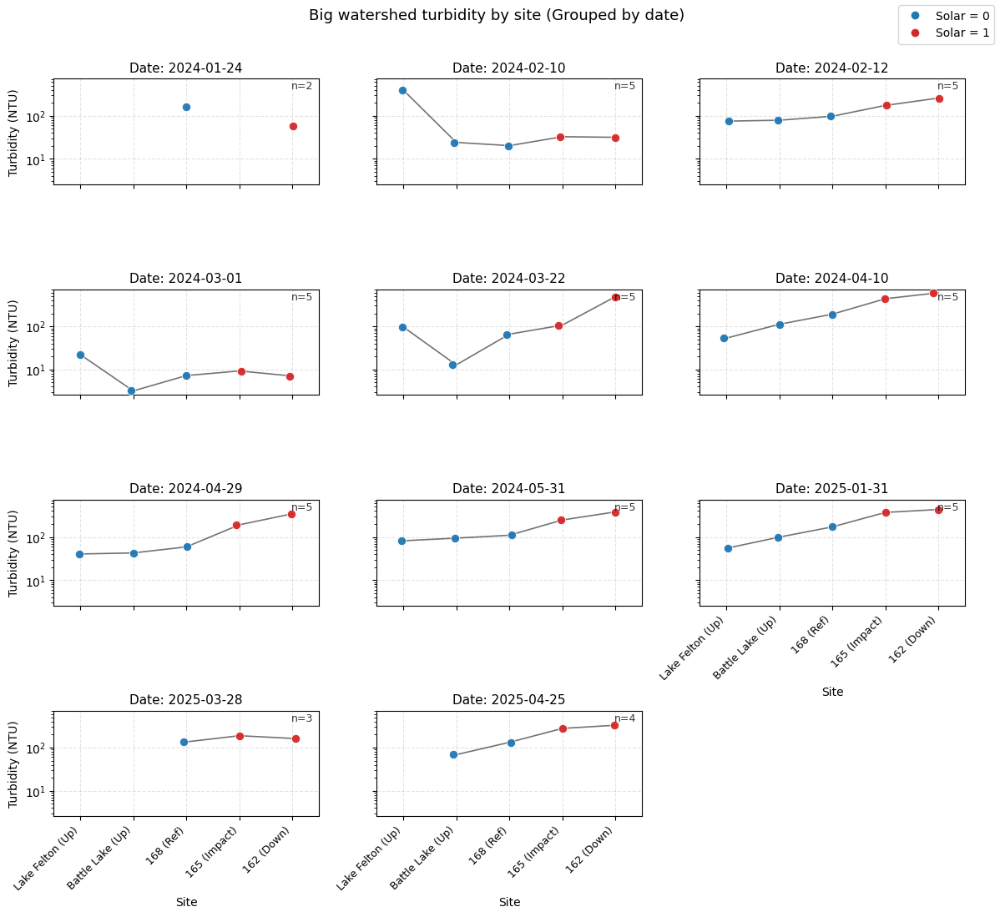

Saved: mart/big_faceted_turbidity.png


In [28]:
"""
BIG watershed – publication-clean faceted turbidity plot (by Date, Site order = upstream→ref→impact→downstream)

Fixes included (per your notes):
1) Battle Lake (and any low values) no longer get clipped:
   - y-limits use true min/max (with buffer) instead of percentiles.
2) X-axis site labels show under the bottommost plot in EACH column
   (not only the very last row), so the right column gets labels too.

Inputs expected columns:
  Date, Site, Turbidity, Solar
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# USER SETTINGS
# ============================================================

DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

# Optional: dates to remove (any parseable format)
DATES_TO_DROP = ["2/15/2024", "1/28/2025"]   # [] to drop none

# Hydrologic order (upstream -> reference -> impact -> downstream)
SITE_ORDER = [
    "Big @ Lake Felton",   # Upstream
    "Big @ Battle Lake",   # Upstream
    "Big @ 168",           # Reference
    "Big @ 165",           # Impact
    "Big @ 162",           # Downstream
]

# Short labels (optional)
USE_SHORT_LABELS = True
LABEL_MAP = {
    "Big @ Lake Felton": "Lake Felton (Up)",
    "Big @ Battle Lake": "Battle Lake (Up)",
    "Big @ 168": "168 (Ref)",
    "Big @ 165": "165 (Impact)",
    "Big @ 162": "162 (Down)",
}

# Plot behavior
LOGY          = True       # turbidity often looks best on log scale
CONNECT_SITES = True       # connect sites using median per date
NCOLS         = 3
FIGSIZE       = (12, 11)
TITLE         = "Big watershed turbidity by site (Grouped by date)"

# If LOGY=True, zeros/negatives cannot be plotted. Choose one:
DROP_NONPOSITIVE_FOR_LOG = True   # recommended

# Save output (optional)
SAVE_FIG = True
OUT_PNG  = "mart/big_faceted_turbidity.png"
DPI      = 600


# ============================================================
# PLOT FUNCTION
# ============================================================

def plot_big_facets(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Big watershed turbidity by site (Grouped by date)",
    drop_nonpositive_for_log=True,
):
    d = df.copy()

    # ---- Parse Date ----
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    # ---- Numeric y ----
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # ---- Log-scale cannot show <= 0 ----
    if logy and drop_nonpositive_for_log:
        d = d[d[y_col] > 0].copy()

    # ---- Drop specific dates ----
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    # ---- Site order ----
    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    # Keep only those sites (prevents unexpected extras)
    d = d[d[site_col].isin(site_order)].copy()

    if len(d) == 0:
        raise ValueError(
            "No rows left after filtering. Check SITE_ORDER matches df[Site] exactly, "
            "and your DATES_TO_DROP / log filtering."
        )

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    # ---- Dates to facet ----
    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    # ---- Layout ----
    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    # ---- Colors ----
    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)  # deterministic jitter

    # ---- Y-limits (FIXED: use true min/max so low values don’t disappear) ----
    y = d[y_col].values
    y_pos = y[np.isfinite(y) & (y > 0)]
    if len(y_pos) == 0:
        y_min, y_max = 0.1, 10
    else:
        y_min = max(y_pos.min() * 0.8, 0.1)
        y_max = y_pos.max() * 1.2

    # ---- X tick labels ----
    if label_map:
        xtick_labels = [label_map.get(s, s) for s in site_order]
    else:
        xtick_labels = site_order

    # ---- Panels ----
    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        # Scatter by Solar category
        for solar_val in sorted(sub[solar_col].dropna().unique()):
            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))  # small jitter
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(int(solar_val), "gray"),
                zorder=3
            )

        # Optional connecting line (median across duplicates)
        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(
                np.arange(len(site_order)), med.values,
                linewidth=1.2, alpha=0.55, color="black", zorder=2
            )

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")
            ax.set_ylim(y_min, y_max)
        else:
            ax.set_ylim(0, y_max)

        # ---- X labels on bottommost plot in EACH column (FIXED) ----
        is_last_in_column = (i + ncols >= n)  # no subplot below in same column
        ax.set_xticks(np.arange(len(site_order)))

        if is_last_in_column:
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")

        # Y label only on left column (keeps it clean)
        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        # panel sample size
        ax.text(
            0.98, 0.98, f"n={len(sub)}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9, alpha=0.8
        )

    # Turn off unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # Legend
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================

label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_big_facets(
    big_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpositive_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")

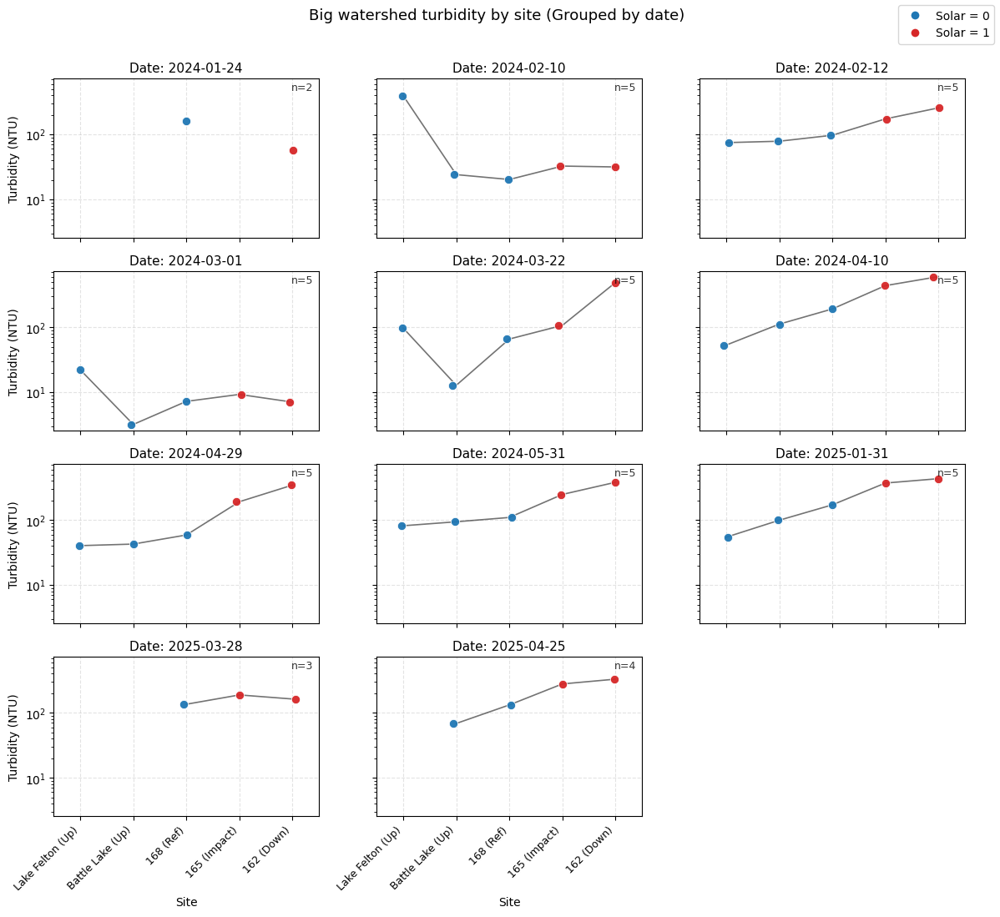

Saved: mart/bigfacetedturbidity.png


In [28]:
"""
BIG watershed – publication-clean faceted turbidity plot (by Date, Site order = upstream→ref→impact→downstream)

Only change made vs your script:
✅ Fix Battle Lake “missing” low values by using TRUE min/max for y-limits (with a small buffer)
   instead of percentile-based limits that can clip low values on log scale.

Everything else is unchanged.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# USER SETTINGS
# ============================================================

DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

# Drop these dates (optional). Use any parseable format.
DATES_TO_DROP = ["2/15/2024", "1/28/2025"]   # [] to drop none

# Hydrologic order (upstream -> reference -> impact -> downstream)
SITE_ORDER = [
    "Big @ Lake Felton",   # Upstream
    "Big @ Battle Lake",   # Upstream
    "Big @ 168",           # Reference
    "Big @ 165",           # Impact
    "Big @ 162",           # Downstream
]

# Plot behavior
LOGY          = True       # turbidity often looks best on log scale
CONNECT_SITES = True       # draw a faint line across sites (median) per date
NCOLS         = 3
FIGSIZE       = (12, 11)

# If LOGY=True, zeros/negatives cannot be plotted. Choose one:
DROP_NONPOSITIVE_FOR_LOG = True   # recommended

# Short labels (optional; keeps internal order by SITE_ORDER)
USE_SHORT_LABELS = True
LABEL_MAP = {
    "Big @ Lake Felton": "Lake Felton (Up)",
    "Big @ Battle Lake": "Battle Lake (Up)",
    "Big @ 168": "168 (Ref)",
    "Big @ 165": "165 (Impact)",
    "Big @ 162": "162 (Down)",
}

TITLE = "Big watershed turbidity by site (Grouped by date)"

# Save output (optional)
SAVE_FIG = True
OUT_PNG  = "mart/bigfacetedturbidity.png"
DPI      = 600


# ============================================================
# FUNCTION
# ============================================================

def plot_big_facets_simple(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Big watershed turbidity by site (faceted by date)",
    drop_nonpositive_for_log=True,
):
    d = df.copy()

    # ---- Parse Date robustly ----
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    # ---- Numeric y ----
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # ---- Drop non-positive for log scale if requested ----
    if logy and drop_nonpositive_for_log:
        d = d[d[y_col] > 0].copy()

    # ---- Drop specific dates ----
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    # ---- Site order ----
    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    # Keep only sites in site_order (prevents random extra sites)
    d = d[d[site_col].isin(site_order)].copy()

    if len(d) == 0:
        raise ValueError(
            "No rows left after filtering. Check SITE_ORDER matches df[Site] exactly, "
            "and your DATES_TO_DROP / log filtering."
        )

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    # ---- Dates to facet ----
    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    # ---- Layout ----
    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    # ---- Styling ----
    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)  # deterministic jitter

    # ---- Consistent y-lims (FIXED: true min/max to avoid clipping low values) ----
    y = d[y_col].values
    y_pos = y[np.isfinite(y) & (y > 0)]
    if len(y_pos) == 0:
        y_min, y_max = 0.1, 10
    else:
        y_min = max(y_pos.min() * 0.8, 0.1)  # <-- FIX: show smallest value (e.g., Battle Lake ~3 NTU)
        y_max = y_pos.max() * 1.2           # <-- FIX: show largest value with a buffer

    # ---- X tick labels ----
    if label_map:
        xtick_labels = [label_map.get(s, s) for s in site_order]
    else:
        xtick_labels = site_order

    # ---- Panels ----
    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        # Scatter by Solar category
        for solar_val in sorted(sub[solar_col].dropna().unique()):
            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))  # small jitter
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(int(solar_val), "gray"),
                zorder=3
            )

        # Optional connecting line (median across duplicates)
        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(
                np.arange(len(site_order)), med.values,
                linewidth=1.2, alpha=0.55, color="black", zorder=2
            )

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")
            ax.set_ylim(y_min, y_max)
        else:
            ax.set_ylim(0, y_max)

        # x labels only bottom row
        if i // ncols == nrows - 1:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels([])
            ax.set_xlabel("")

        # y label only on left column
        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        # panel sample size
        ax.text(
            0.98, 0.98, f"n={len(sub)}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9, alpha=0.8
        )

    # Turn off unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # Legend
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================

label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_big_facets_simple(
    big_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpositive_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")

In [29]:
#### Ploting Big Linear Turbidity values (Actual Values)

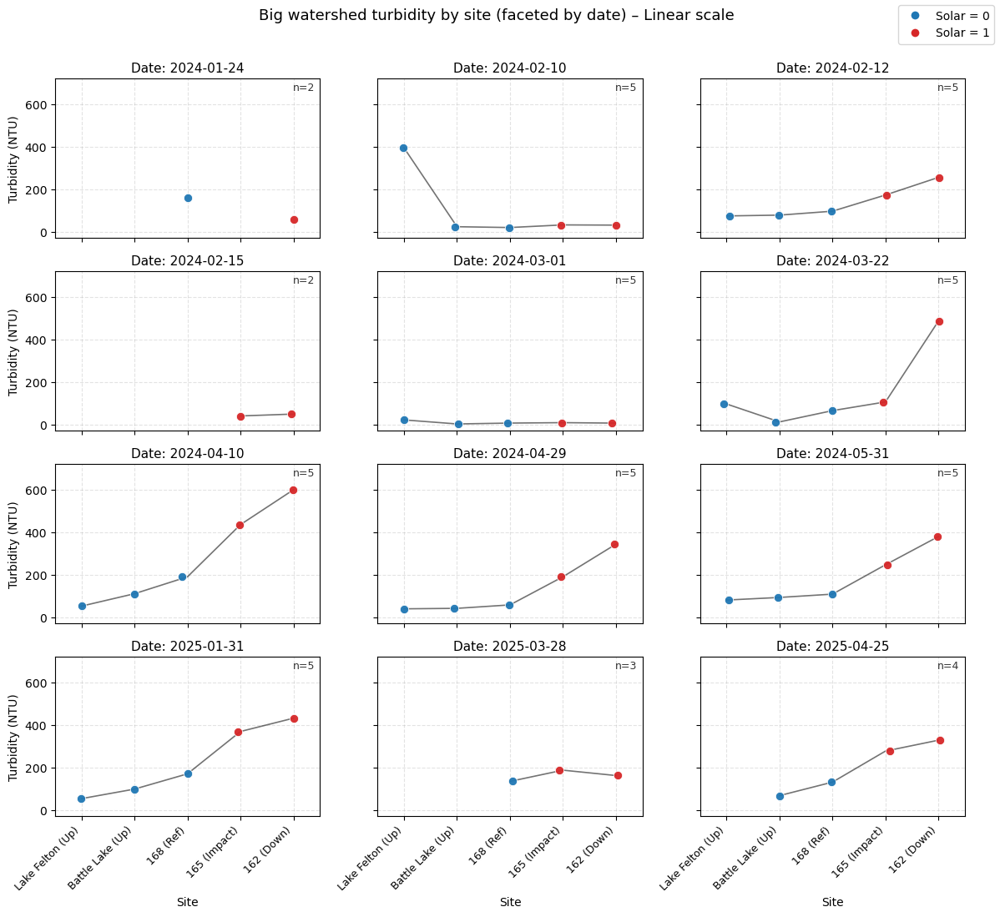

Saved: mart/big_faceted_turbidity_LINEAR.png


In [30]:
"""
Big with original values
Same format/layout as your current faceted plot, but with ORIGINAL (linear) turbidity values
(i.e., NOT log scale).

Only differences vs your current script:
- LOGY = False
- y-axis limits use 0 to max*1.2 (so it looks good on linear scale)
Everything else (layout, colors, legend, connecting line, date facets) stays the same.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# USER SETTINGS
# ============================================================

DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

DATES_TO_DROP = ["1/28/2025"]   # [] to drop none

SITE_ORDER = [
    "Big @ Lake Felton",   # Upstream
    "Big @ Battle Lake",   # Upstream
    "Big @ 168",           # Reference
    "Big @ 165",           # Impact
    "Big @ 162",           # Downstream
]

# ---- KEY CHANGE: linear (original values) ----
LOGY          = False      # <-- linear axis
CONNECT_SITES = True
NCOLS         = 3
FIGSIZE       = (12, 11)

# Only relevant for log scale; harmless to keep
DROP_NONPOSITIVE_FOR_LOG = True

USE_SHORT_LABELS = True
LABEL_MAP = {
    "Big @ Lake Felton": "Lake Felton (Up)",
    "Big @ Battle Lake": "Battle Lake (Up)",
    "Big @ 168": "168 (Ref)",
    "Big @ 165": "165 (Impact)",
    "Big @ 162": "162 (Down)",
}

TITLE = "Big watershed turbidity by site (faceted by date) – Linear scale"

SAVE_FIG = True
OUT_PNG  = "mart/big_faceted_turbidity_LINEAR.png"
DPI      = 600


# ============================================================
# FUNCTION
# ============================================================

def plot_big_facets_simple(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Big watershed turbidity by site (faceted by date)",
    drop_nonpos_for_log=True,
):
    d = df.copy()

    # Parse Date
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    # Numeric y
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # Drop <=0 only if log scale
    if logy and drop_nonpos_for_log:
        d = d[d[y_col] > 0].copy()

    # Drop specific dates
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    # Site order
    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    d = d[d[site_col].isin(site_order)].copy()
    if len(d) == 0:
        raise ValueError("No rows left after filtering. Check SITE_ORDER and filters.")

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    # Dates
    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    # Layout
    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    # Styling
    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)

    # ---- Y limits ----
    y = d[y_col].values
    y_finite = y[np.isfinite(y)]
    if len(y_finite) == 0:
        y_min, y_max = 0, 10
    else:
        if logy:
            y_pos = y_finite[y_finite > 0]
            y_min = max(y_pos.min() * 0.8, 0.1) if len(y_pos) else 0.1
            y_max = y_pos.max() * 1.2 if len(y_pos) else 10
        else:
            y_max = y_finite.max() * 1.2
            pad = 0.04 * y_max          # 3% of the full scale (tweak 0.02–0.06)
            y_min = -pad                # gives breathing room below 0

    # X tick labels
    xtick_labels = [label_map.get(s, s) for s in site_order] if label_map else site_order

    # Panels
    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        for solar_val in sorted(sub[solar_col].dropna().unique()):
            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(int(solar_val), "gray"),
                zorder=3
            )

        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(np.arange(len(site_order)), med.values,
                    linewidth=1.2, alpha=0.55, color="black", zorder=2)

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")
        ax.set_ylim(y_min, y_max)

        # x labels only bottom row
        if i // ncols == nrows - 1:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels([])
            ax.set_xlabel("")

        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        ax.text(0.98, 0.98, f"n={len(sub)}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, alpha=0.8)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================

label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_big_facets_simple(
    big_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,                      # False => linear
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpos_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")

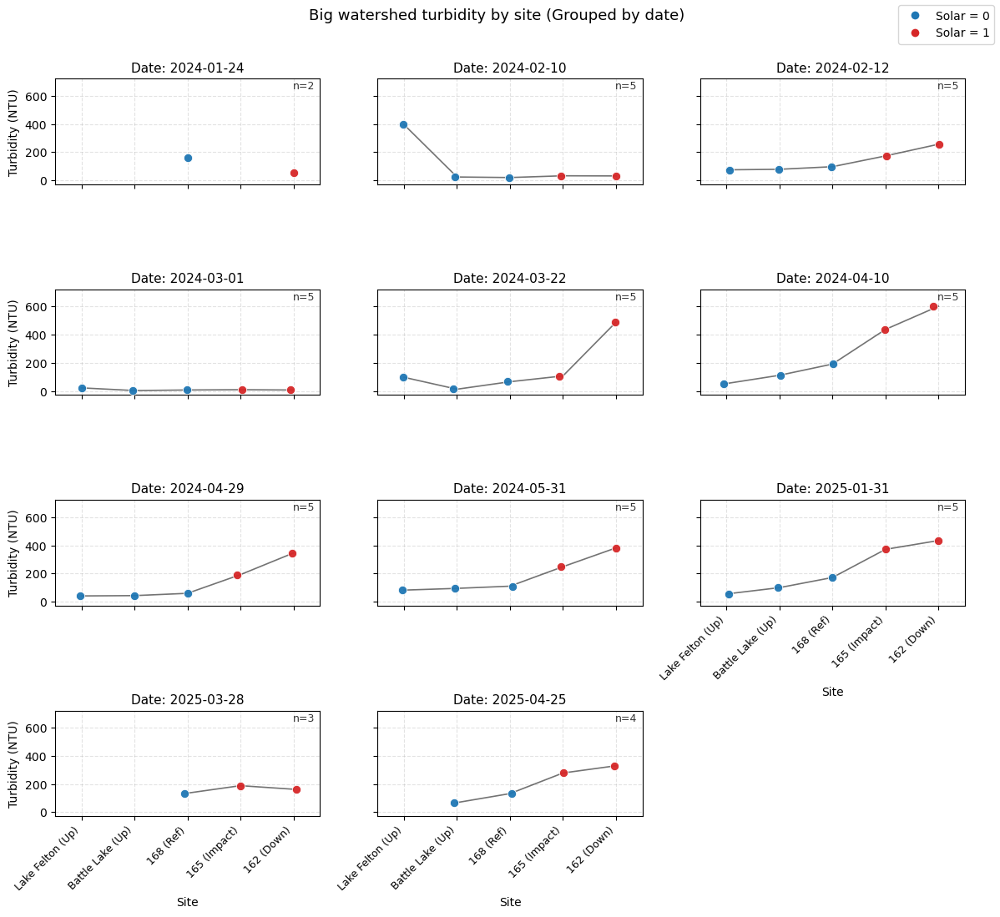

Saved: mart/big_faceted_turbidity_LINEAR2.png


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# USER SETTINGS
# ============================================================

DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

DATES_TO_DROP = ["2/15/2024", "1/28/2025"]   # [] to drop none

SITE_ORDER = [
    "Big @ Lake Felton",
    "Big @ Battle Lake",
    "Big @ 168",
    "Big @ 165",
    "Big @ 162",
]

USE_SHORT_LABELS = True
LABEL_MAP = {
    "Big @ Lake Felton": "Lake Felton (Up)",
    "Big @ Battle Lake": "Battle Lake (Up)",
    "Big @ 168": "168 (Ref)",
    "Big @ 165": "165 (Impact)",
    "Big @ 162": "162 (Down)",
}

# Plot behavior
LOGY          = False      ### CHANGED ### (linear)
CONNECT_SITES = True
NCOLS         = 3
FIGSIZE       = (12, 11)
TITLE         = "Big watershed turbidity by site (Grouped by date)"  ### CHANGED ###

# Only used when LOGY=True; harmless to keep True
DROP_NONPOSITIVE_FOR_LOG = True

SAVE_FIG = True
OUT_PNG  = "mart/big_faceted_turbidity_LINEAR2.png"   ### CHANGED ###
DPI      = 600


# ============================================================
# PLOT FUNCTION
# ============================================================

def plot_big_facets(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Big watershed turbidity by site (Grouped by date)",
    drop_nonpositive_for_log=True,
):
    d = df.copy()

    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # Only apply this filter if log scale
    if logy and drop_nonpositive_for_log:
        d = d[d[y_col] > 0].copy()

    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    d = d[d[site_col].isin(site_order)].copy()

    if len(d) == 0:
        raise ValueError(
            "No rows left after filtering. Check SITE_ORDER matches df[Site] exactly, "
            "and your DATES_TO_DROP / log filtering."
        )

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)

    # ---- Y-limits ----
    y = d[y_col].values
    y_finite = y[np.isfinite(y)]

    if len(y_finite) == 0:
        y_min, y_max = (0.0, 10.0)
    else:
        if logy:
            # log-scale: true min/max (positive only)
            y_pos = y_finite[y_finite > 0]
            if len(y_pos) == 0:
                y_min, y_max = (0.1, 10.0)
            else:
                y_min = max(y_pos.min() * 0.8, 0.1)
                y_max = y_pos.max() * 1.2
        else:
            # linear-scale: start a bit below 0 so tiny points don't sit on the axis
            y_max = y_finite.max() * 1.2
            pad = 0.04 * y_max          ### CHANGED ### (adds breathing room)
            y_min = -pad                ### CHANGED ###

    xtick_labels = [label_map.get(s, s) for s in site_order] if label_map else site_order

    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        for solar_val in sorted(sub[solar_col].dropna().unique()):
            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(int(solar_val), "gray"),
                zorder=3
            )

        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(np.arange(len(site_order)), med.values,
                    linewidth=1.2, alpha=0.55, color="black", zorder=2)

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")

        ax.set_ylim(y_min, y_max)

        is_last_in_column = (i + ncols >= n)
        ax.set_xticks(np.arange(len(site_order)))

        if is_last_in_column:
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")

        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        ax.text(0.98, 0.98, f"n={len(sub)}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, alpha=0.8)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================

label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_big_facets(
    big_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,  # False => linear
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpositive_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")


In [32]:
#### Plotting Rainfall and Water Pressure

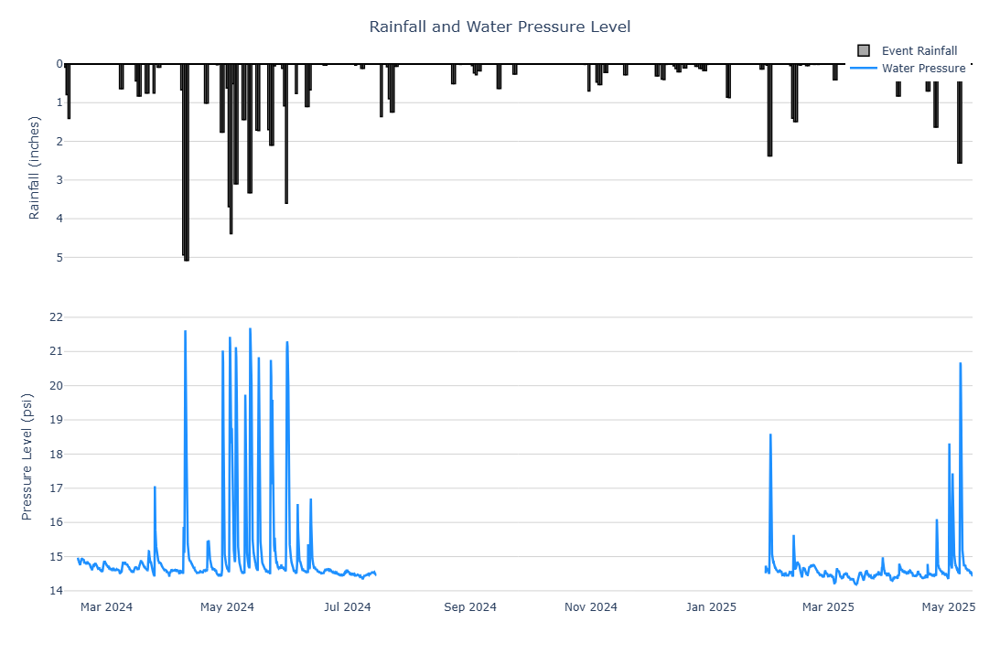

In [34]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ============================================================
# PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_2.15.24__7.15.24__OttoSolar_21839259.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_1.28.25_5.16.25_21839259.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/otto_results/new_weather.csv"

# Optional: restrict plotting window (set to None to auto)
PLOT_START = None   # e.g. "2024-02-01"
PLOT_END   = None   # e.g. "2025-05-12"

# Break the pressure line if gap > this many hours
GAP_HOURS = 24


# ============================================================
# READERS
# ============================================================
def read_pressure_hobo(filepath: str) -> pd.DataFrame:
    """
    Robust reader for HOBO/Onset export:
    Finds the header line containing 'Date Time' and 'Abs Pres'
    then reads from there with python engine.
    Returns columns: DateTime, pressure
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:300]):
        if ("Date Time" in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Header with 'Date Time' and 'Abs Pres' not found in: {filepath}")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Drop leading index column if present
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    dt_col = next((c for c in df.columns if "Date Time" in str(c)), None)
    p_col  = next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)

    if dt_col is None or p_col is None:
        raise ValueError(f"Could not find Date Time / Abs Pres columns in: {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, p_col]].copy()
    out.columns = ["DateTime", "pressure"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure"] = pd.to_numeric(out["pressure"], errors="coerce")
    out = out.dropna(subset=["DateTime", "pressure"]).sort_values("DateTime").reset_index(drop=True)

    return out


def read_rain_dailymax(filepath: str) -> pd.DataFrame:
    """
    Reads rain 5-min file and computes DAILY MAX of Event Rain (in)
    Output columns: Date, rain_event_max
    """
    rain = pd.read_csv(filepath, dtype=str, encoding_errors="ignore")

    simple_col = next((c for c in rain.columns if str(c).strip().lower() == "simple date"), None)
    event_col  = next((c for c in rain.columns if "event rain" in str(c).lower()), None)

    if simple_col is None or event_col is None:
        raise ValueError(f"Could not find 'Simple Date' / 'Event Rain' columns.\nColumns: {list(rain.columns)}")

    rain = rain[[simple_col, event_col]].copy()
    rain.columns = ["Date", "EventRain_in"]

    rain["Date"] = pd.to_datetime(rain["Date"], errors="coerce").dt.normalize()
    rain["EventRain_in"] = pd.to_numeric(rain["EventRain_in"], errors="coerce")
    rain = rain.dropna(subset=["Date", "EventRain_in"])

    daily = (
        rain.groupby("Date", as_index=False)["EventRain_in"]
            .max()
            .rename(columns={"EventRain_in": "rain_event_max"})
            .sort_values("Date")
            .reset_index(drop=True)
    )
    return daily


def break_line_on_gaps(df: pd.DataFrame, time_col: str, gap_hours: float) -> pd.DataFrame:
    """
    Inserts NaNs to break the line when time gaps exceed gap_hours.
    Plotly breaks lines where y is NaN.
    """
    d = df.sort_values(time_col).copy()
    dt = d[time_col].values
    gaps = (d[time_col].diff().dt.total_seconds() / 3600.0)
    d.loc[gaps > gap_hours, "pressure"] = np.nan
    return d


# ============================================================
# LOAD + ALIGN
# ============================================================
p1 = read_pressure_hobo(PRESSURE_CSV_1)
p2 = read_pressure_hobo(PRESSURE_CSV_2)
pressure = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_dailymax(RAIN_CSV)

# Trim pressure to rainfall max date (end together)
rain_end = rain_daily["Date"].max()
pressure = pressure[pressure["DateTime"] <= (rain_end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()

# Plot window
auto_start = min(pressure["DateTime"].min().normalize(), rain_daily["Date"].min())
auto_end   = rain_end

start = pd.to_datetime(PLOT_START).normalize() if PLOT_START else auto_start
end   = pd.to_datetime(PLOT_END).normalize()   if PLOT_END   else auto_end

pressure = pressure[(pressure["DateTime"] >= start) & (pressure["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_daily = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# Break pressure line across big gaps so it doesn't draw a fake segment
pressure = break_line_on_gaps(pressure, "DateTime", GAP_HOURS)

# Rain bars should be negative so they point downward
rain_daily["rain_bar"] = -rain_daily["rain_event_max"]


# ============================================================
# PLOT (PLOTLY)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    row_heights=[0.42, 0.58]
)

# Top: Rain bars (downward)
fig.add_trace(
    go.Bar(
        x=rain_daily["Date"],
        y=rain_daily["rain_bar"],
        name="Event Rainfall",
        marker=dict(color="darkgray", line=dict(color="black", width=1.5)),
        hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
        customdata=rain_daily["rain_event_max"],
    ),
    row=1, col=1
)

# Bottom: Water pressure line
fig.add_trace(
    go.Scatter(
        x=pressure["DateTime"],
        y=pressure["pressure"],
        name="Water Pressure",
        mode="lines",
        line=dict(color="dodgerblue", width=2.5),
        hovertemplate="DateTime: %{x|%Y-%m-%d %H:%M}<br>Pressure: %{y:.2f} psi<extra></extra>",
    ),
    row=2, col=1
)

# Y axis for rain: reversed so negative bars “hang down” from 0, but labels show positive
# We'll set tick labels as positive text while values are negative.
rain_max = float(rain_daily["rain_event_max"].max()) if len(rain_daily) else 1.0
tick_step = 1.0 if rain_max >= 4 else 0.5
ticks = np.arange(0, rain_max + tick_step, tick_step)

fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    #autorange="reversed",
    tickvals=-ticks,
    ticktext=[f"{t:g}" for t in ticks],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black"
)

fig.update_yaxes(
    title_text="Pressure Level (psi)",
    row=2, col=1,
    showgrid=True,
    gridcolor="lightgray"
)

# Layout
fig.update_layout(
    title=dict(text="Rainfall and Water Pressure Level", x=0.5),
    height=700,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="white",
    bargap=0.1,
    legend=dict(x=0.86, y=1.05),
    margin=dict(l=70, r=30, t=70, b=60)
)

# Clean x-axis formatting
fig.update_xaxes(showgrid=False)
fig.update_xaxes(tickformat="%b %Y", row=2, col=1)

fig.show()

In [135]:
### Plot Rainfall PSI 2025 + Summary Table


SUMMARY TABLES (2025)

--- Rain distribution (Daily MAX of Event Rain, inches) ---
Daily max event rain (in)  Days  Percent
                   0–0.01    94     71.2
                0.01–0.10     8      6.1
                0.10–0.25     5      3.8
                0.25–0.50    10      7.6
                 0.50–1.0     6      4.5
                  1.0–2.0     5      3.8
                     2.0+     4      3.0

--- Rain summary ---
Days in period: 132
Days with rain > 0: 38
Mean:   0.204
Median: 0.000
P90:    0.700
P95:    1.490
Max:    2.560
Sum of daily max: 26.940

--- Water pressure stats (psi) ---
    n    min    p05    p25  median  mean    p75    p95    max  std
15068 14.175 14.329 14.438  14.506 14.64 14.617 15.178 20.678 0.64


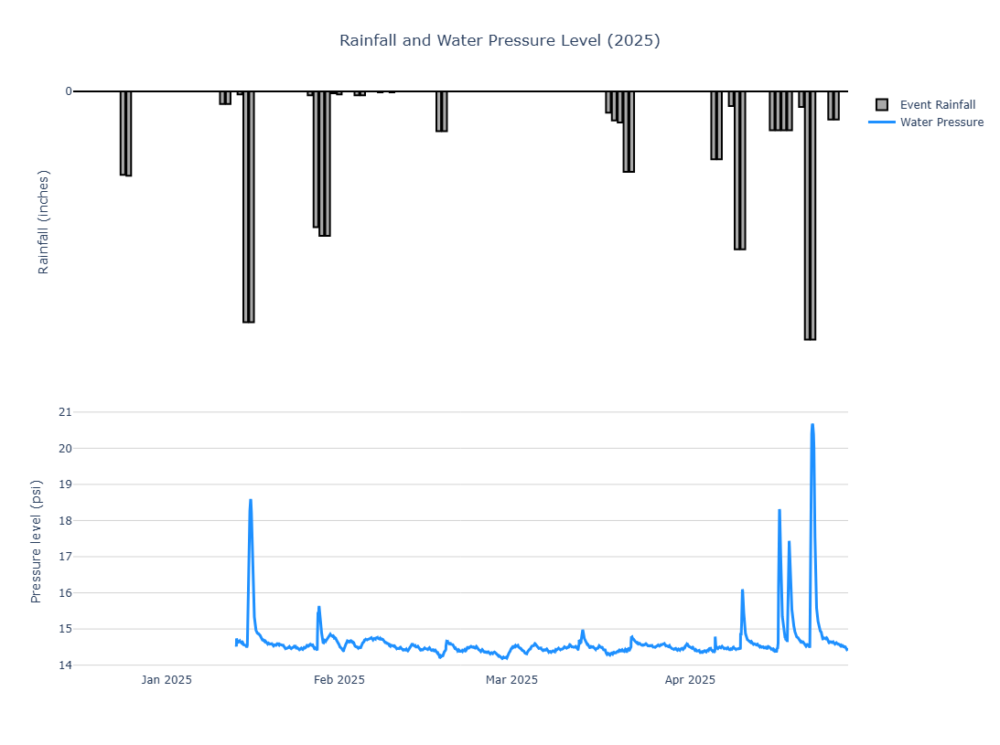

In [86]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_2.15.24__7.15.24__OttoSolar_21839259.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_1.28.25_5.16.25_21839259.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/otto_results/new_weather.csv"                 # 02/09/2024–05/12/2025

# Focus year
YEAR_FOCUS = 2025

# Pressure line: break if gap > N hours (prevents fake line across missing months)
GAP_HOURS = 24

# Rain distribution bins (inches) for summary
RAIN_BINS = [0, 0.01, 0.10, 0.25, 0.50, 1.0, 2.0, np.inf]
RAIN_BIN_LABELS = ["0–0.01", "0.01–0.10", "0.10–0.25", "0.25–0.50", "0.50–1.0", "1.0–2.0", "2.0+"]


# ============================================================
# PRESSURE READER (ROBUST FOR YOUR EXPORT FORMAT)
# ============================================================
PRESSURE_DT_COL = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

def read_pressure_csv_hobo(filepath: str) -> pd.DataFrame:
    """
    Finds the header row (line containing Date Time, GMT-06:00 and Abs Pres, psi...)
    then reads from there and keeps only DateTime + pressure.
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if (PRESSURE_DT_COL in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header row in {filepath} containing '{PRESSURE_DT_COL}'")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Some exports have a leading index column '#'
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    # Ensure the exact columns exist (use substring fallback if needed)
    if PRESSURE_DT_COL not in df.columns:
        dt_col = next((c for c in df.columns if "Date Time" in str(c)), None)
    else:
        dt_col = PRESSURE_DT_COL

    if PRESSURE_PSI_COL not in df.columns:
        psi_col = next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)
    else:
        psi_col = PRESSURE_PSI_COL

    if dt_col is None or psi_col is None:
        raise ValueError(f"Could not locate DateTime/Pressure columns in {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, psi_col]].copy()
    out.columns = ["DateTime", "pressure_psi"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure_psi"] = pd.to_numeric(out["pressure_psi"], errors="coerce")

    out = out.dropna(subset=["DateTime", "pressure_psi"]).sort_values("DateTime").reset_index(drop=True)
    return out


def break_pressure_line_on_gaps(df: pd.DataFrame, gap_hours: float) -> pd.DataFrame:
    """
    Inserts NaNs where the time gap exceeds gap_hours so Plotly breaks the line.
    """
    d = df.sort_values("DateTime").copy()
    gaps = d["DateTime"].diff().dt.total_seconds() / 3600.0
    d.loc[gaps > gap_hours, "pressure_psi"] = np.nan
    return d


# ============================================================
# RAIN READER (YOUR COLUMN NAMES)
# ============================================================
RAIN_DATE_COL = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

def read_rain_daily_max(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")

    if RAIN_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(f"Rain CSV missing expected columns. Found: {list(rain.columns)}")

    r = rain[[RAIN_DATE_COL, RAIN_EVENT_COL]].copy()
    r["Date"] = pd.to_datetime(r[RAIN_DATE_COL], errors="coerce").dt.normalize()
    r["EventRain_in"] = pd.to_numeric(r[RAIN_EVENT_COL], errors="coerce")

    r = r.dropna(subset=["Date", "EventRain_in"])

    daily = (
        r.groupby("Date", as_index=False)["EventRain_in"]
         .max()
         .rename(columns={"EventRain_in": "DailyMaxEventRain_in"})
         .sort_values("Date")
         .reset_index(drop=True)
    )
    return daily


# ============================================================
# LOAD + FILTER TO YEAR
# ============================================================
p1 = read_pressure_csv_hobo(PRESSURE_CSV_1)
p2 = read_pressure_csv_hobo(PRESSURE_CSV_2)
pressure = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_daily_max(RAIN_CSV)

start = pd.Timestamp(f"{YEAR_FOCUS}-01-01")
end   = pd.Timestamp(f"{YEAR_FOCUS}-12-31")

pressure_y = pressure[(pressure["DateTime"] >= start) & (pressure["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_y = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# Trim pressure to end at last rainfall day in the year (if rain exists)
if len(rain_y) > 0:
    rain_end = rain_y["Date"].max()
    pressure_y = pressure_y[pressure_y["DateTime"] <= (rain_end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()

# Break pressure line across gaps
pressure_y = break_pressure_line_on_gaps(pressure_y, GAP_HOURS)

# Make rain bars downward (negative)
rain_y["RainDown"] = rain_y["DailyMaxEventRain_in"]

# Build rain axis ticks (positive labels)
rain_max = float(rain_y["DailyMaxEventRain_in"].max()) if len(rain_y) else 1.0
tick_step = 0.5 if rain_max <= 3 else 1.0
ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
ticks_neg = -ticks_pos


# ============================================================
# SUMMARY TABLES (PRINT)
# ============================================================
print("\n============================")
print(f"SUMMARY TABLES ({YEAR_FOCUS})")
print("============================")

# Rain distribution
if len(rain_y) == 0:
    print("\nRain: No records found.")
else:
    rvals = rain_y["DailyMaxEventRain_in"]
    bins = pd.cut(rvals, bins=RAIN_BINS, labels=RAIN_BIN_LABELS, include_lowest=True, right=False)

    rain_dist = (
        bins.value_counts()
            .rename_axis("Daily max event rain (in)")
            .reset_index(name="Days")
            .sort_values("Daily max event rain (in)")
    )
    rain_dist["Percent"] = (rain_dist["Days"] / rain_dist["Days"].sum() * 100).round(1)

    print("\n--- Rain distribution (Daily MAX of Event Rain, inches) ---")
    print(rain_dist.to_string(index=False))

    print("\n--- Rain summary ---")
    print(f"Days in period: {len(rvals)}")
    print(f"Days with rain > 0: {(rvals > 0).sum()}")
    print(f"Mean:   {rvals.mean():.3f}")
    print(f"Median: {rvals.median():.3f}")
    print(f"P90:    {rvals.quantile(0.90):.3f}")
    print(f"P95:    {rvals.quantile(0.95):.3f}")
    print(f"Max:    {rvals.max():.3f}")
    print(f"Sum of daily max: {rvals.sum():.3f}")

# Pressure stats
pvals = pressure_y["pressure_psi"].dropna()
if len(pvals) == 0:
    print("\nPressure: No records found.")
else:
    stats = pd.DataFrame([{
        "n": len(pvals),
        "min": pvals.min(),
        "p05": pvals.quantile(0.05),
        "p25": pvals.quantile(0.25),
        "median": pvals.median(),
        "mean": pvals.mean(),
        "p75": pvals.quantile(0.75),
        "p95": pvals.quantile(0.95),
        "max": pvals.max(),
        "std": pvals.std(),
    }]).round(3)

    print("\n--- Water pressure stats (psi) ---")
    print(stats.to_string(index=False))


# ============================================================
# PLOTLY FIGURE (MATCH YOUR FORMAT)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.10,
    row_heights=[0.5, 0.5]
)

# Rain bars (down)
fig.add_trace(go.Bar(
    x=rain_y["Date"],
    y=rain_y["RainDown"],  # negative => down
    name="Event Rainfall",
    marker=dict(color="darkgray", line=dict(color="black", width=2)),
    hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
    customdata=rain_y["DailyMaxEventRain_in"],
), row=1, col=1)

# Pressure line
fig.add_trace(go.Scatter(
    x=pressure_y["DateTime"],
    y=pressure_y["pressure_psi"],
    name="Water Pressure",
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    showlegend=True
), row=2, col=1)

# Layout
fig.update_layout(
    title=f"Rainfall and Water Pressure Level ({YEAR_FOCUS})",
    xaxis_title="",
    height=800,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    title_x=0.5,
)

# Rain axis: reversed so bars hang down; labels show positive
fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    autorange="reversed",
    tickvals=ticks_neg,
    ticktext=[f"{t:g}" for t in ticks_pos],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black",
)

# Pressure axis
fig.update_yaxes(
    title_text="Pressure level (psi)",
    row=2, col=1,
    showgrid=True,
    gridcolor="lightgray",
)

# X axis: monthly ticks (prevents duplicate Jan 2025)
fig.update_xaxes(
    row=2, col=1,
    dtick="M1",
    tickformat="%b %Y",
    ticklabelmode="period"
)

fig.show()

In [ ]:
#### Plot Rainfall PSI 2025

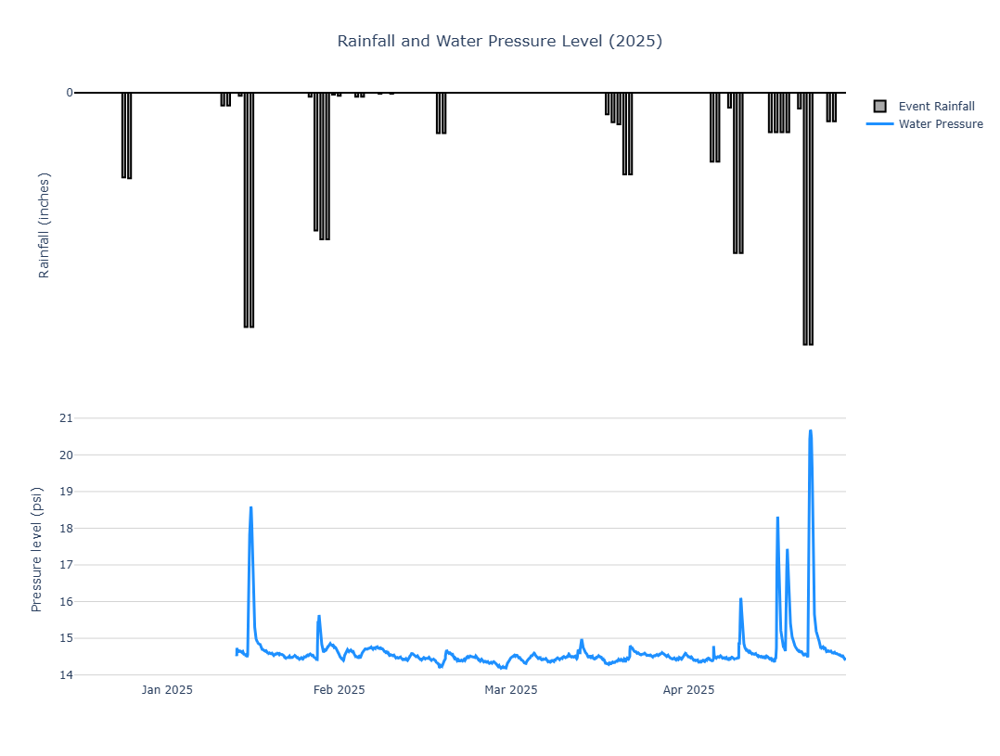

In [97]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_2.15.24__7.15.24__OttoSolar_21839259.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_1.28.25_5.16.25_21839259.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/otto_results/new_weather.csv"  

YEAR_FOCUS = 2025

# ============================================================
# CSV COLUMN NAMES (FROM YOUR FILES)
# ============================================================
PRESSURE_DT_COL = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

RAIN_SIMPLE_DATE_COL = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

# ============================================================
# READ PRESSURE (HOBO EXPORT WITH PLOT TITLE LINES)
# ============================================================
def read_pressure_hobo(filepath: str) -> pd.DataFrame:
    # Find the header row that contains the Date Time column
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if PRESSURE_DT_COL in line:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header containing '{PRESSURE_DT_COL}' in: {filepath}")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Drop leading index column if present ("#" column)
    if len(df.columns) and str(df.columns[0]).strip() == "#":
        df = df.drop(columns=[df.columns[0]])

    # Keep only the two columns we need
    if PRESSURE_DT_COL not in df.columns or PRESSURE_PSI_COL not in df.columns:
        raise ValueError(
            f"Expected columns not found in {filepath}\n"
            f"Missing: {[c for c in [PRESSURE_DT_COL, PRESSURE_PSI_COL] if c not in df.columns]}\n"
            f"Columns found: {list(df.columns)}"
        )

    out = df[[PRESSURE_DT_COL, PRESSURE_PSI_COL]].copy()
    out.columns = ["DateTime", "pressure"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure"] = pd.to_numeric(out["pressure"], errors="coerce")

    out = out.dropna(subset=["DateTime", "pressure"]).sort_values("DateTime").reset_index(drop=True)
    return out

# ============================================================
# READ RAIN (5-MIN) -> DAILY MAX EVENT RAIN
# ============================================================
def read_rain_dailymax(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")

    if RAIN_SIMPLE_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(
            f"Expected rain columns not found.\n"
            f"Missing: {[c for c in [RAIN_SIMPLE_DATE_COL, RAIN_EVENT_COL] if c not in rain.columns]}\n"
            f"Columns found: {list(rain.columns)}"
        )

    rain = rain[[RAIN_SIMPLE_DATE_COL, RAIN_EVENT_COL]].copy()
    rain.columns = ["Date", "EventRain"]

    rain["Date"] = pd.to_datetime(rain["Date"], errors="coerce").dt.normalize()
    rain["EventRain"] = pd.to_numeric(rain["EventRain"], errors="coerce")

    rain = rain.dropna(subset=["Date", "EventRain"])

    daily = (rain.groupby("Date", as_index=False)["EventRain"]
                .max()
                .rename(columns={"EventRain": "daily_max_event_rain"}))
    return daily.sort_values("Date").reset_index(drop=True)

# ============================================================
# LOAD DATA
# ============================================================
p1 = read_pressure_hobo(PRESSURE_CSV_1)
p2 = read_pressure_hobo(PRESSURE_CSV_2)
pressure_df = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_dailymax(RAIN_CSV)

# ============================================================
# FILTER TO 2025 ONLY
# ============================================================
start = pd.Timestamp(f"{YEAR_FOCUS}-01-01")
end   = pd.Timestamp(f"{YEAR_FOCUS}-12-31")

pressure_df = pressure_df[(pressure_df["DateTime"] >= start) & (pressure_df["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_daily  = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# Trim pressure to rainfall max date so both end together (as you requested)
if len(rain_daily):
    rain_end = rain_daily["Date"].max()
    pressure_df = pressure_df[pressure_df["DateTime"] <= (rain_end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()

# ============================================================
# MAKE RAIN BARS FACE DOWN
# ============================================================
rain_daily["rain_down"] = rain_daily["daily_max_event_rain"]    # I removed the negative sign -rain_daily

# ticks: show positive labels even though values are negative
rain_max = float(rain_daily["daily_max_event_rain"].max()) if len(rain_daily) else 1.0
tick_step = 0.5 if rain_max <= 3 else 1.0
ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
ticks_neg = -ticks_pos

# ============================================================
# PLOT (YOUR FORMAT)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[0.5, 0.5]
)

# Rain bars (downward)
fig.add_trace(go.Bar(
    x=rain_daily["Date"],
    y=rain_daily["rain_down"],  # NEGATIVE => downward
    name="Event Rainfall",
    marker=dict(color="darkgray", line=dict(color="black", width=2)),
    hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
    customdata=rain_daily["daily_max_event_rain"],
), row=1, col=1)

# Water pressure line
fig.add_trace(go.Scatter(
    x=pressure_df["DateTime"],
    y=pressure_df["pressure"],
    name="Water Pressure",
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    showlegend=True
), row=2, col=1)

# Layout
fig.update_layout(
    title=f"Rainfall and Water Pressure Level ({YEAR_FOCUS})",
    xaxis_title="",
    height=800,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    title_x=0.5,
)

# Rain axis formatting (reversed + positive tick labels)
fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    autorange="reversed",
    tickvals=ticks_neg,
    ticktext=[f"{t:g}" for t in ticks_pos],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black",
)

# Pressure axis formatting
fig.update_yaxes(
    title_text="Pressure level (psi)",
    row=2, col=1,
    showgrid=True,
    gridcolor="lightgray",
)

# X-axis: monthly ticks to prevent duplicate labels
fig.update_xaxes(
    row=2, col=1,
    dtick="M1",
    tickformat="%b %Y",
    ticklabelmode="period"
)
fig.update_layout(bargap=0.5)  # bigger gap => bars look thinner

fig.show()

In [98]:
#### Plot Rainfall PSI 2024

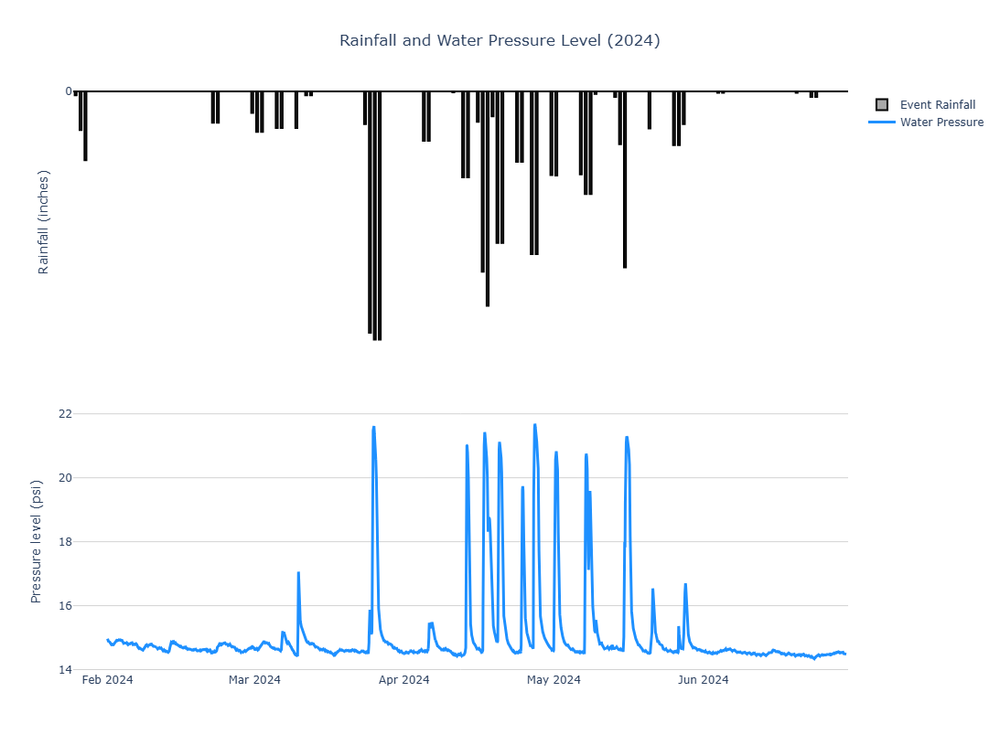

In [103]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_2.15.24__7.15.24__OttoSolar_21839259.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_1.28.25_5.16.25_21839259.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/My Box Notes/Water_Quality_Work/watersheds/otto_results/new_weather.csv"  

YEAR_FOCUS = 2024

# ============================================================
# CSV COLUMN NAMES (FROM YOUR FILES)
# ============================================================
PRESSURE_DT_COL = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

RAIN_SIMPLE_DATE_COL = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

# ============================================================
# READ PRESSURE (HOBO EXPORT WITH PLOT TITLE LINES)
# ============================================================
def read_pressure_hobo(filepath: str) -> pd.DataFrame:
    # Find the header row that contains the Date Time column
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if PRESSURE_DT_COL in line:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header containing '{PRESSURE_DT_COL}' in: {filepath}")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Drop leading index column if present ("#" column)
    if len(df.columns) and str(df.columns[0]).strip() == "#":
        df = df.drop(columns=[df.columns[0]])

    # Keep only the two columns we need
    if PRESSURE_DT_COL not in df.columns or PRESSURE_PSI_COL not in df.columns:
        raise ValueError(
            f"Expected columns not found in {filepath}\n"
            f"Missing: {[c for c in [PRESSURE_DT_COL, PRESSURE_PSI_COL] if c not in df.columns]}\n"
            f"Columns found: {list(df.columns)}"
        )

    out = df[[PRESSURE_DT_COL, PRESSURE_PSI_COL]].copy()
    out.columns = ["DateTime", "pressure"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure"] = pd.to_numeric(out["pressure"], errors="coerce")

    out = out.dropna(subset=["DateTime", "pressure"]).sort_values("DateTime").reset_index(drop=True)
    return out

# ============================================================
# READ RAIN (5-MIN) -> DAILY MAX EVENT RAIN
# ============================================================
def read_rain_dailymax(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")

    if RAIN_SIMPLE_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(
            f"Expected rain columns not found.\n"
            f"Missing: {[c for c in [RAIN_SIMPLE_DATE_COL, RAIN_EVENT_COL] if c not in rain.columns]}\n"
            f"Columns found: {list(rain.columns)}"
        )

    rain = rain[[RAIN_SIMPLE_DATE_COL, RAIN_EVENT_COL]].copy()
    rain.columns = ["Date", "EventRain"]

    rain["Date"] = pd.to_datetime(rain["Date"], errors="coerce").dt.normalize()
    rain["EventRain"] = pd.to_numeric(rain["EventRain"], errors="coerce")

    rain = rain.dropna(subset=["Date", "EventRain"])

    daily = (rain.groupby("Date", as_index=False)["EventRain"]
                .max()
                .rename(columns={"EventRain": "daily_max_event_rain"}))
    return daily.sort_values("Date").reset_index(drop=True)

# ============================================================
# LOAD DATA
# ============================================================
p1 = read_pressure_hobo(PRESSURE_CSV_1)
p2 = read_pressure_hobo(PRESSURE_CSV_2)
pressure_df = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_dailymax(RAIN_CSV)

# ============================================================
# FILTER TO 2025 ONLY
# ============================================================
start = pd.Timestamp(f"{YEAR_FOCUS}-01-01")
end   = pd.Timestamp(f"{YEAR_FOCUS}-12-31")

# ============================================================
# FILTER TO YEAR_FOCUS (FIX)
# ============================================================
pressure_df = pressure_df[(pressure_df["DateTime"] >= start) & (pressure_df["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_daily  = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# ============================================================
# ALIGN END DATES: stop rainfall where PSI ends (for this year)
# ============================================================
if len(pressure_df) == 0:
    raise ValueError("No pressure data found in the selected YEAR_FOCUS window.")

psi_end_day = pressure_df["DateTime"].max().normalize()
rain_daily = rain_daily[rain_daily["Date"] <= psi_end_day].copy()
#=================================================================
#==================================================================


# ============================================================
# MAKE RAIN BARS FACE DOWN
# ============================================================
rain_daily["rain_down"] = rain_daily["daily_max_event_rain"]    # I removed the negative sign -rain_daily

# ticks: show positive labels even though values are negative
rain_max = float(rain_daily["daily_max_event_rain"].max()) if len(rain_daily) else 1.0
tick_step = 0.5 if rain_max <= 3 else 1.0
ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
ticks_neg = -ticks_pos

# ============================================================
# PLOT (YOUR FORMAT)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[0.5, 0.5]
)

# Rain bars (downward)
fig.add_trace(go.Bar(
    x=rain_daily["Date"],
    y=rain_daily["rain_down"],  # NEGATIVE => downward
    name="Event Rainfall",
    marker=dict(color="darkgray", line=dict(color="black", width=2)),
    hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
    customdata=rain_daily["daily_max_event_rain"],
), row=1, col=1)

# Water pressure line
fig.add_trace(go.Scatter(
    x=pressure_df["DateTime"],
    y=pressure_df["pressure"],
    name="Water Pressure",
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    showlegend=True
), row=2, col=1)

# Layout
fig.update_layout(
    title=f"Rainfall and Water Pressure Level ({YEAR_FOCUS})",
    xaxis_title="",
    height=800,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    title_x=0.5,
)

# Rain axis formatting (reversed + positive tick labels)
fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    autorange="reversed",
    tickvals=ticks_neg,
    ticktext=[f"{t:g}" for t in ticks_pos],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black",
)

# Pressure axis formatting
fig.update_yaxes(
    title_text="Pressure level (psi)",
    row=2, col=1,
    showgrid=True,
    gridcolor="lightgray",
)

# X-axis: monthly ticks to prevent duplicate labels
fig.update_xaxes(
    row=2, col=1,
    dtick="M1",
    tickformat="%b %Y",
    ticklabelmode="period"
)
fig.update_layout(bargap=0.6)  # bigger gap => bars look thinner

fig.show()

In [105]:
## Hogpen Analaysis

In [25]:
hog_ntu = mart_ntu.loc[mart_ntu['Creek'] == 'Hogpen', ['Date', 'Site', 'Solar', 'Avg Turbidity NTU']]
print(hog_ntu.shape)
hog_ntu.head()

(28, 4)


,Date,Site,Solar,Avg Turbidity NTU
16,2024-02-10,Hogpen @ 162,1.0,19.600
17,2024-02-10,Hogpen @ 174,1.0,12.467
18,2024-02-10,Hogpen @ LCR 608,0.0,11.400
29,2024-02-12,Hogpen @ 162,1.0,200.833
30,2024-02-12,Hogpen @ 174,1.0,139.333


In [26]:
hog_ntu = hog_ntu.rename(columns={'Avg Turbidity NTU': 'Turbidity'})
print(hog_ntu.value_counts('Site'))
hog_ntu.info()

Site
Hogpen @ LCR 608    10
Hogpen @ 162         9
Hogpen @ 174         9
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 28 entries, 16 to 126
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       28 non-null     str    
 1   Site       28 non-null     str    
 2   Solar      28 non-null     float64
 3   Turbidity  28 non-null     float64
dtypes: float64(2), str(2)
memory usage: 1.1 KB


In [27]:
hog_ntu.value_counts('Date')

Date
2024-02-10    3
2024-02-12    3
2024-03-01    3
2024-03-22    3
2024-04-10    3
2024-04-29    3
2024-05-31    3
2025-01-31    3
2025-04-25    3
2024-02-15    1
Name: count, dtype: int64

In [28]:
hog_ntu[hog_ntu['Date'] == '2024-02-15']

,Date,Site,Solar,Turbidity
37,2024-02-15,Hogpen @ LCR 608,0.0,42.833


In [29]:
# Step 3: Aggregate values for duplicate sites within each valid date
hog_aggregated = (
    hog_ntu
    .groupby(['Date', 'Site'], as_index=False)
    .agg({'Turbidity': 'mean', 'Solar': 'mean'})  # Aggregate 'value' column by mean
)

print(hog_aggregated.shape)
hog_aggregated.head()

(28, 4)


,Date,Site,Turbidity,Solar
0,2024-02-10,Hogpen @ 162,19.600,1.0
1,2024-02-10,Hogpen @ 174,12.467,1.0
2,2024-02-10,Hogpen @ LCR 608,11.400,0.0
3,2024-02-12,Hogpen @ 162,200.833,1.0
4,2024-02-12,Hogpen @ 174,139.333,1.0


In [30]:
dates_to_drop = ['2024-02-15']
hog_filt = hog_aggregated[~hog_aggregated['Date'].isin(dates_to_drop)]
print(hog_filt.shape)
hog_filt.head()

(27, 4)


,Date,Site,Turbidity,Solar
0,2024-02-10,Hogpen @ 162,19.600,1.0
1,2024-02-10,Hogpen @ 174,12.467,1.0
2,2024-02-10,Hogpen @ LCR 608,11.400,0.0
3,2024-02-12,Hogpen @ 162,200.833,1.0
4,2024-02-12,Hogpen @ 174,139.333,1.0


In [31]:
#### Plot Turbidity for Hogpen Log10
### Hogpen @ 162        10
### Hogpen @ LCR 608    10
### Hogpen @ 174         9

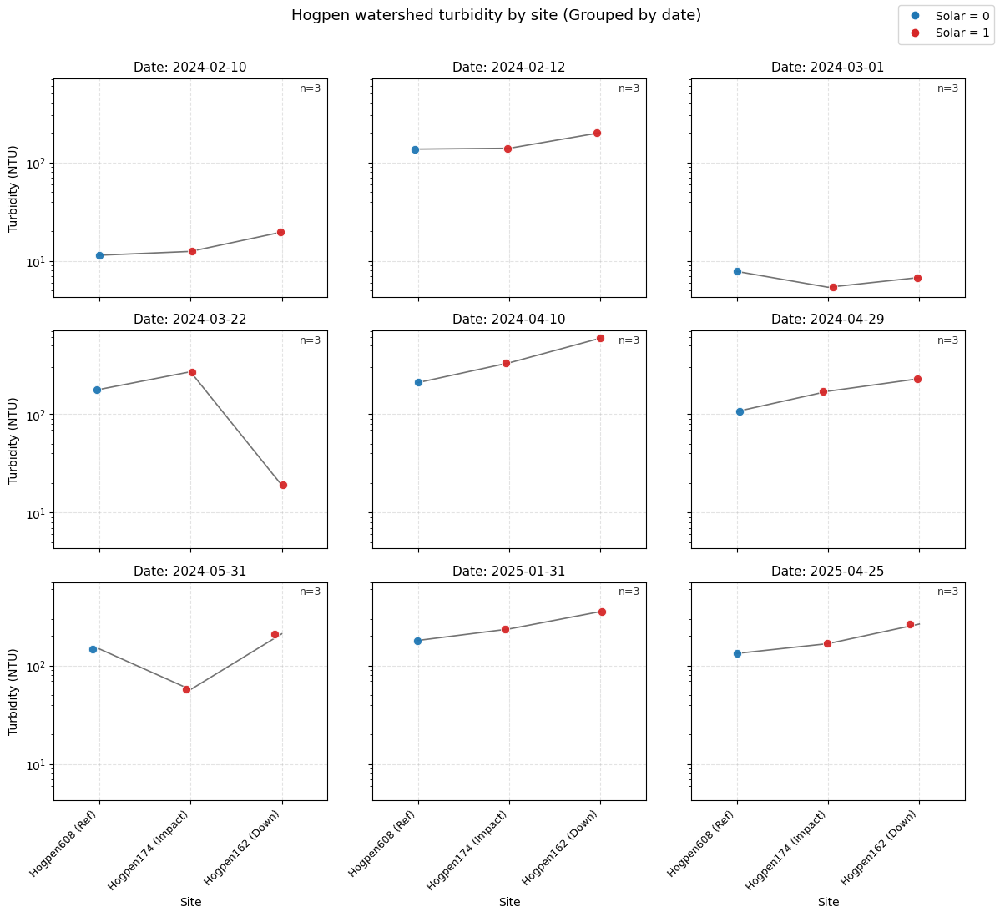

Saved: mart/hog_faceted_turbidity.png


In [32]:
"""
Hogpen watershed – publication-clean faceted turbidity plot (by Date, Site order = ref→impact→downstream)

Fixes included (per your notes):
1) Battle Lake (and any low values) no longer get clipped:
   - y-limits use true min/max (with buffer) instead of percentiles.
2) X-axis site labels show under the bottommost plot in EACH column
   (not only the very last row), so the right column gets labels too.

Inputs expected columns:
  Date, Site, Turbidity, Solar
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# USER SETTINGS
# ============================================================

DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

# Optional: dates to remove (any parseable format)
DATES_TO_DROP = ["2/15/2024"]   # [] to drop none

# Hydrologic order (upstream -> reference -> impact -> downstream)
SITE_ORDER = [
    "Hogpen @ LCR 608",   # Upstream
    "Hogpen @ 174",           # Impact
    "Hogpen @ 162",           # Downstream
]

# Short labels (optional)
USE_SHORT_LABELS = True
LABEL_MAP = {
    "Hogpen @ LCR 608": "Hogpen608 (Ref)",
    "Hogpen @ 174": "Hogpen174 (Impact)",
    "Hogpen @ 162": "Hogpen162 (Down)",
}

# Plot behavior
LOGY          = True       # turbidity often looks best on log scale
CONNECT_SITES = True       # connect sites using median per date
NCOLS         = 3
FIGSIZE       = (12, 11)
TITLE         = "Hogpen watershed turbidity by site (Grouped by date)"

# If LOGY=True, zeros/negatives cannot be plotted. Choose one:
DROP_NONPOSITIVE_FOR_LOG = True   # recommended

# Save output (optional)
SAVE_FIG = True
OUT_PNG  = "mart/hog_faceted_turbidity.png"
DPI      = 600


# ============================================================
# PLOT FUNCTION
# ============================================================

def plot_big_facets(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Hogpen watershed turbidity by site (Grouped by date)",
    drop_nonpositive_for_log=True,
):
    d = df.copy()

    # ---- Parse Date ----
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    # ---- Numeric y ----
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # ---- Log-scale cannot show <= 0 ----
    if logy and drop_nonpositive_for_log:
        d = d[d[y_col] > 0].copy()

    # ---- Drop specific dates ----
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    # ---- Site order ----
    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    # Keep only those sites (prevents unexpected extras)
    d = d[d[site_col].isin(site_order)].copy()

    if len(d) == 0:
        raise ValueError(
            "No rows left after filtering. Check SITE_ORDER matches df[Site] exactly, "
            "and your DATES_TO_DROP / log filtering."
        )

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    # ---- Dates to facet ----
    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    # ---- Layout ----
    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    # ---- Colors ----
    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)  # deterministic jitter

    # ---- Y-limits (FIXED: use true min/max so low values don’t disappear) ----
    y = d[y_col].values
    y_pos = y[np.isfinite(y) & (y > 0)]
    if len(y_pos) == 0:
        y_min, y_max = 0.1, 10
    else:
        y_min = max(y_pos.min() * 0.8, 0.1)
        y_max = y_pos.max() * 1.2

    # ---- X tick labels ----
    if label_map:
        xtick_labels = [label_map.get(s, s) for s in site_order]
    else:
        xtick_labels = site_order

    # ---- Panels ----
    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        # Scatter by Solar category
        for solar_val in sorted(sub[solar_col].dropna().unique()):
            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))  # small jitter
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(int(solar_val), "gray"),
                zorder=3
            )

        # Optional connecting line (median across duplicates)
        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(
                np.arange(len(site_order)), med.values,
                linewidth=1.2, alpha=0.55, color="black", zorder=2
            )

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")
            ax.set_ylim(y_min, y_max)
        else:
            ax.set_ylim(0, y_max)

        # ---- X labels on bottommost plot in EACH column (FIXED) ----
        is_last_in_column = (i + ncols >= n)  # no subplot below in same column
        ax.set_xticks(np.arange(len(site_order)))

        if is_last_in_column:
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")

        # Y label only on left column (keeps it clean)
        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        # panel sample size
        ax.text(
            0.98, 0.98, f"n={len(sub)}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9, alpha=0.8
        )

    # Turn off unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # Legend
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================

label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_big_facets(
    hog_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpositive_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")

In [34]:
### Plot Turbidity for Hogpen original values

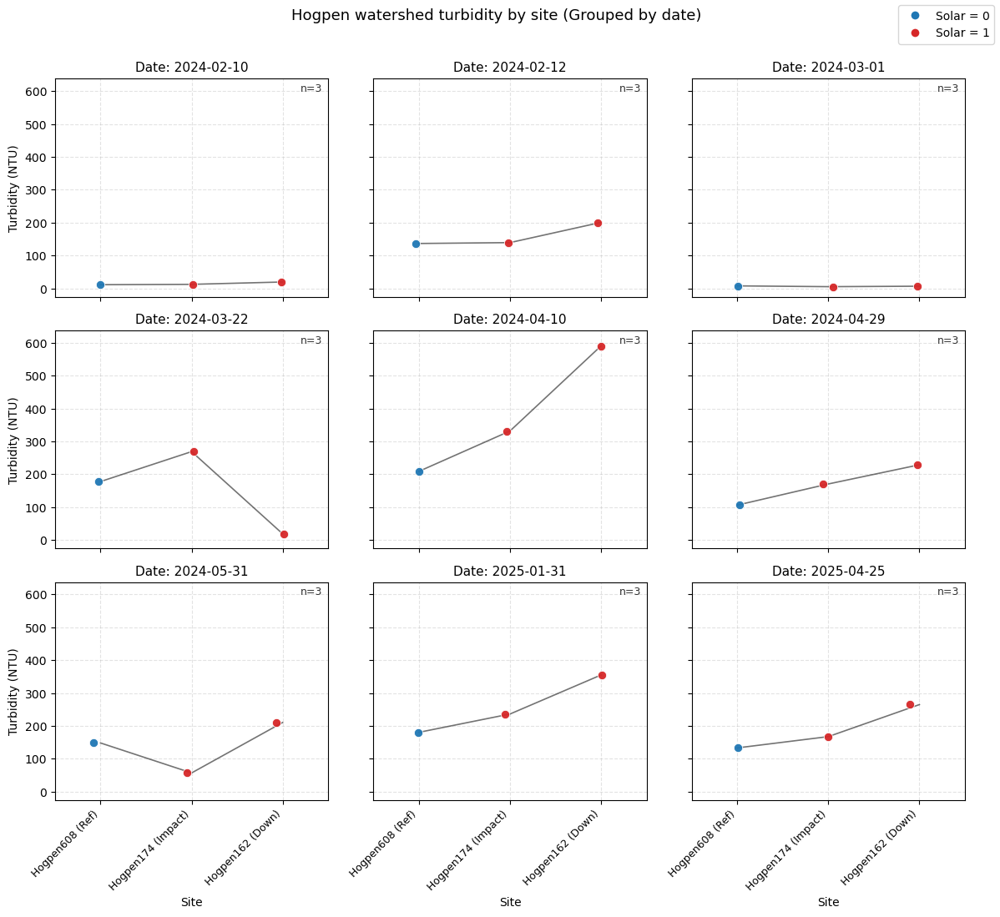

Saved: mart/hog_faceted_turbidity_LINEAR.png


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# USER SETTINGS
# ============================================================
DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

DATES_TO_DROP = ["2/15/2024"]   # [] to drop none

SITE_ORDER = [
    "Hogpen @ LCR 608",   # Ref/Upstream (your labeling)
    "Hogpen @ 174",       # Impact
    "Hogpen @ 162",       # Downstream
]

LOGY          = False      # linear
CONNECT_SITES = True
NCOLS         = 3
FIGSIZE       = (12, 11)

DROP_NONPOSITIVE_FOR_LOG = True  # only used if LOGY=True

USE_SHORT_LABELS = True
LABEL_MAP = {
    "Hogpen @ LCR 608": "Hogpen608 (Ref)",
    "Hogpen @ 174": "Hogpen174 (Impact)",
    "Hogpen @ 162": "Hogpen162 (Down)",
}

TITLE = "Hogpen watershed turbidity by site (Grouped by date)"

SAVE_FIG = True
OUT_PNG  = "mart/hog_faceted_turbidity_LINEAR.png"
DPI      = 600


# ============================================================
# FUNCTION
# ============================================================
def plot_facets_simple(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Watershed turbidity by site (Grouped by date)",
    drop_nonpos_for_log=True,
):
    d = df.copy()

    # Parse Date
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    # Numeric y
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # Drop <=0 only if log scale
    if logy and drop_nonpos_for_log:
        d = d[d[y_col] > 0].copy()

    # Drop specific dates
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    # Site order
    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    d = d[d[site_col].isin(site_order)].copy()
    if len(d) == 0:
        raise ValueError("No rows left after filtering. Check SITE_ORDER and filters.")

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    # Dates
    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    # Layout
    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    # Styling
    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)

    # Y limits
    y = d[y_col].values
    y_finite = y[np.isfinite(y)]
    if len(y_finite) == 0:
        y_min, y_max = 0, 10
    else:
        if logy:
            y_pos = y_finite[y_finite > 0]
            y_min = max(y_pos.min() * 0.8, 0.1) if len(y_pos) else 0.1
            y_max = y_pos.max() * 1.2 if len(y_pos) else 10
        else:
            y_max = y_finite.max() * 1.08
            pad = 0.04 * y_max
            y_min = -pad

    # X tick labels
    xtick_labels = [label_map.get(s, s) for s in site_order] if label_map else site_order

    # Panels
    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        # Scatter by Solar category (ROBUST solar casting)
        for solar_val in sorted(sub[solar_col].dropna().unique()):
            try:
                solar_key = int(float(solar_val))
            except Exception:
                solar_key = None

            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(solar_key, "gray"),
                zorder=3
            )

        # Optional connecting line
        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(
                np.arange(len(site_order)), med.values,
                linewidth=1.2, alpha=0.55, color="black", zorder=2
            )

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")
        ax.set_ylim(y_min, y_max)

        # x labels only bottom row
        if i // ncols == nrows - 1:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels([])
            ax.set_xlabel("")

        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        ax.text(0.98, 0.98, f"n={len(sub)}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, alpha=0.8)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================
label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_facets_simple(
    hog_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpos_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")

In [38]:
hog_filt[hog_filt['Date'] == '4/10/2024']

,Date,Site,Turbidity,Solar


In [37]:
hog_filt['Turbidity'].min()

np.float64(5.393)

In [51]:
### Plot Hogpen rain and psi, first plot 2025 and second is 2024, with summary table for the year


SUMMARY TABLES (2025)

--- Rain distribution (Daily MAX of Event Rain, inches) ---
Daily max event rain (in)  Days  Percent
                   0–0.01    94     71.2
                0.01–0.10     8      6.1
                0.10–0.25     5      3.8
                0.25–0.50    10      7.6
                 0.50–1.0     6      4.5
                  1.0–2.0     5      3.8
                     2.0+     4      3.0

--- Rain summary ---
Days in period: 132
Days with rain > 0: 38
Mean:   0.204
Median: 0.000
P90:    0.700
P95:    1.490
Max:    2.560
Sum of daily max: 26.940

--- Water pressure stats (psi) ---
    n    min    p05    p25  median   mean    p75    p95    max   std
15071 14.218 14.355 14.454  14.508 14.589 14.591 14.981 19.398 0.413


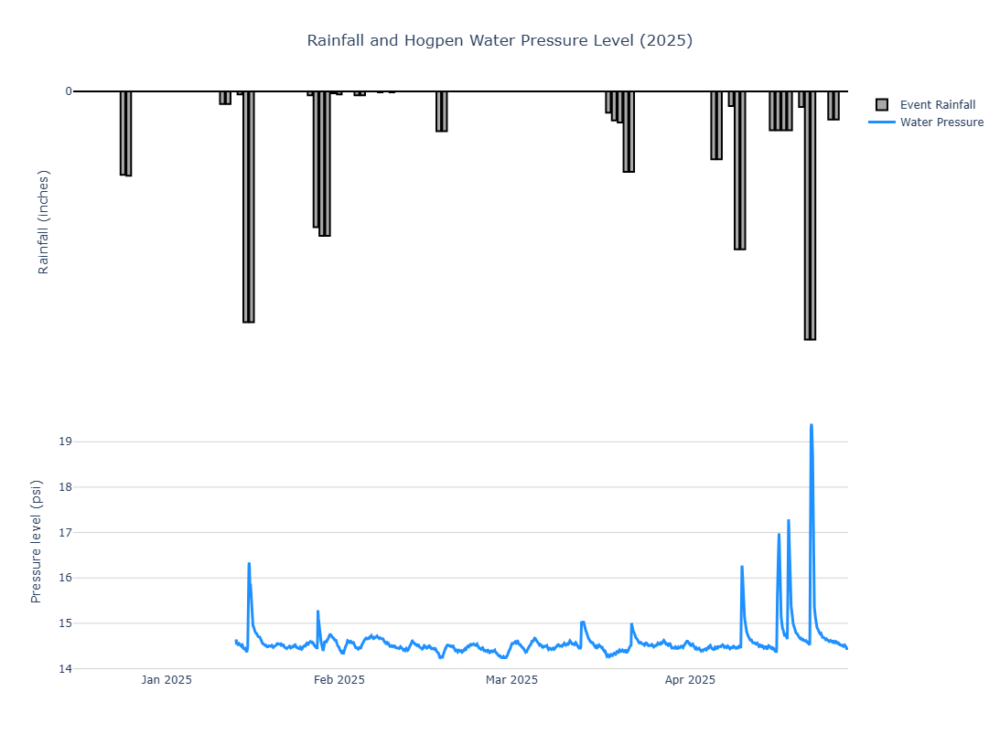

In [53]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Hogpen174_2.15.24__7.15.24__OttoSolar_21839231.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Hogpen174_1.28.25_5.16.25_21839231.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/otto_results/new_weather.csv"                 # 02/09/2024–05/12/2025

# Focus year
YEAR_FOCUS = 2025

# Pressure line: break if gap > N hours (prevents fake line across missing months)
GAP_HOURS = 24

# Rain distribution bins (inches) for summary
RAIN_BINS = [0, 0.01, 0.10, 0.25, 0.50, 1.0, 2.0, np.inf]
RAIN_BIN_LABELS = ["0–0.01", "0.01–0.10", "0.10–0.25", "0.25–0.50", "0.50–1.0", "1.0–2.0", "2.0+"]


# ============================================================
# PRESSURE READER (ROBUST FOR YOUR EXPORT FORMAT)
# ============================================================
PRESSURE_DT_COL = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

def read_pressure_csv_hobo(filepath: str) -> pd.DataFrame:
    """
    Finds the header row (line containing Date Time, GMT-06:00 and Abs Pres, psi...)
    then reads from there and keeps only DateTime + pressure.
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if (PRESSURE_DT_COL in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header row in {filepath} containing '{PRESSURE_DT_COL}'")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Some exports have a leading index column '#'
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    # Ensure the exact columns exist (use substring fallback if needed)
    if PRESSURE_DT_COL not in df.columns:
        dt_col = next((c for c in df.columns if "Date Time" in str(c)), None)
    else:
        dt_col = PRESSURE_DT_COL

    if PRESSURE_PSI_COL not in df.columns:
        psi_col = next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)
    else:
        psi_col = PRESSURE_PSI_COL

    if dt_col is None or psi_col is None:
        raise ValueError(f"Could not locate DateTime/Pressure columns in {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, psi_col]].copy()
    out.columns = ["DateTime", "pressure_psi"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure_psi"] = pd.to_numeric(out["pressure_psi"], errors="coerce")

    out = out.dropna(subset=["DateTime", "pressure_psi"]).sort_values("DateTime").reset_index(drop=True)
    return out


def break_pressure_line_on_gaps(df: pd.DataFrame, gap_hours: float) -> pd.DataFrame:
    """
    Inserts NaNs where the time gap exceeds gap_hours so Plotly breaks the line.
    """
    d = df.sort_values("DateTime").copy()
    gaps = d["DateTime"].diff().dt.total_seconds() / 3600.0
    d.loc[gaps > gap_hours, "pressure_psi"] = np.nan
    return d


# ============================================================
# RAIN READER (YOUR COLUMN NAMES)
# ============================================================
RAIN_DATE_COL = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

def read_rain_daily_max(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")

    if RAIN_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(f"Rain CSV missing expected columns. Found: {list(rain.columns)}")

    r = rain[[RAIN_DATE_COL, RAIN_EVENT_COL]].copy()
    r["Date"] = pd.to_datetime(r[RAIN_DATE_COL], errors="coerce").dt.normalize()
    r["EventRain_in"] = pd.to_numeric(r[RAIN_EVENT_COL], errors="coerce")

    r = r.dropna(subset=["Date", "EventRain_in"])

    daily = (
        r.groupby("Date", as_index=False)["EventRain_in"]
         .max()
         .rename(columns={"EventRain_in": "DailyMaxEventRain_in"})
         .sort_values("Date")
         .reset_index(drop=True)
    )
    return daily


# ============================================================
# LOAD + FILTER TO YEAR
# ============================================================
p1 = read_pressure_csv_hobo(PRESSURE_CSV_1)
p2 = read_pressure_csv_hobo(PRESSURE_CSV_2)
pressure = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_daily_max(RAIN_CSV)

start = pd.Timestamp(f"{YEAR_FOCUS}-01-01")
end   = pd.Timestamp(f"{YEAR_FOCUS}-12-31")

pressure_y = pressure[(pressure["DateTime"] >= start) & (pressure["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_y = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# Trim pressure to end at last rainfall day in the year (if rain exists)
if len(rain_y) > 0:
    rain_end = rain_y["Date"].max()
    pressure_y = pressure_y[pressure_y["DateTime"] <= (rain_end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()

# Break pressure line across gaps
pressure_y = break_pressure_line_on_gaps(pressure_y, GAP_HOURS)

# Make rain bars downward (negative)
rain_y["RainDown"] = rain_y["DailyMaxEventRain_in"]

# Build rain axis ticks (positive labels)
rain_max = float(rain_y["DailyMaxEventRain_in"].max()) if len(rain_y) else 1.0
tick_step = 0.5 if rain_max <= 3 else 1.0
ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
ticks_neg = -ticks_pos


# ============================================================
# SUMMARY TABLES (PRINT)
# ============================================================
print("\n============================")
print(f"SUMMARY TABLES ({YEAR_FOCUS})")
print("============================")

# Rain distribution
if len(rain_y) == 0:
    print("\nRain: No records found.")
else:
    rvals = rain_y["DailyMaxEventRain_in"]
    bins = pd.cut(rvals, bins=RAIN_BINS, labels=RAIN_BIN_LABELS, include_lowest=True, right=False)

    rain_dist = (
        bins.value_counts()
            .rename_axis("Daily max event rain (in)")
            .reset_index(name="Days")
            .sort_values("Daily max event rain (in)")
    )
    rain_dist["Percent"] = (rain_dist["Days"] / rain_dist["Days"].sum() * 100).round(1)

    print("\n--- Rain distribution (Daily MAX of Event Rain, inches) ---")
    print(rain_dist.to_string(index=False))

    print("\n--- Rain summary ---")
    print(f"Days in period: {len(rvals)}")
    print(f"Days with rain > 0: {(rvals > 0).sum()}")
    print(f"Mean:   {rvals.mean():.3f}")
    print(f"Median: {rvals.median():.3f}")
    print(f"P90:    {rvals.quantile(0.90):.3f}")
    print(f"P95:    {rvals.quantile(0.95):.3f}")
    print(f"Max:    {rvals.max():.3f}")
    print(f"Sum of daily max: {rvals.sum():.3f}")

# Pressure stats
pvals = pressure_y["pressure_psi"].dropna()
if len(pvals) == 0:
    print("\nPressure: No records found.")
else:
    stats = pd.DataFrame([{
        "n": len(pvals),
        "min": pvals.min(),
        "p05": pvals.quantile(0.05),
        "p25": pvals.quantile(0.25),
        "median": pvals.median(),
        "mean": pvals.mean(),
        "p75": pvals.quantile(0.75),
        "p95": pvals.quantile(0.95),
        "max": pvals.max(),
        "std": pvals.std(),
    }]).round(3)

    print("\n--- Water pressure stats (psi) ---")
    print(stats.to_string(index=False))


# ============================================================
# PLOTLY FIGURE (MATCH YOUR FORMAT)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.10,
    row_heights=[0.5, 0.5]
)

# Rain bars (down)
fig.add_trace(go.Bar(
    x=rain_y["Date"],
    y=rain_y["RainDown"],  # negative => down
    name="Event Rainfall",
    marker=dict(color="darkgray", line=dict(color="black", width=2)),
    hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
    customdata=rain_y["DailyMaxEventRain_in"],
), row=1, col=1)

# Pressure line
fig.add_trace(go.Scatter(
    x=pressure_y["DateTime"],
    y=pressure_y["pressure_psi"],
    name="Water Pressure",
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    showlegend=True
), row=2, col=1)

# Layout
fig.update_layout(
    title=f"Rainfall and Hogpen Water Pressure Level ({YEAR_FOCUS})",
    xaxis_title="",
    height=800,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    title_x=0.5,
)

# Rain axis: reversed so bars hang down; labels show positive
fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    autorange="reversed",
    tickvals=ticks_neg,
    ticktext=[f"{t:g}" for t in ticks_pos],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black",
)

# Pressure axis
fig.update_yaxes(
    title_text="Pressure level (psi)",
    row=2, col=1,
    showgrid=True,
    gridcolor="lightgray",
)

# X axis: monthly ticks (prevents duplicate Jan 2025)
fig.update_xaxes(
    row=2, col=1,
    dtick="M1",
    tickformat="%b %Y",
    ticklabelmode="period"
)

fig.show()


SUMMARY TABLES (2024)

--- Rain distribution (Daily MAX of Event Rain, inches) ---
Daily max event rain (in)  Days  Percent
                   0–0.01   108     68.4
                0.01–0.10     8      5.1
                0.10–0.25     3      1.9
                0.25–0.50     1      0.6
                 0.50–1.0    13      8.2
                  1.0–2.0    13      8.2
                     2.0+    12      7.6

--- Rain summary ---
Days in period: 158
Days with rain > 0: 50
Mean:   0.459
Median: 0.000
P90:    1.703
P95:    3.135
Max:    5.080
Sum of daily max: 72.460

--- Water pressure stats (psi) ---
    n    min    p05    p25  median   mean    p75    p95    max   std
21692 14.285 14.388 14.448  14.514 14.777 14.633 16.358 20.083 0.909


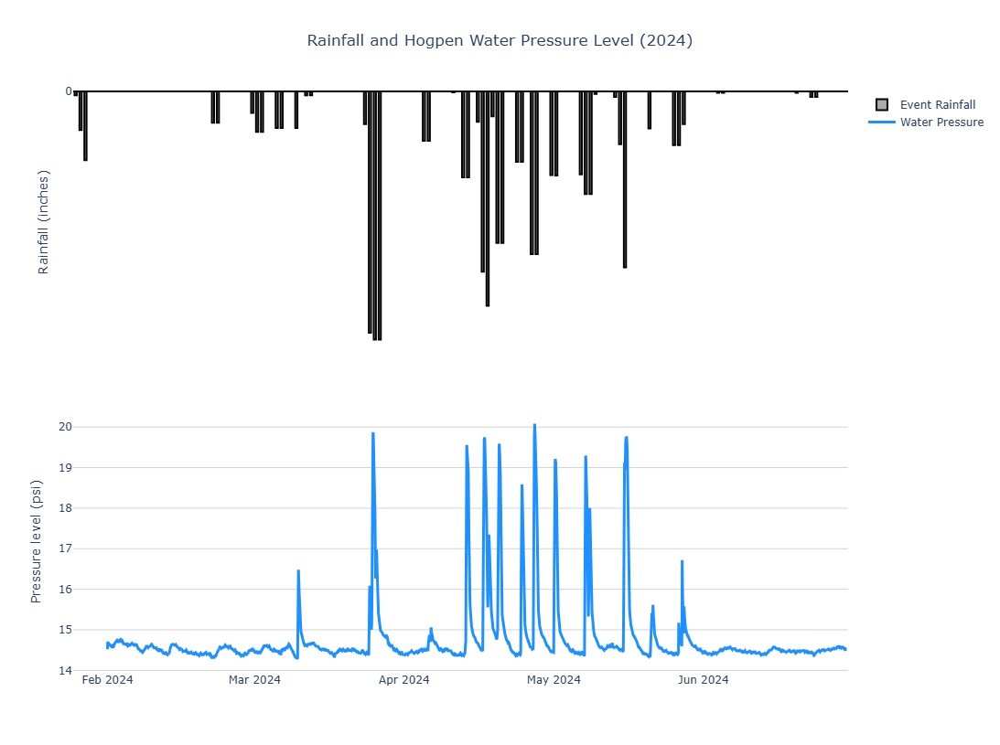

In [55]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Hogpen174_2.15.24__7.15.24__OttoSolar_21839231.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Hogpen174_1.28.25_5.16.25_21839231.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/otto_results/new_weather.csv"                 # 02/09/2024–05/12/2025

# Focus year
YEAR_FOCUS = 2024

# Pressure line: break if gap > N hours (prevents fake line across missing months)
GAP_HOURS = 24

# Rain distribution bins (inches) for summary
RAIN_BINS = [0, 0.01, 0.10, 0.25, 0.50, 1.0, 2.0, np.inf]
RAIN_BIN_LABELS = ["0–0.01", "0.01–0.10", "0.10–0.25", "0.25–0.50", "0.50–1.0", "1.0–2.0", "2.0+"]


# ============================================================
# PRESSURE READER (ROBUST FOR YOUR EXPORT FORMAT)
# ============================================================
PRESSURE_DT_COL = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

def read_pressure_csv_hobo(filepath: str) -> pd.DataFrame:
    """
    Finds the header row (line containing Date Time, GMT-06:00 and Abs Pres, psi...)
    then reads from there and keeps only DateTime + pressure.
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if (PRESSURE_DT_COL in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header row in {filepath} containing '{PRESSURE_DT_COL}'")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Some exports have a leading index column '#'
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    # Ensure the exact columns exist (use substring fallback if needed)
    if PRESSURE_DT_COL not in df.columns:
        dt_col = next((c for c in df.columns if "Date Time" in str(c)), None)
    else:
        dt_col = PRESSURE_DT_COL

    if PRESSURE_PSI_COL not in df.columns:
        psi_col = next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)
    else:
        psi_col = PRESSURE_PSI_COL

    if dt_col is None or psi_col is None:
        raise ValueError(f"Could not locate DateTime/Pressure columns in {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, psi_col]].copy()
    out.columns = ["DateTime", "pressure_psi"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure_psi"] = pd.to_numeric(out["pressure_psi"], errors="coerce")

    out = out.dropna(subset=["DateTime", "pressure_psi"]).sort_values("DateTime").reset_index(drop=True)
    return out


def break_pressure_line_on_gaps(df: pd.DataFrame, gap_hours: float) -> pd.DataFrame:
    """
    Inserts NaNs where the time gap exceeds gap_hours so Plotly breaks the line.
    """
    d = df.sort_values("DateTime").copy()
    gaps = d["DateTime"].diff().dt.total_seconds() / 3600.0
    d.loc[gaps > gap_hours, "pressure_psi"] = np.nan
    return d


# ============================================================
# RAIN READER (YOUR COLUMN NAMES)
# ============================================================
RAIN_DATE_COL = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

def read_rain_daily_max(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")

    if RAIN_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(f"Rain CSV missing expected columns. Found: {list(rain.columns)}")

    r = rain[[RAIN_DATE_COL, RAIN_EVENT_COL]].copy()
    r["Date"] = pd.to_datetime(r[RAIN_DATE_COL], errors="coerce").dt.normalize()
    r["EventRain_in"] = pd.to_numeric(r[RAIN_EVENT_COL], errors="coerce")

    r = r.dropna(subset=["Date", "EventRain_in"])

    daily = (
        r.groupby("Date", as_index=False)["EventRain_in"]
         .max()
         .rename(columns={"EventRain_in": "DailyMaxEventRain_in"})
         .sort_values("Date")
         .reset_index(drop=True)
    )
    return daily


# ============================================================
# LOAD + FILTER TO YEAR
# ============================================================
p1 = read_pressure_csv_hobo(PRESSURE_CSV_1)
p2 = read_pressure_csv_hobo(PRESSURE_CSV_2)
pressure_df = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_daily_max(RAIN_CSV)

start = pd.Timestamp(f"{YEAR_FOCUS}-01-01")
end   = pd.Timestamp(f"{YEAR_FOCUS}-12-31")


# ============================================================
# FILTER TO YEAR_FOCUS (FIX)
# ============================================================
pressure_y = pressure_df[(pressure_df["DateTime"] >= start) & (pressure_df["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_daily  = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# ============================================================
# ALIGN END DATES: stop rainfall where PSI ends (for this year)
# ============================================================
if len(pressure_df) == 0:
    raise ValueError("No pressure data found in the selected YEAR_FOCUS window.")

psi_end_day = pressure_y["DateTime"].max().normalize()
rain_y = rain_daily[rain_daily["Date"] <= psi_end_day].copy()
#=================================================================
#==================================================================

# Trim pressure to end at last rainfall day in the year (if rain exists)
if len(rain_y) > 0:
    rain_end = rain_y["Date"].max()
    pressure_y = pressure_y[pressure_y["DateTime"] <= (rain_end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()

# Break pressure line across gaps
pressure_y = break_pressure_line_on_gaps(pressure_y, GAP_HOURS)

# Make rain bars downward (negative)
rain_y["RainDown"] = rain_y["DailyMaxEventRain_in"]

# Build rain axis ticks (positive labels)
rain_max = float(rain_y["DailyMaxEventRain_in"].max()) if len(rain_y) else 1.0
tick_step = 0.5 if rain_max <= 3 else 1.0
ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
ticks_neg = -ticks_pos


# ============================================================
# SUMMARY TABLES (PRINT)
# ============================================================
print("\n============================")
print(f"SUMMARY TABLES ({YEAR_FOCUS})")
print("============================")

# Rain distribution
if len(rain_y) == 0:
    print("\nRain: No records found.")
else:
    rvals = rain_y["DailyMaxEventRain_in"]
    bins = pd.cut(rvals, bins=RAIN_BINS, labels=RAIN_BIN_LABELS, include_lowest=True, right=False)

    rain_dist = (
        bins.value_counts()
            .rename_axis("Daily max event rain (in)")
            .reset_index(name="Days")
            .sort_values("Daily max event rain (in)")
    )
    rain_dist["Percent"] = (rain_dist["Days"] / rain_dist["Days"].sum() * 100).round(1)

    print("\n--- Rain distribution (Daily MAX of Event Rain, inches) ---")
    print(rain_dist.to_string(index=False))

    print("\n--- Rain summary ---")
    print(f"Days in period: {len(rvals)}")
    print(f"Days with rain > 0: {(rvals > 0).sum()}")
    print(f"Mean:   {rvals.mean():.3f}")
    print(f"Median: {rvals.median():.3f}")
    print(f"P90:    {rvals.quantile(0.90):.3f}")
    print(f"P95:    {rvals.quantile(0.95):.3f}")
    print(f"Max:    {rvals.max():.3f}")
    print(f"Sum of daily max: {rvals.sum():.3f}")

# Pressure stats
pvals = pressure_y["pressure_psi"].dropna()
if len(pvals) == 0:
    print("\nPressure: No records found.")
else:
    stats = pd.DataFrame([{
        "n": len(pvals),
        "min": pvals.min(),
        "p05": pvals.quantile(0.05),
        "p25": pvals.quantile(0.25),
        "median": pvals.median(),
        "mean": pvals.mean(),
        "p75": pvals.quantile(0.75),
        "p95": pvals.quantile(0.95),
        "max": pvals.max(),
        "std": pvals.std(),
    }]).round(3)

    print("\n--- Water pressure stats (psi) ---")
    print(stats.to_string(index=False))


# ============================================================
# PLOTLY FIGURE (MATCH YOUR FORMAT)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.10,
    row_heights=[0.5, 0.5]
)

# Rain bars (down)
fig.add_trace(go.Bar(
    x=rain_y["Date"],
    y=rain_y["RainDown"],  # negative => down
    name="Event Rainfall",
    marker=dict(color="darkgray", line=dict(color="black", width=2)),
    hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
    customdata=rain_y["DailyMaxEventRain_in"],
), row=1, col=1)

# Pressure line
fig.add_trace(go.Scatter(
    x=pressure_y["DateTime"],
    y=pressure_y["pressure_psi"],
    name="Water Pressure",
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    showlegend=True
), row=2, col=1)

# Layout
fig.update_layout(
    title=f"Rainfall and Hogpen Water Pressure Level ({YEAR_FOCUS})",
    xaxis_title="",
    height=800,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    title_x=0.5,
)

# Rain axis: reversed so bars hang down; labels show positive
fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    autorange="reversed",
    tickvals=ticks_neg,
    ticktext=[f"{t:g}" for t in ticks_pos],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black",
)

# Pressure axis
fig.update_yaxes(
    title_text="Pressure level (psi)",
    row=2, col=1,
    showgrid=True,
    gridcolor="lightgray",
)

# X axis: monthly ticks (prevents duplicate Jan 2025)
fig.update_xaxes(
    row=2, col=1,
    dtick="M1",
    tickformat="%b %Y",
    ticklabelmode="period"
)
fig.update_layout(bargap=0.55)  # bigger gap => bars look thinner

fig.show()

In [56]:
### Brushy Analysis

In [33]:
brushy_ntu = mart_ntu.loc[
    mart_ntu["Creek"].astype(str).str.contains("brushy", case=False, na=False),
    ["Date", "Site", "Solar", "Avg Turbidity NTU"]
]
print(brushy_ntu.shape)
brushy_ntu.head()

(48, 4)


,Date,Site,Solar,Avg Turbidity NTU
0,2024-01-23,Brushy @ 118,0.0,330.50
1,2024-01-23,Brushy @ 152,1.0,846.50
4,2024-01-24,Brushy @ 118,0.0,245.50
5,2024-01-24,Brushy @ 152,1.0,333.00
6,2024-01-24,Little Brushy @ 118,0.0,96.55


In [34]:
brushy_ntu = brushy_ntu.rename(columns={'Avg Turbidity NTU': 'Turbidity'})
print(brushy_ntu.value_counts('Site'))
brushy_ntu.info()

Site
Brushy @ 118           11
Brushy @ 152           10
Little Brushy @ 118    10
Little Brushy @ 150     9
Brushy @ 1240           8
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 48 entries, 0 to 128
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       48 non-null     str    
 1   Site       48 non-null     str    
 2   Solar      48 non-null     float64
 3   Turbidity  48 non-null     float64
dtypes: float64(2), str(2)
memory usage: 1.9 KB


In [35]:
brushy_ntu.value_counts('Date')

Date
2024-02-10    5
2024-02-12    5
2024-03-01    5
2024-04-10    5
2024-04-29    5
2024-05-31    5
2025-01-31    5
2024-01-24    4
2025-04-25    4
2024-01-23    2
2024-04-09    2
2024-02-15    1
Name: count, dtype: int64

In [36]:
brushy_ntu[brushy_ntu['Date'] == '2024-02-15']

,Date,Site,Solar,Turbidity
36,2024-02-15,Brushy @ 1240,1.0,35.467


In [37]:
# Step 3: Aggregate values for duplicate sites within each valid date
brushy_aggregated = (
    brushy_ntu
    .groupby(['Date', 'Site'], as_index=False)
    .agg({'Turbidity': 'mean', 'Solar': 'mean'})  # Aggregate 'value' column by mean
)

print(brushy_aggregated.shape)
brushy_aggregated.head()

(48, 4)


,Date,Site,Turbidity,Solar
0,2024-01-23,Brushy @ 118,330.50,0.0
1,2024-01-23,Brushy @ 152,846.50,1.0
2,2024-01-24,Brushy @ 118,245.50,0.0
3,2024-01-24,Brushy @ 152,333.00,1.0
4,2024-01-24,Little Brushy @ 118,96.55,0.0


In [38]:
brushy_aggregated.value_counts('Date')

Date
2024-02-10    5
2024-02-12    5
2024-03-01    5
2024-04-10    5
2024-04-29    5
2024-05-31    5
2025-01-31    5
2024-01-24    4
2025-04-25    4
2024-01-23    2
2024-04-09    2
2024-02-15    1
Name: count, dtype: int64

In [39]:
brushy_aggregated.loc[brushy_aggregated["Site"] == "Little Brushy @ 150"]

,Date,Site,Turbidity,Solar
5,2024-01-24,Little Brushy @ 150,128.500,0.0
10,2024-02-10,Little Brushy @ 150,31.333,0.0
15,2024-02-12,Little Brushy @ 150,88.767,0.0
21,2024-03-01,Little Brushy @ 150,3.380,0.0
28,2024-04-10,Little Brushy @ 150,173.000,0.0
33,2024-04-29,Little Brushy @ 150,155.667,0.0
38,2024-05-31,Little Brushy @ 150,103.667,0.0
43,2025-01-31,Little Brushy @ 150,94.900,0.0
47,2025-04-25,Little Brushy @ 150,106.000,0.0


In [40]:
dates_to_drop = ['2024-02-15', '2024-04-09']
brushy_filt = brushy_aggregated[~brushy_aggregated['Date'].isin(dates_to_drop)]
print(brushy_filt.shape)
brushy_filt.head()

(45, 4)


,Date,Site,Turbidity,Solar
0,2024-01-23,Brushy @ 118,330.50,0.0
1,2024-01-23,Brushy @ 152,846.50,1.0
2,2024-01-24,Brushy @ 118,245.50,0.0
3,2024-01-24,Brushy @ 152,333.00,1.0
4,2024-01-24,Little Brushy @ 118,96.55,0.0


In [41]:
print(brushy_filt.value_counts('Site'))
print(brushy_filt.value_counts('Date'))
brushy_filt.info()

Site
Brushy @ 118           10
Brushy @ 152           10
Little Brushy @ 118     9
Little Brushy @ 150     9
Brushy @ 1240           7
Name: count, dtype: int64
Date
2024-02-10    5
2024-02-12    5
2024-03-01    5
2024-04-10    5
2024-04-29    5
2024-05-31    5
2025-01-31    5
2024-01-24    4
2025-04-25    4
2024-01-23    2
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 45 entries, 0 to 47
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       45 non-null     str    
 1   Site       45 non-null     str    
 2   Turbidity  45 non-null     float64
 3   Solar      45 non-null     float64
dtypes: float64(2), str(2)
memory usage: 1.8 KB


In [42]:
brushy_filt['Turbidity'].min()

np.float64(3.38)

In [52]:
### Plot Brushy Turbidity Log10
# Brushy @ 118           9
# Brushy @ 152           9
# Little Brushy @ 118    9
# Little Brushy @ 150    9
# Brushy @ 1240          7

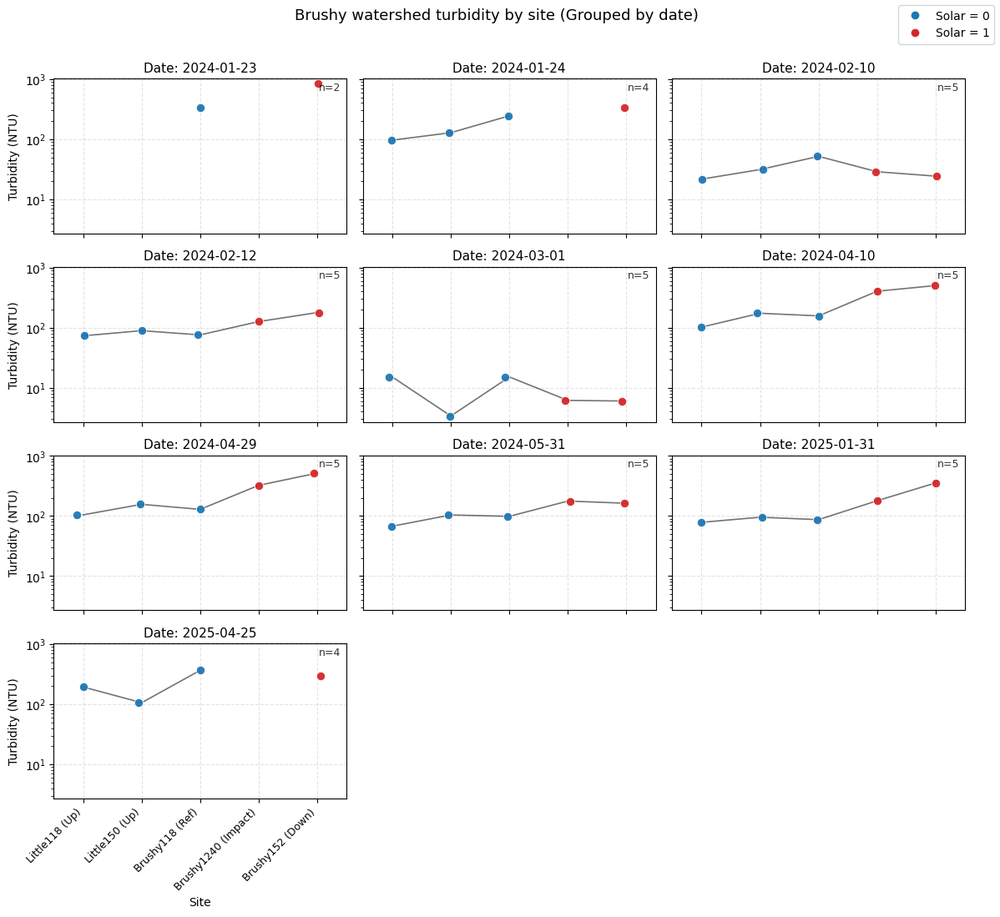

Saved: mart/brushy_faceted_turbidity.png


In [68]:
"""
Brushy watershed – publication-clean faceted turbidity plot (by Date, Site order = upstream→ref→impact→impact→downstream)

Only change made vs your script:
✅ Fix Battle Lake “missing” low values by using TRUE min/max for y-limits (with a small buffer)
   instead of percentile-based limits that can clip low values on log scale.

Everything else is unchanged.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# USER SETTINGS
# ============================================================

DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

# Drop these dates (optional). Use any parseable format.
DATES_TO_DROP = ['2/15/2024', '4/9/2024']   # [] to drop none

# Hydrologic order (upstream -> reference -> impact -> downstream)
SITE_ORDER = [
    "Little Brushy @ 118",   # Upstream
    "Little Brushy @ 150",   # Upstream
    "Brushy @ 118",   # Reference
    "Brushy @ 1240",           # Impact
    "Brushy @ 152",           # Downstream
]

# Plot behavior
LOGY          = True       # turbidity often looks best on log scale
CONNECT_SITES = True       # draw a faint line across sites (median) per date
NCOLS         = 3
FIGSIZE       = (12, 11)

# If LOGY=True, zeros/negatives cannot be plotted. Choose one:
DROP_NONPOSITIVE_FOR_LOG = True   # recommended

# Short labels (optional; keeps internal order by SITE_ORDER)
USE_SHORT_LABELS = True
LABEL_MAP = {
    "Little Brushy @ 118": "Little118 (Up)",
    "Little Brushy @ 150": "Little150 (Up)",
    "Brushy @ 118": "Brushy118 (Ref)",
    "Brushy @ 1240": "Brushy1240 (Impact)",
    "Brushy @ 152": "Brushy152 (Down)",
}

TITLE = "Brushy watershed turbidity by site (Grouped by date)"

# Save output (optional)
SAVE_FIG = True
OUT_PNG  = "mart/brushy_faceted_turbidity.png"
DPI      = 600


# ============================================================
# FUNCTION
# ============================================================

def plot_facets_simple(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Brushy watershed turbidity by site (Grouped by date)",
    drop_nonpositive_for_log=True,
):
    d = df.copy()

    # ---- Parse Date robustly ----
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    # ---- Numeric y ----
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # ---- Drop non-positive for log scale if requested ----
    if logy and drop_nonpositive_for_log:
        d = d[d[y_col] > 0].copy()

    # ---- Drop specific dates ----
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    # ---- Site order ----
    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    # Keep only sites in site_order (prevents random extra sites)
    d = d[d[site_col].isin(site_order)].copy()

    if len(d) == 0:
        raise ValueError(
            "No rows left after filtering. Check SITE_ORDER matches df[Site] exactly, "
            "and your DATES_TO_DROP / log filtering."
        )

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    # ---- Dates to facet ----
    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    # ---- Layout ----
    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    # ---- Styling ----
    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)  # deterministic jitter

    # ---- Consistent y-lims (FIXED: true min/max to avoid clipping low values) ----
    y = d[y_col].values
    y_pos = y[np.isfinite(y) & (y > 0)]
    if len(y_pos) == 0:
        y_min, y_max = 0.1, 10
    else:
        y_min = max(y_pos.min() * 0.8, 0.1)  # <-- FIX: show smallest value (e.g., Battle Lake ~3 NTU)
        y_max = y_pos.max() * 1.2           # <-- FIX: show largest value with a buffer

    # ---- X tick labels ----
    if label_map:
        xtick_labels = [label_map.get(s, s) for s in site_order]
    else:
        xtick_labels = site_order

    # ---- Panels ----
    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        # Scatter by Solar category
        for solar_val in sorted(sub[solar_col].dropna().unique()):
            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))  # small jitter
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(int(solar_val), "gray"),
                zorder=3
            )

        # Optional connecting line (median across duplicates)
        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(
                np.arange(len(site_order)), med.values,
                linewidth=1.2, alpha=0.55, color="black", zorder=2
            )

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")
            ax.set_ylim(y_min, y_max)
        else:
            ax.set_ylim(0, y_max)

        # x labels only bottom row
        if i // ncols == nrows - 1:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels([])
            ax.set_xlabel("")

        # y label only on left column
        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        # panel sample size
        ax.text(
            0.98, 0.98, f"n={len(sub)}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9, alpha=0.8
        )

    # Turn off unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # Legend
    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================

label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_facets_simple(
    brushy_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpositive_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")

In [69]:
### Plot Turbidity original values

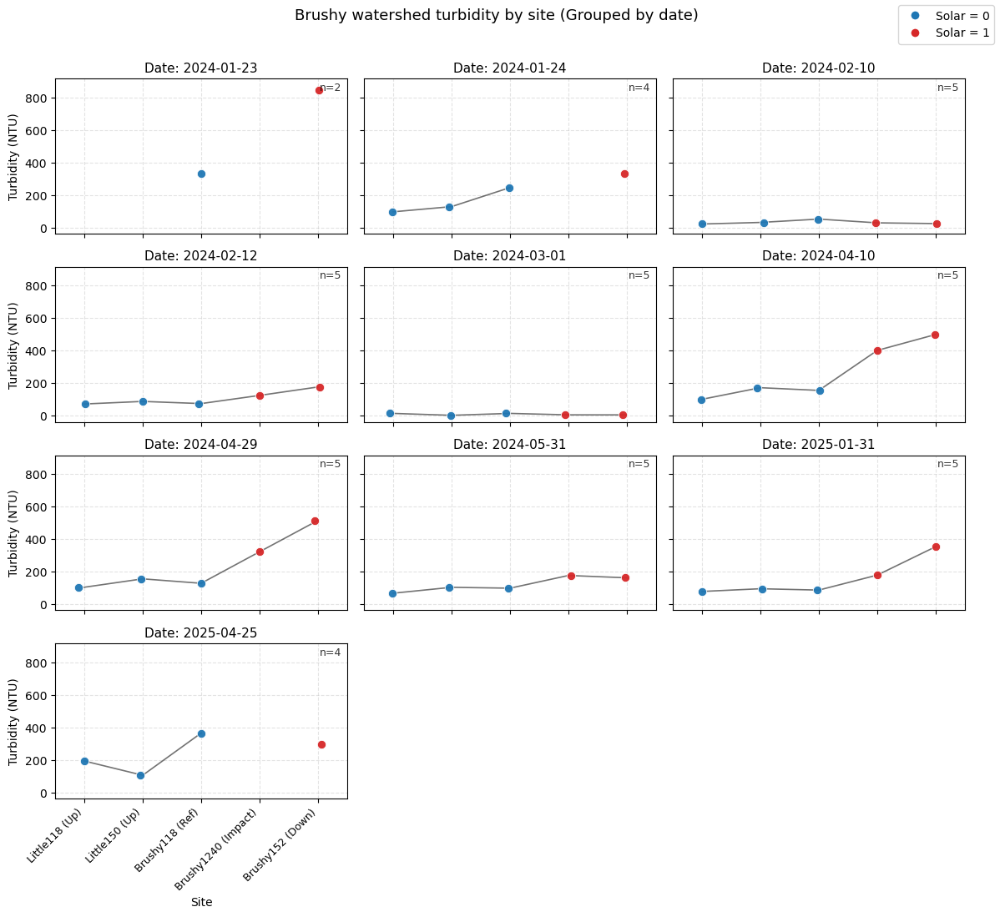

Saved: mart/brushy_faceted_turbidity_LINEAR.png


In [53]:
"""
Same format/layout as your current faceted plot, but with ORIGINAL (linear) turbidity values
(i.e., NOT log scale).

Only differences vs your current script:
- LOGY = False
- y-axis limits use 0 to max*1.2 (so it looks good on linear scale)
Everything else (layout, colors, legend, connecting line, date facets) stays the same.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# USER SETTINGS
# ============================================================

DATE_COL   = "Date"
SITE_COL   = "Site"
Y_COL      = "Turbidity"
SOLAR_COL  = "Solar"

DATES_TO_DROP = ["2/15/2024", "4/9/2024"]   # [] to drop none

SITE_ORDER = [
    "Little Brushy @ 118",   # Upstream
    "Little Brushy @ 150",   # Upstream
    "Brushy @ 118",   # Reference
    "Brushy @ 1240",           # Impact
    "Brushy @ 152",           # Downstream
]

# ---- KEY CHANGE: linear (original values) ----
LOGY          = False      # <-- linear axis
CONNECT_SITES = True
NCOLS         = 3
FIGSIZE       = (12, 11)

# Only relevant for log scale; harmless to keep
DROP_NONPOSITIVE_FOR_LOG = True

USE_SHORT_LABELS = True
LABEL_MAP = {
    "Little Brushy @ 118": "Little118 (Up)",
    "Little Brushy @ 150": "Little150 (Up)",
    "Brushy @ 118": "Brushy118 (Ref)",
    "Brushy @ 1240": "Brushy1240 (Impact)",
    "Brushy @ 152": "Brushy152 (Down)",
}

TITLE = "Brushy watershed turbidity by site (Grouped by date)"

SAVE_FIG = True
OUT_PNG  = "mart/brushy_faceted_turbidity_LINEAR.png"
DPI      = 600


# ============================================================
# FUNCTION
# ============================================================

def plot_facets_simple(
    df,
    dates_to_drop=None,
    date_col="Date",
    site_col="Site",
    y_col="Turbidity",
    solar_col="Solar",
    site_order=None,
    label_map=None,
    logy=True,
    connect_sites=True,
    ncols=3,
    figsize=(12, 11),
    title="Brushy watershed turbidity by site (Grouped by date)",
    drop_nonpos_for_log=True,
):
    d = df.copy()

    # Parse Date
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col])

    # Numeric y
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])

    # Drop <=0 only if log scale
    if logy and drop_nonpos_for_log:
        d = d[d[y_col] > 0].copy()

    # Drop specific dates
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    # Site order
    if site_order is None:
        site_order = sorted(d[site_col].dropna().unique().tolist())

    d = d[d[site_col].isin(site_order)].copy()
    if len(d) == 0:
        raise ValueError("No rows left after filtering. Check SITE_ORDER and filters.")

    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    # Dates
    dates = sorted(d[date_col].dt.normalize().unique())
    if len(dates) == 0:
        raise ValueError("No dates left to plot after filtering.")

    # Layout
    n = len(dates)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)

    # Styling
    color_map = {0: "tab:blue", 1: "tab:red"}
    rng = np.random.default_rng(7)

    # ---- Y limits ----
    y = d[y_col].values
    y_finite = y[np.isfinite(y)]
    if len(y_finite) == 0:
        y_min, y_max = 0, 10
    else:
        if logy:
            y_pos = y_finite[y_finite > 0]
            y_min = max(y_pos.min() * 0.8, 0.1) if len(y_pos) else 0.1
            y_max = y_pos.max() * 1.2 if len(y_pos) else 10
        else:
            y_max = y_finite.max() * 1.08
            pad = 0.04 * y_max          # 3% of the full scale (tweak 0.02–0.06)
            y_min = -pad                # gives breathing room below 0

    # X tick labels
    xtick_labels = [label_map.get(s, s) for s in site_order] if label_map else site_order

    # Panels
    for i, day in enumerate(dates):
        ax = axes[i]
        sub = d[d[date_col].dt.normalize() == day].copy()

        for solar_val in sorted(sub[solar_col].dropna().unique()):
            ss = sub[sub[solar_col] == solar_val]
            xb = ss[site_col].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))
            ax.scatter(
                xx, ss[y_col],
                s=55, alpha=0.95,
                edgecolor="white", linewidth=0.6,
                color=color_map.get(int(solar_val), "gray"),
                zorder=3
            )

        if connect_sites:
            med = sub.groupby(site_col, observed=True)[y_col].median().reindex(site_order)
            ax.plot(np.arange(len(site_order)), med.values,
                    linewidth=1.2, alpha=0.55, color="black", zorder=2)

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)

        if logy:
            ax.set_yscale("log")
        ax.set_ylim(y_min, y_max)

        # x labels only bottom row
        if i // ncols == nrows - 1:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
            ax.set_xlabel("Site")
        else:
            ax.set_xticks(np.arange(len(site_order)))
            ax.set_xticklabels([])
            ax.set_xlabel("")

        if i % ncols == 0:
            ax.set_ylabel("Turbidity (NTU)")

        ax.text(0.98, 0.98, f"n={len(sub)}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, alpha=0.8)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    legend_elements = [
        Line2D([0],[0], marker='o', color='w', label='Solar = 0',
               markerfacecolor=color_map[0], markersize=8),
        Line2D([0],[0], marker='o', color='w', label='Solar = 1',
               markerfacecolor=color_map[1], markersize=8),
    ]
    fig.legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(title, y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])
    return fig


# ============================================================
# RUN
# ============================================================

label_map = LABEL_MAP if USE_SHORT_LABELS else None

fig = plot_facets_simple(
    brushy_aggregated,
    dates_to_drop=DATES_TO_DROP,
    date_col=DATE_COL,
    site_col=SITE_COL,
    y_col=Y_COL,
    solar_col=SOLAR_COL,
    site_order=SITE_ORDER,
    label_map=label_map,
    logy=LOGY,                      # False => linear
    connect_sites=CONNECT_SITES,
    ncols=NCOLS,
    figsize=FIGSIZE,
    title=TITLE,
    drop_nonpos_for_log=DROP_NONPOSITIVE_FOR_LOG
)

plt.show()

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PNG}")

In [71]:
### Plot Rainfall and PSI for Brushy 2025 first and 2024 second


SUMMARY TABLES (2025)

--- Rain distribution (Daily MAX of Event Rain, inches) ---
Daily max event rain (in)  Days  Percent
                   0–0.01    94     71.2
                0.01–0.10     8      6.1
                0.10–0.25     5      3.8
                0.25–0.50    10      7.6
                 0.50–1.0     6      4.5
                  1.0–2.0     5      3.8
                     2.0+     4      3.0

--- Rain summary ---
Days in period: 132
Days with rain > 0: 38
Mean:   0.204
Median: 0.000
P90:    0.700
P95:    1.490
Max:    2.560
Sum of daily max: 26.940

--- Water pressure stats (psi) ---
    n    min    p05   p25  median   mean    p75    p95    max   std
15072 14.218 14.389 14.53   14.68 14.722 14.833 15.109 19.252 0.385


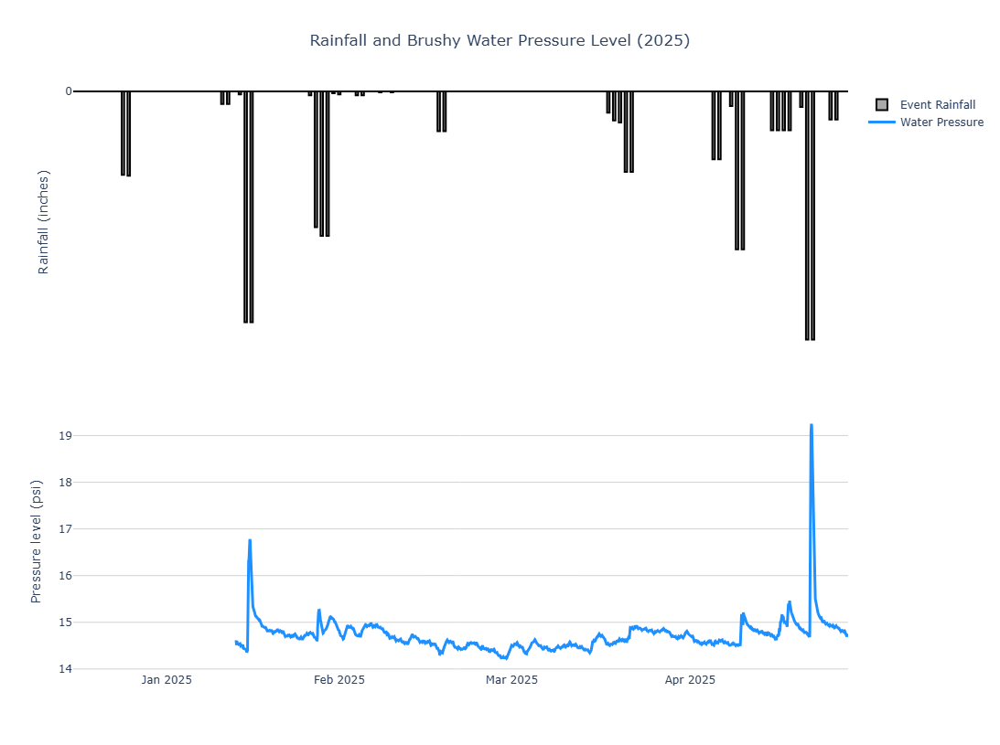

In [73]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Brushy1240_2.15.24__7.15.24__OttoSolar_21839261_0.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Brushy1240_1.28.25_5.16.25_21839261.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/otto_results/new_weather.csv"                 # 02/09/2024–05/12/2025

# Focus year
YEAR_FOCUS = 2025

# Pressure line: break if gap > N hours (prevents fake line across missing months)
GAP_HOURS = 24

# Rain distribution bins (inches) for summary
RAIN_BINS = [0, 0.01, 0.10, 0.25, 0.50, 1.0, 2.0, np.inf]
RAIN_BIN_LABELS = ["0–0.01", "0.01–0.10", "0.10–0.25", "0.25–0.50", "0.50–1.0", "1.0–2.0", "2.0+"]


# ============================================================
# PRESSURE READER (ROBUST FOR YOUR EXPORT FORMAT)
# ============================================================
PRESSURE_DT_COL = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

def read_pressure_csv_hobo(filepath: str) -> pd.DataFrame:
    """
    Finds the header row (line containing Date Time, GMT-06:00 and Abs Pres, psi...)
    then reads from there and keeps only DateTime + pressure.
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if (PRESSURE_DT_COL in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header row in {filepath} containing '{PRESSURE_DT_COL}'")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Some exports have a leading index column '#'
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    # Ensure the exact columns exist (use substring fallback if needed)
    if PRESSURE_DT_COL not in df.columns:
        dt_col = next((c for c in df.columns if "Date Time" in str(c)), None)
    else:
        dt_col = PRESSURE_DT_COL

    if PRESSURE_PSI_COL not in df.columns:
        psi_col = next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)
    else:
        psi_col = PRESSURE_PSI_COL

    if dt_col is None or psi_col is None:
        raise ValueError(f"Could not locate DateTime/Pressure columns in {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, psi_col]].copy()
    out.columns = ["DateTime", "pressure_psi"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure_psi"] = pd.to_numeric(out["pressure_psi"], errors="coerce")

    out = out.dropna(subset=["DateTime", "pressure_psi"]).sort_values("DateTime").reset_index(drop=True)
    return out


def break_pressure_line_on_gaps(df: pd.DataFrame, gap_hours: float) -> pd.DataFrame:
    """
    Inserts NaNs where the time gap exceeds gap_hours so Plotly breaks the line.
    """
    d = df.sort_values("DateTime").copy()
    gaps = d["DateTime"].diff().dt.total_seconds() / 3600.0
    d.loc[gaps > gap_hours, "pressure_psi"] = np.nan
    return d


# ============================================================
# RAIN READER (YOUR COLUMN NAMES)
# ============================================================
RAIN_DATE_COL = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

def read_rain_daily_max(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")

    if RAIN_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(f"Rain CSV missing expected columns. Found: {list(rain.columns)}")

    r = rain[[RAIN_DATE_COL, RAIN_EVENT_COL]].copy()
    r["Date"] = pd.to_datetime(r[RAIN_DATE_COL], errors="coerce").dt.normalize()
    r["EventRain_in"] = pd.to_numeric(r[RAIN_EVENT_COL], errors="coerce")

    r = r.dropna(subset=["Date", "EventRain_in"])

    daily = (
        r.groupby("Date", as_index=False)["EventRain_in"]
         .max()
         .rename(columns={"EventRain_in": "DailyMaxEventRain_in"})
         .sort_values("Date")
         .reset_index(drop=True)
    )
    return daily


# ============================================================
# LOAD + FILTER TO YEAR
# ============================================================
p1 = read_pressure_csv_hobo(PRESSURE_CSV_1)
p2 = read_pressure_csv_hobo(PRESSURE_CSV_2)
pressure = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_daily_max(RAIN_CSV)

start = pd.Timestamp(f"{YEAR_FOCUS}-01-01")
end   = pd.Timestamp(f"{YEAR_FOCUS}-12-31")

pressure_y = pressure[(pressure["DateTime"] >= start) & (pressure["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_y = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# Trim pressure to end at last rainfall day in the year (if rain exists)
if len(rain_y) > 0:
    rain_end = rain_y["Date"].max()
    pressure_y = pressure_y[pressure_y["DateTime"] <= (rain_end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()

# Break pressure line across gaps
pressure_y = break_pressure_line_on_gaps(pressure_y, GAP_HOURS)

# Make rain bars downward (negative)
rain_y["RainDown"] = rain_y["DailyMaxEventRain_in"]

# Build rain axis ticks (positive labels)
rain_max = float(rain_y["DailyMaxEventRain_in"].max()) if len(rain_y) else 1.0
tick_step = 0.5 if rain_max <= 3 else 1.0
ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
ticks_neg = -ticks_pos


# ============================================================
# SUMMARY TABLES (PRINT)
# ============================================================
print("\n============================")
print(f"SUMMARY TABLES ({YEAR_FOCUS})")
print("============================")

# Rain distribution
if len(rain_y) == 0:
    print("\nRain: No records found.")
else:
    rvals = rain_y["DailyMaxEventRain_in"]
    bins = pd.cut(rvals, bins=RAIN_BINS, labels=RAIN_BIN_LABELS, include_lowest=True, right=False)

    rain_dist = (
        bins.value_counts()
            .rename_axis("Daily max event rain (in)")
            .reset_index(name="Days")
            .sort_values("Daily max event rain (in)")
    )
    rain_dist["Percent"] = (rain_dist["Days"] / rain_dist["Days"].sum() * 100).round(1)

    print("\n--- Rain distribution (Daily MAX of Event Rain, inches) ---")
    print(rain_dist.to_string(index=False))

    print("\n--- Rain summary ---")
    print(f"Days in period: {len(rvals)}")
    print(f"Days with rain > 0: {(rvals > 0).sum()}")
    print(f"Mean:   {rvals.mean():.3f}")
    print(f"Median: {rvals.median():.3f}")
    print(f"P90:    {rvals.quantile(0.90):.3f}")
    print(f"P95:    {rvals.quantile(0.95):.3f}")
    print(f"Max:    {rvals.max():.3f}")
    print(f"Sum of daily max: {rvals.sum():.3f}")

# Pressure stats
pvals = pressure_y["pressure_psi"].dropna()
if len(pvals) == 0:
    print("\nPressure: No records found.")
else:
    stats = pd.DataFrame([{
        "n": len(pvals),
        "min": pvals.min(),
        "p05": pvals.quantile(0.05),
        "p25": pvals.quantile(0.25),
        "median": pvals.median(),
        "mean": pvals.mean(),
        "p75": pvals.quantile(0.75),
        "p95": pvals.quantile(0.95),
        "max": pvals.max(),
        "std": pvals.std(),
    }]).round(3)

    print("\n--- Water pressure stats (psi) ---")
    print(stats.to_string(index=False))


# ============================================================
# PLOTLY FIGURE (MATCH YOUR FORMAT)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.10,
    row_heights=[0.5, 0.5]
)

# Rain bars (down)
fig.add_trace(go.Bar(
    x=rain_y["Date"],
    y=rain_y["RainDown"],  # negative => down
    name="Event Rainfall",
    marker=dict(color="darkgray", line=dict(color="black", width=2)),
    hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
    customdata=rain_y["DailyMaxEventRain_in"],
), row=1, col=1)

# Pressure line
fig.add_trace(go.Scatter(
    x=pressure_y["DateTime"],
    y=pressure_y["pressure_psi"],
    name="Water Pressure",
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    showlegend=True
), row=2, col=1)

# Layout
fig.update_layout(
    title=f"Rainfall and Brushy Water Pressure Level ({YEAR_FOCUS})",
    xaxis_title="",
    height=800,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    title_x=0.5,
)

# Rain axis: reversed so bars hang down; labels show positive
fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    autorange="reversed",
    tickvals=ticks_neg,
    ticktext=[f"{t:g}" for t in ticks_pos],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black",
)

# Pressure axis
fig.update_yaxes(
    title_text="Pressure level (psi)",
    row=2, col=1,
    showgrid=True,
    gridcolor="lightgray",
)

# X axis: monthly ticks (prevents duplicate Jan 2025)
fig.update_xaxes(
    row=2, col=1,
    dtick="M1",
    tickformat="%b %Y",
    ticklabelmode="period"
)
fig.update_layout(bargap=0.58)  # bigger gap => bars look thinner

fig.show()


SUMMARY TABLES (2024)

--- Rain distribution (Daily MAX of Event Rain, inches) ---
Daily max event rain (in)  Days  Percent
                   0–0.01   108     68.4
                0.01–0.10     8      5.1
                0.10–0.25     3      1.9
                0.25–0.50     1      0.6
                 0.50–1.0    13      8.2
                  1.0–2.0    13      8.2
                     2.0+    12      7.6

--- Rain summary ---
Days in period: 158
Days with rain > 0: 50
Mean:   0.459
Median: 0.000
P90:    1.703
P95:    3.135
Max:    5.080
Sum of daily max: 72.460

--- Water pressure stats (psi) ---
    n   min    p05    p25  median  mean    p75    p95    max  std
21692 14.39 14.526 14.701    14.8 15.06 14.943 16.822 21.023 1.01


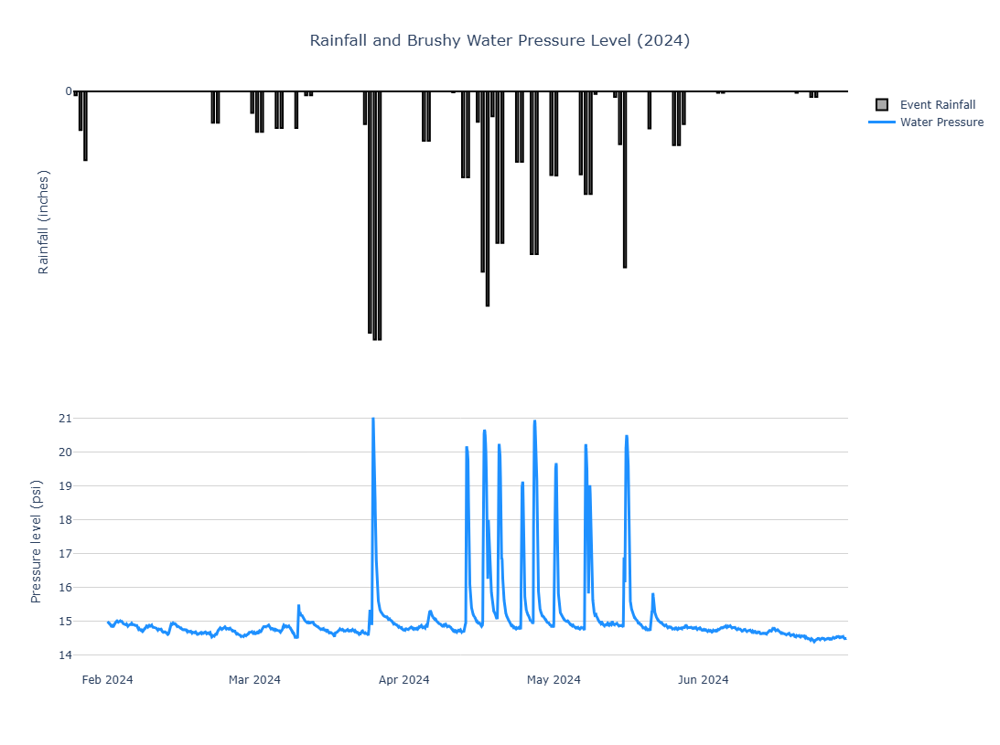

In [74]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Brushy1240_2.15.24__7.15.24__OttoSolar_21839261_0.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Brushy1240_1.28.25_5.16.25_21839261.csv"   # 1/28/2025 to 5/16/2025
RAIN_CSV = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/otto_results/new_weather.csv"                  # 02/09/2024–05/12/2025

# Focus year
YEAR_FOCUS = 2024

# Pressure line: break if gap > N hours (prevents fake line across missing months)
GAP_HOURS = 24

# Rain distribution bins (inches) for summary
RAIN_BINS = [0, 0.01, 0.10, 0.25, 0.50, 1.0, 2.0, np.inf]
RAIN_BIN_LABELS = ["0–0.01", "0.01–0.10", "0.10–0.25", "0.25–0.50", "0.50–1.0", "1.0–2.0", "2.0+"]


# ============================================================
# PRESSURE READER (ROBUST FOR YOUR EXPORT FORMAT)
# ============================================================
PRESSURE_DT_COL = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

def read_pressure_csv_hobo(filepath: str) -> pd.DataFrame:
    """
    Finds the header row (line containing Date Time, GMT-06:00 and Abs Pres, psi...)
    then reads from there and keeps only DateTime + pressure.
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if (PRESSURE_DT_COL in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header row in {filepath} containing '{PRESSURE_DT_COL}'")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Some exports have a leading index column '#'
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    # Ensure the exact columns exist (use substring fallback if needed)
    if PRESSURE_DT_COL not in df.columns:
        dt_col = next((c for c in df.columns if "Date Time" in str(c)), None)
    else:
        dt_col = PRESSURE_DT_COL

    if PRESSURE_PSI_COL not in df.columns:
        psi_col = next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)
    else:
        psi_col = PRESSURE_PSI_COL

    if dt_col is None or psi_col is None:
        raise ValueError(f"Could not locate DateTime/Pressure columns in {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, psi_col]].copy()
    out.columns = ["DateTime", "pressure_psi"]

    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure_psi"] = pd.to_numeric(out["pressure_psi"], errors="coerce")

    out = out.dropna(subset=["DateTime", "pressure_psi"]).sort_values("DateTime").reset_index(drop=True)
    return out


def break_pressure_line_on_gaps(df: pd.DataFrame, gap_hours: float) -> pd.DataFrame:
    """
    Inserts NaNs where the time gap exceeds gap_hours so Plotly breaks the line.
    """
    d = df.sort_values("DateTime").copy()
    gaps = d["DateTime"].diff().dt.total_seconds() / 3600.0
    d.loc[gaps > gap_hours, "pressure_psi"] = np.nan
    return d


# ============================================================
# RAIN READER (YOUR COLUMN NAMES)
# ============================================================
RAIN_DATE_COL = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

def read_rain_daily_max(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")

    if RAIN_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(f"Rain CSV missing expected columns. Found: {list(rain.columns)}")

    r = rain[[RAIN_DATE_COL, RAIN_EVENT_COL]].copy()
    r["Date"] = pd.to_datetime(r[RAIN_DATE_COL], errors="coerce").dt.normalize()
    r["EventRain_in"] = pd.to_numeric(r[RAIN_EVENT_COL], errors="coerce")

    r = r.dropna(subset=["Date", "EventRain_in"])

    daily = (
        r.groupby("Date", as_index=False)["EventRain_in"]
         .max()
         .rename(columns={"EventRain_in": "DailyMaxEventRain_in"})
         .sort_values("Date")
         .reset_index(drop=True)
    )
    return daily


# ============================================================
# LOAD + FILTER TO YEAR
# ============================================================
p1 = read_pressure_csv_hobo(PRESSURE_CSV_1)
p2 = read_pressure_csv_hobo(PRESSURE_CSV_2)
pressure_df = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily = read_rain_daily_max(RAIN_CSV)

start = pd.Timestamp(f"{YEAR_FOCUS}-01-01")
end   = pd.Timestamp(f"{YEAR_FOCUS}-12-31")


# ============================================================
# FILTER TO YEAR_FOCUS (FIX)
# ============================================================
pressure_y = pressure_df[(pressure_df["DateTime"] >= start) & (pressure_df["DateTime"] <= end + pd.Timedelta(days=1))].copy()
rain_daily  = rain_daily[(rain_daily["Date"] >= start) & (rain_daily["Date"] <= end)].copy()

# ============================================================
# ALIGN END DATES: stop rainfall where PSI ends (for this year)
# ============================================================
if len(pressure_df) == 0:
    raise ValueError("No pressure data found in the selected YEAR_FOCUS window.")

psi_end_day = pressure_y["DateTime"].max().normalize()
rain_y = rain_daily[rain_daily["Date"] <= psi_end_day].copy()
#=================================================================
#==================================================================

# Trim pressure to end at last rainfall day in the year (if rain exists)
if len(rain_y) > 0:
    rain_end = rain_y["Date"].max()
    pressure_y = pressure_y[pressure_y["DateTime"] <= (rain_end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()

# Break pressure line across gaps
pressure_y = break_pressure_line_on_gaps(pressure_y, GAP_HOURS)

# Make rain bars downward (negative)
rain_y["RainDown"] = rain_y["DailyMaxEventRain_in"]

# Build rain axis ticks (positive labels)
rain_max = float(rain_y["DailyMaxEventRain_in"].max()) if len(rain_y) else 1.0
tick_step = 0.5 if rain_max <= 3 else 1.0
ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
ticks_neg = -ticks_pos


# ============================================================
# SUMMARY TABLES (PRINT)
# ============================================================
print("\n============================")
print(f"SUMMARY TABLES ({YEAR_FOCUS})")
print("============================")

# Rain distribution
if len(rain_y) == 0:
    print("\nRain: No records found.")
else:
    rvals = rain_y["DailyMaxEventRain_in"]
    bins = pd.cut(rvals, bins=RAIN_BINS, labels=RAIN_BIN_LABELS, include_lowest=True, right=False)

    rain_dist = (
        bins.value_counts()
            .rename_axis("Daily max event rain (in)")
            .reset_index(name="Days")
            .sort_values("Daily max event rain (in)")
    )
    rain_dist["Percent"] = (rain_dist["Days"] / rain_dist["Days"].sum() * 100).round(1)

    print("\n--- Rain distribution (Daily MAX of Event Rain, inches) ---")
    print(rain_dist.to_string(index=False))

    print("\n--- Rain summary ---")
    print(f"Days in period: {len(rvals)}")
    print(f"Days with rain > 0: {(rvals > 0).sum()}")
    print(f"Mean:   {rvals.mean():.3f}")
    print(f"Median: {rvals.median():.3f}")
    print(f"P90:    {rvals.quantile(0.90):.3f}")
    print(f"P95:    {rvals.quantile(0.95):.3f}")
    print(f"Max:    {rvals.max():.3f}")
    print(f"Sum of daily max: {rvals.sum():.3f}")

# Pressure stats
pvals = pressure_y["pressure_psi"].dropna()
if len(pvals) == 0:
    print("\nPressure: No records found.")
else:
    stats = pd.DataFrame([{
        "n": len(pvals),
        "min": pvals.min(),
        "p05": pvals.quantile(0.05),
        "p25": pvals.quantile(0.25),
        "median": pvals.median(),
        "mean": pvals.mean(),
        "p75": pvals.quantile(0.75),
        "p95": pvals.quantile(0.95),
        "max": pvals.max(),
        "std": pvals.std(),
    }]).round(3)

    print("\n--- Water pressure stats (psi) ---")
    print(stats.to_string(index=False))


# ============================================================
# PLOTLY FIGURE (MATCH YOUR FORMAT)
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.10,
    row_heights=[0.5, 0.5]
)

# Rain bars (down)
fig.add_trace(go.Bar(
    x=rain_y["Date"],
    y=rain_y["RainDown"],  # negative => down
    name="Event Rainfall",
    marker=dict(color="darkgray", line=dict(color="black", width=2)),
    hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
    customdata=rain_y["DailyMaxEventRain_in"],
), row=1, col=1)

# Pressure line
fig.add_trace(go.Scatter(
    x=pressure_y["DateTime"],
    y=pressure_y["pressure_psi"],
    name="Water Pressure",
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    showlegend=True
), row=2, col=1)

# Layout
fig.update_layout(
    title=f"Rainfall and Brushy Water Pressure Level ({YEAR_FOCUS})",
    xaxis_title="",
    height=800,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    title_x=0.5,
)

# Rain axis: reversed so bars hang down; labels show positive
fig.update_yaxes(
    title_text="Rainfall (inches)",
    row=1, col=1,
    autorange="reversed",
    tickvals=ticks_neg,
    ticktext=[f"{t:g}" for t in ticks_pos],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=True,
    zerolinecolor="black",
)

# -----------------------------
# Pressure axis (FIX: add padding below, keep grid/ticks clean)
# -----------------------------
pvals = pressure_y["pressure_psi"].dropna()
pmin = float(pvals.min())
pmax = float(pvals.max())

fig.update_yaxes(
    row=2, col=1,
    title_text="Pressure level (psi)",
    range=[min(14.0, pmin) - 0.5, pmax + 0.2],  # <-- forces space below 14
    tick0=14,
    dtick=1,
    showgrid=True,
    gridcolor="lightgray",
    zeroline=False
)

# # ---- FIX pressure ticks (this is the line you asked about) ----
# fig.update_yaxes(
#     row=2, col=1,
#     range=[14, 22],
#     tick0=14,
#     dtick=1
# )

# # -----------------------------
# # FIX: make bottom tick (14) not sit on the axis baseline
# # -----------------------------
# pmin = float(pressure_y["pressure_psi"].min())
# pmax = float(pressure_y["pressure_psi"].max())

# # give a little breathing room below the minimum
# pad = 0.3  # try 0.2–0.5 if you want more/less space

# fig.update_yaxes(
#     row=2, col=1,
#     range=[pmin - pad, pmax + 0.2],   # <-- padding creates space under 14
#     tick0=14,
#     dtick=1,
#     showgrid=True,
#     gridcolor="lightgray",
#     zeroline=False
# )

# X axis: monthly ticks (prevents duplicate Jan 2025)
fig.update_xaxes(
    row=2, col=1,
    dtick="M1",
    tickformat="%b %Y",
    ticklabelmode="period"
)

fig.update_layout(bargap=0.55)  # bigger gap => bars look thinner

fig.show()

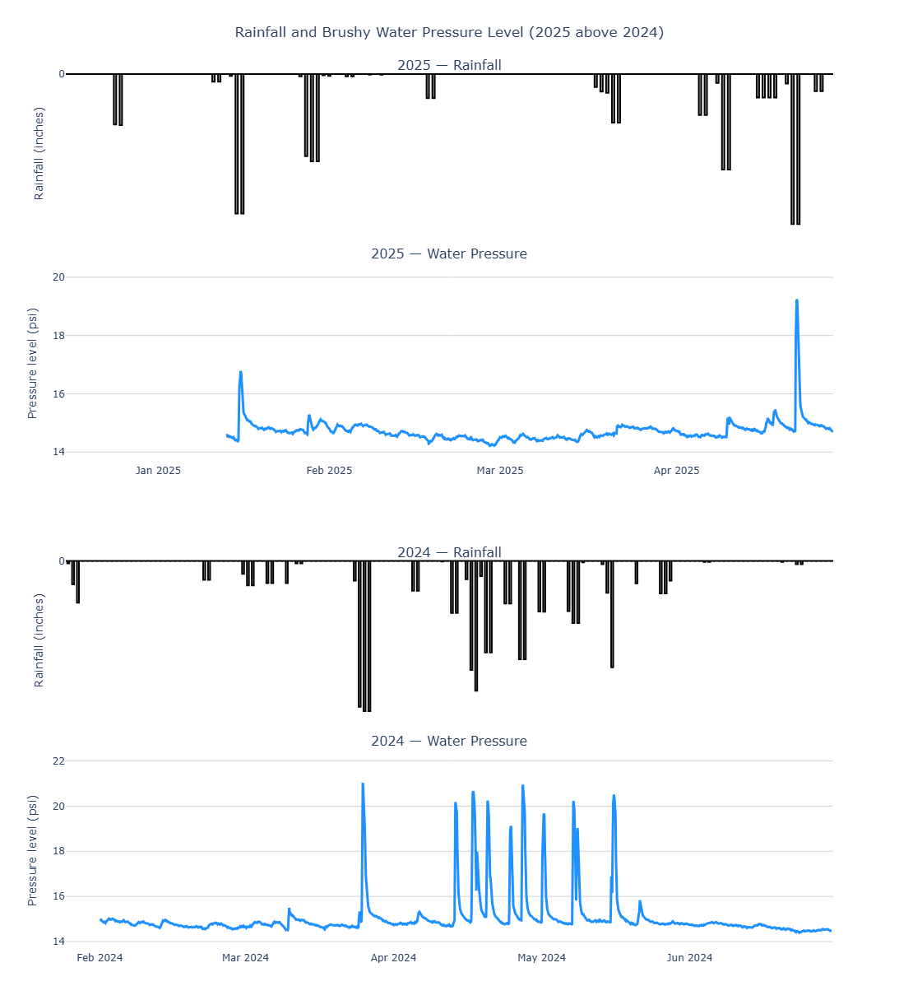

In [75]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Brushy1240_2.15.24__7.15.24__OttoSolar_21839261_0.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Brushy1240_1.28.25_5.16.25_21839261.csv"                # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/otto_results/new_weather.csv"                 # 02/09/2024–05/12/2025

# Years (top -> bottom)
YEARS = [2025, 2024]

# Pressure line: break if gap > N hours (prevents fake line across missing months)
GAP_HOURS = 24

# Pressure axis controls (YOUR CURRENT REQUEST)
PRESSURE_YMIN_TICK = 14.0     # lowest labeled tick you want to see
PRESSURE_Y_PAD_BELOW = 0.4    # make plot start slightly below 14 so the 14 gridline appears
PRESSURE_DTICK = 2.0          # fewer labels: 14,16,18,...

# ============================================================
# PRESSURE READER (ROBUST FOR YOUR EXPORT FORMAT)
# ============================================================
PRESSURE_DT_COL  = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

def read_pressure_csv_hobo(filepath: str) -> pd.DataFrame:
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if (PRESSURE_DT_COL in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header row in {filepath} containing '{PRESSURE_DT_COL}'")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Some exports have a leading index column '#'
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    dt_col = PRESSURE_DT_COL if PRESSURE_DT_COL in df.columns else next((c for c in df.columns if "Date Time" in str(c)), None)
    psi_col = PRESSURE_PSI_COL if PRESSURE_PSI_COL in df.columns else next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)

    if dt_col is None or psi_col is None:
        raise ValueError(f"Could not locate DateTime/Pressure columns in {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, psi_col]].copy()
    out.columns = ["DateTime", "pressure_psi"]
    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure_psi"] = pd.to_numeric(out["pressure_psi"], errors="coerce")
    out = out.dropna(subset=["DateTime", "pressure_psi"]).sort_values("DateTime").reset_index(drop=True)
    return out

def break_pressure_line_on_gaps(df: pd.DataFrame, gap_hours: float) -> pd.DataFrame:
    d = df.sort_values("DateTime").copy()
    gaps = d["DateTime"].diff().dt.total_seconds() / 3600.0
    d.loc[gaps > gap_hours, "pressure_psi"] = np.nan
    return d

# ============================================================
# RAIN READER (YOUR COLUMN NAMES)
# ============================================================
RAIN_DATE_COL  = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

def read_rain_daily_max(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")
    if RAIN_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(f"Rain CSV missing expected columns. Found: {list(rain.columns)}")

    r = rain[[RAIN_DATE_COL, RAIN_EVENT_COL]].copy()
    r["Date"] = pd.to_datetime(r[RAIN_DATE_COL], errors="coerce").dt.normalize()
    r["EventRain_in"] = pd.to_numeric(r[RAIN_EVENT_COL], errors="coerce")
    r = r.dropna(subset=["Date", "EventRain_in"])

    daily = (
        r.groupby("Date", as_index=False)["EventRain_in"]
         .max()
         .rename(columns={"EventRain_in": "DailyMaxEventRain_in"})
         .sort_values("Date")
         .reset_index(drop=True)
    )
    return daily

# ============================================================
# LOAD ONCE
# ============================================================
p1 = read_pressure_csv_hobo(PRESSURE_CSV_1)
p2 = read_pressure_csv_hobo(PRESSURE_CSV_2)
pressure_all = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily_all = read_rain_daily_max(RAIN_CSV)

# ============================================================
# YEAR PREP (TRIM TO OVERLAP + BUILD AXIS TICKS)
# ============================================================
def prep_year(year: int):
    start = pd.Timestamp(f"{year}-01-01")
    end   = pd.Timestamp(f"{year}-12-31")

    pressure_y = pressure_all[
        (pressure_all["DateTime"] >= start) &
        (pressure_all["DateTime"] <= end + pd.Timedelta(days=1))
    ].copy()

    rain_y = rain_daily_all[
        (rain_daily_all["Date"] >= start) &
        (rain_daily_all["Date"] <= end)
    ].copy()

    # Align END dates (overlap window): trim rain to psi end (your 2024 request)
    if len(pressure_y) > 0 and len(rain_y) > 0:
        pressure_end_date = pressure_y["DateTime"].max().normalize()
        rain_end_date = rain_y["Date"].max()

        if rain_end_date > pressure_end_date:
            rain_y = rain_y[rain_y["Date"] <= pressure_end_date].copy()
        elif pressure_end_date > rain_end_date:
            pressure_y = pressure_y[
                pressure_y["DateTime"] <= (rain_end_date + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))
            ].copy()

    # Break pressure line across gaps
    pressure_y = break_pressure_line_on_gaps(pressure_y, GAP_HOURS)

    # Rain bars downward via reversed axis
    rain_y["RainDown"] = rain_y["DailyMaxEventRain_in"]

    # Rain axis ticks (positive labels, negative positions because axis is reversed)
    rain_max = float(rain_y["DailyMaxEventRain_in"].max()) if len(rain_y) else 1.0
    tick_step = 0.5 if rain_max <= 3 else 1.0
    ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
    ticks_neg = -ticks_pos

    # Pressure y max (pad a bit so top isn't tight)
    if len(pressure_y) > 0:
        pmax = float(pressure_y["pressure_psi"].max())
        pressure_ymax = max(PRESSURE_YMIN_TICK + 2.0, np.ceil(pmax) + 0.5)
    else:
        pressure_ymax = PRESSURE_YMIN_TICK + 2.0

    return pressure_y, rain_y, ticks_pos, ticks_neg, pressure_ymax

data = {y: prep_year(y) for y in YEARS}

# ============================================================
# COMBINED FIGURE (with spacer row)
#   2025 block: rows 1-2
#   spacer:     row 3
#   2024 block: rows 4-5
# ============================================================
fig = make_subplots(
    rows=5, cols=1,
    shared_xaxes=False,
    row_heights=[0.22, 0.28, 0.05, 0.22, 0.28],
    vertical_spacing=0.035,
    # row_heights=[0.22, 0.28, 0.10, 0.22, 0.28],
    # vertical_spacing=0.05,
    subplot_titles=[
        f"{YEARS[0]} — Rainfall", f"{YEARS[0]} — Water Pressure",
        "",
        f"{YEARS[1]} — Rainfall", f"{YEARS[1]} — Water Pressure",
    ],
)

row_map = {YEARS[0]: (1, 2), YEARS[1]: (4, 5)}

for year in YEARS:
    pressure_y, rain_y, ticks_pos, ticks_neg, pressure_ymax = data[year]
    r_rain, r_press = row_map[year]

    # Rain bars
    fig.add_trace(
        go.Bar(
            x=rain_y["Date"],
            y=rain_y["RainDown"],
            marker=dict(color="darkgray", line=dict(color="black", width=2)),
            hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
            customdata=rain_y["DailyMaxEventRain_in"],
            showlegend=False,
        ),
        row=r_rain, col=1
    )

    # Pressure line
    fig.add_trace(
        go.Scatter(
            x=pressure_y["DateTime"],
            y=pressure_y["pressure_psi"],
            mode="lines",
            line=dict(color="dodgerblue", width=3),
            showlegend=False,
        ),
        row=r_press, col=1
    )

    # Rain axis (reversed so bars hang down)
    fig.update_yaxes(
        title_text="Rainfall (inches)",
        row=r_rain, col=1,
        autorange="reversed",
        tickvals=ticks_neg,
        ticktext=[f"{t:g}" for t in ticks_pos],
        showgrid=True,
        gridcolor="lightgray",
        zeroline=True,
        zerolinecolor="black",
    )

    # Pressure axis:
    # - range starts slightly below 14 => 14 gridline appears and isn't glued to x-axis
    # - dtick=2 => fewer y labels
    fig.update_yaxes(
        title_text="Pressure level (psi)",
        row=r_press, col=1,
        range=[PRESSURE_YMIN_TICK - PRESSURE_Y_PAD_BELOW, pressure_ymax],
        tick0=PRESSURE_YMIN_TICK,
        dtick=PRESSURE_DTICK,
        showgrid=True,
        gridcolor="lightgray",
        zeroline=True,
        zerolinecolor="black",
    )

# Spacer row hidden
fig.update_xaxes(visible=False, row=3, col=1)
fig.update_yaxes(visible=False, row=3, col=1)

# Match rain x with psi x within each year block
fig.update_xaxes(matches="x",  row=2, col=1)   # 2025 psi matches 2025 rain
fig.update_xaxes(matches="x4", row=5, col=1)   # 2024 psi matches 2024 rain

# Hide x tick labels on rain rows
fig.update_xaxes(showticklabels=False, row=1, col=1)
fig.update_xaxes(showticklabels=False, row=4, col=1)

# Monthly ticks on pressure rows
fig.update_xaxes(row=2, col=1, dtick="M1", tickformat="%b %Y", ticklabelmode="period")
fig.update_xaxes(row=5, col=1, dtick="M1", tickformat="%b %Y", ticklabelmode="period")

# Layout
fig.update_layout(
    title="Rainfall and Brushy Water Pressure Level (2025 above 2024)",
    title_x=0.5,
    height=1200,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    bargap=0.58,
    margin=dict(t=90, b=60),
)

fig.show()

C:\Users\Emeka_Orji1\AppData\Local\Temp\ipykernel_11352\2512921024.py:58: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\Emeka_Orji1\AppData\Local\Temp\ipykernel_11352\2512921024.py:58: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



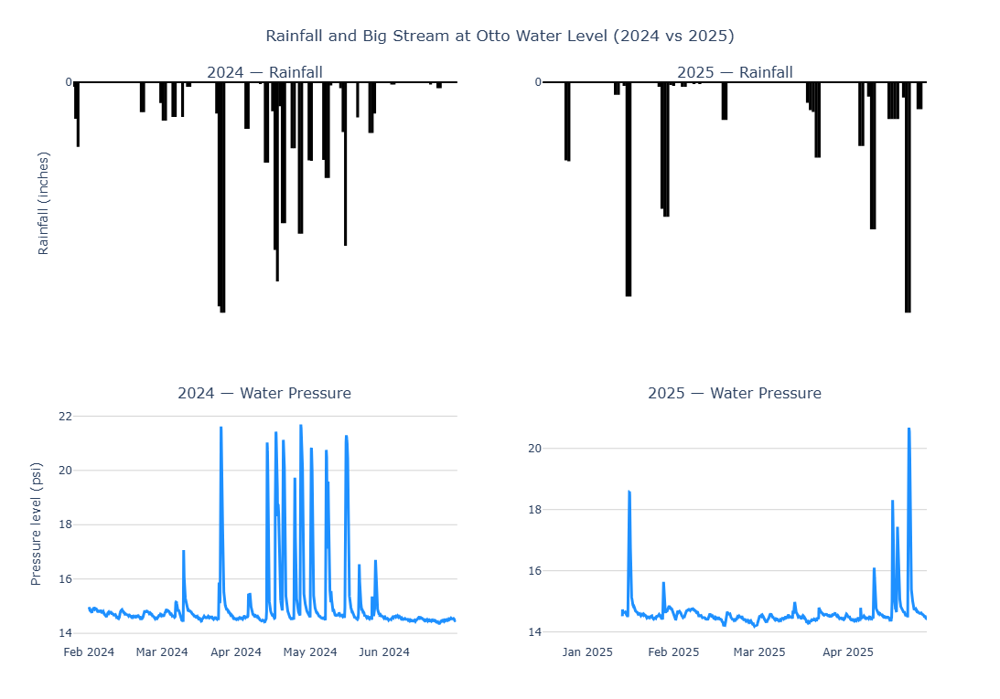

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# FILE PATHS (EDIT)
# ============================================================
PRESSURE_CSV_1 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_2.15.24__7.15.24__OttoSolar_21839259.csv"   # 2/15/2024 to 7/15/2024
PRESSURE_CSV_2 = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/HoBo/OttoSolar/WaterLevel_Big162_1.28.25_5.16.25_21839259.csv"                # 1/28/2025 to 5/16/2025
RAIN_CSV       = r"C:/Users/Emeka_Orji1/Box/Water_Quality_Work/watersheds/otto_results/new_weather.csv"                 # 02/09/2024–05/12/2025

# Columns = years (left -> right)
YEAR_LEFT  = 2024
YEAR_RIGHT = 2025
YEARS = [YEAR_LEFT, YEAR_RIGHT]  # col 1, col 2

# Break pressure line if gap > N hours (prevents fake line across missing months)
GAP_HOURS = 24

# Pressure axis cosmetics (so 14 isn't glued to x-axis + fewer labels)
PRESSURE_YMIN_TICK   = 14.0
PRESSURE_Y_PAD_BELOW = 0.4
PRESSURE_DTICK       = 2.0  # 14,16,18,...

# ============================================================
# PRESSURE READER (ROBUST FOR YOUR EXPORT FORMAT)
# ============================================================
PRESSURE_DT_COL  = "Date Time, GMT-06:00"
PRESSURE_PSI_COL = "Abs Pres, psi (LGR S/N: 21839259, SEN S/N: 21839259)"

def read_pressure_csv_hobo(filepath: str) -> pd.DataFrame:
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines[:400]):
        if (PRESSURE_DT_COL in line) and ("Abs Pres" in line):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header row in {filepath} containing '{PRESSURE_DT_COL}'")

    df = pd.read_csv(filepath, skiprows=header_idx, engine="python", on_bad_lines="skip")

    # Some exports have a leading index column
    if len(df.columns) > 0 and str(df.columns[0]).strip() in ["#", "Unnamed: 0", ""]:
        df = df.drop(columns=[df.columns[0]])

    dt_col = PRESSURE_DT_COL if PRESSURE_DT_COL in df.columns else next((c for c in df.columns if "Date Time" in str(c)), None)
    psi_col = PRESSURE_PSI_COL if PRESSURE_PSI_COL in df.columns else next((c for c in df.columns if ("Abs Pres" in str(c)) and ("psi" in str(c))), None)

    if dt_col is None or psi_col is None:
        raise ValueError(f"Could not locate DateTime/Pressure columns in {filepath}\nColumns: {list(df.columns)}")

    out = df[[dt_col, psi_col]].copy()
    out.columns = ["DateTime", "pressure_psi"]
    out["DateTime"] = pd.to_datetime(out["DateTime"], errors="coerce")
    out["pressure_psi"] = pd.to_numeric(out["pressure_psi"], errors="coerce")
    out = out.dropna(subset=["DateTime", "pressure_psi"]).sort_values("DateTime").reset_index(drop=True)
    return out

def break_pressure_line_on_gaps(df: pd.DataFrame, gap_hours: float) -> pd.DataFrame:
    d = df.sort_values("DateTime").copy()
    gaps = d["DateTime"].diff().dt.total_seconds() / 3600.0
    d.loc[gaps > gap_hours, "pressure_psi"] = np.nan
    return d

# ============================================================
# RAIN READER (YOUR COLUMN NAMES)
# ============================================================
RAIN_DATE_COL  = "Simple Date"
RAIN_EVENT_COL = "Event Rain (in)"

def read_rain_daily_max(filepath: str) -> pd.DataFrame:
    rain = pd.read_csv(filepath, engine="python")
    if RAIN_DATE_COL not in rain.columns or RAIN_EVENT_COL not in rain.columns:
        raise ValueError(f"Rain CSV missing expected columns. Found: {list(rain.columns)}")

    r = rain[[RAIN_DATE_COL, RAIN_EVENT_COL]].copy()
    r["Date"] = pd.to_datetime(r[RAIN_DATE_COL], errors="coerce").dt.normalize()
    r["EventRain_in"] = pd.to_numeric(r[RAIN_EVENT_COL], errors="coerce")
    r = r.dropna(subset=["Date", "EventRain_in"])

    daily = (
        r.groupby("Date", as_index=False)["EventRain_in"]
         .max()
         .rename(columns={"EventRain_in": "DailyMaxEventRain_in"})
         .sort_values("Date")
         .reset_index(drop=True)
    )
    return daily

# ============================================================
# LOAD ONCE
# ============================================================
p1 = read_pressure_csv_hobo(PRESSURE_CSV_1)
p2 = read_pressure_csv_hobo(PRESSURE_CSV_2)
pressure_all = pd.concat([p1, p2], ignore_index=True).sort_values("DateTime").reset_index(drop=True)

rain_daily_all = read_rain_daily_max(RAIN_CSV)

# ============================================================
# YEAR PREP (TRIM RAIN TO PSI END / OVERLAP)
# ============================================================
def prep_year(year: int):
    start = pd.Timestamp(f"{year}-01-01")
    end   = pd.Timestamp(f"{year}-12-31")

    pressure_y = pressure_all[
        (pressure_all["DateTime"] >= start) &
        (pressure_all["DateTime"] <= end + pd.Timedelta(days=1))
    ].copy()

    rain_y = rain_daily_all[
        (rain_daily_all["Date"] >= start) &
        (rain_daily_all["Date"] <= end)
    ].copy()

    # Align END dates (use overlap window)
    if len(pressure_y) > 0 and len(rain_y) > 0:
        pressure_end_date = pressure_y["DateTime"].max().normalize()
        rain_end_date = rain_y["Date"].max()

        # Trim rain to psi end (your 2024 request)
        if rain_end_date > pressure_end_date:
            rain_y = rain_y[rain_y["Date"] <= pressure_end_date].copy()
        # Symmetry if needed
        elif pressure_end_date > rain_end_date:
            pressure_y = pressure_y[
                pressure_y["DateTime"] <= (rain_end_date + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))
            ].copy()

    # Break line across gaps
    pressure_y = break_pressure_line_on_gaps(pressure_y, GAP_HOURS)

    # Rain bars downward via reversed axis
    rain_y["RainDown"] = rain_y["DailyMaxEventRain_in"]

    # Rain ticks
    rain_max = float(rain_y["DailyMaxEventRain_in"].max()) if len(rain_y) else 1.0
    tick_step = 0.5 if rain_max <= 3 else 1.0
    ticks_pos = np.arange(0, rain_max + tick_step, tick_step)
    ticks_neg = -ticks_pos

    # Pressure y max
    if len(pressure_y) > 0:
        pmax = float(pressure_y["pressure_psi"].max())
        pressure_ymax = max(PRESSURE_YMIN_TICK + 2.0, np.ceil(pmax) + 0.5)
    else:
        pressure_ymax = PRESSURE_YMIN_TICK + 2.0

    # X-range for each year column (so rainfall & psi align vertically)
    x_start = None
    x_end = None
    if len(pressure_y) > 0:
        x_start = pressure_y["DateTime"].min()
        x_end = pressure_y["DateTime"].max()
    if len(rain_y) > 0:
        r_start = rain_y["Date"].min()
        r_end = rain_y["Date"].max() + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
        x_start = r_start if x_start is None else min(x_start, r_start)
        x_end = r_end if x_end is None else max(x_end, r_end)

    return pressure_y, rain_y, ticks_pos, ticks_neg, pressure_ymax, x_start, x_end

data = {y: prep_year(y) for y in YEARS}

# ============================================================
# 2 ROWS x 2 COLS:
# Rows = variable: Row 1 Rainfall, Row 2 Water Pressure
# Cols = years:    Col 1 2024,     Col 2 2025
# ============================================================
fig = make_subplots(
    rows=2, cols=2,
    shared_xaxes=False,
    horizontal_spacing=0.10,
    vertical_spacing=0.14,
    column_widths=[0.5, 0.5],
    subplot_titles=[
        f"{YEAR_LEFT} — Rainfall", f"{YEAR_RIGHT} — Rainfall",
        f"{YEAR_LEFT} — Water Pressure", f"{YEAR_RIGHT} — Water Pressure",
    ],
)

# Add each year into its column
for col, year in enumerate(YEARS, start=1):
    pressure_y, rain_y, ticks_pos, ticks_neg, pressure_ymax, x_start, x_end = data[year]

    # ---------- Row 1: Rainfall ----------
    fig.add_trace(
        go.Bar(
            x=rain_y["Date"],
            y=rain_y["RainDown"],
            marker=dict(color="darkgray", line=dict(color="black", width=2)),
            hovertemplate="Date: %{x|%Y-%m-%d}<br>Daily max event rain: %{customdata:.2f} in<extra></extra>",
            customdata=rain_y["DailyMaxEventRain_in"],
            showlegend=False,
        ),
        row=1, col=col
    )

    fig.update_yaxes(
        title_text="Rainfall (inches)" if col == 1 else "",
        row=1, col=col,
        autorange="reversed",
        tickvals=ticks_neg,
        ticktext=[f"{t:g}" for t in ticks_pos],
        showgrid=True,
        gridcolor="lightgray",
        zeroline=True,
        zerolinecolor="black",
    )

    # ---------- Row 2: Water Pressure ----------
    fig.add_trace(
        go.Scatter(
            x=pressure_y["DateTime"],
            y=pressure_y["pressure_psi"],
            mode="lines",
            line=dict(color="dodgerblue", width=3),
            showlegend=False,
        ),
        row=2, col=col
    )

    fig.update_yaxes(
        title_text="Pressure level (psi)" if col == 1 else "",
        row=2, col=col,
        range=[PRESSURE_YMIN_TICK - PRESSURE_Y_PAD_BELOW, pressure_ymax],
        tick0=PRESSURE_YMIN_TICK,
        dtick=PRESSURE_DTICK,
        showgrid=True,
        gridcolor="lightgray",
        zeroline=True,
        zerolinecolor="black",
    )

    # ---------- Force same x-range for rainfall & psi within each year column ----------
    if x_start is not None and x_end is not None:
        fig.update_xaxes(range=[x_start, x_end], row=1, col=col)
        fig.update_xaxes(range=[x_start, x_end], row=2, col=col)

    # Monthly ticks on bottom row only (pressure row)
    fig.update_xaxes(row=2, col=col, dtick="M1", tickformat="%b %Y", ticklabelmode="period")

    # Hide rainfall x tick labels (top row) to reduce clutter
    fig.update_xaxes(showticklabels=False, row=1, col=col)

# Layout
fig.update_layout(
    title=f"Rainfall and Big Stream at Otto Water Level ({YEAR_LEFT} vs {YEAR_RIGHT})",
    title_x=0.5,
    height=750,
    width=1200,
    plot_bgcolor="white",
    paper_bgcolor="rgba(255, 255, 255, 1)",
    bargap=0.58,
    margin=dict(t=90, b=60),
)

fig.show()

In [77]:
# Combined Turbidity Plot for all Watersheds

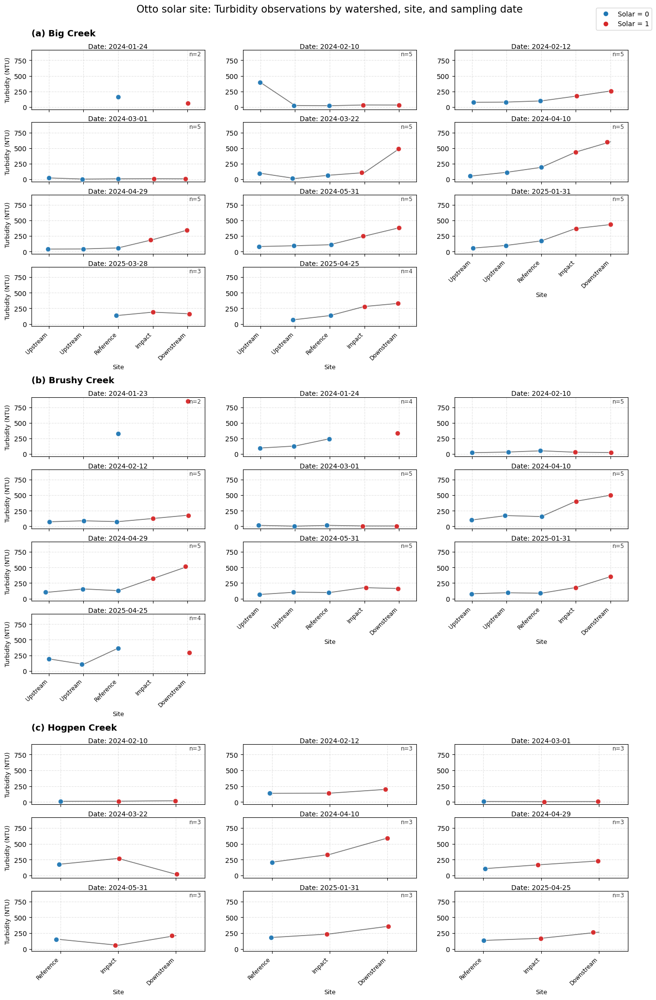

Saved PNG: mart/mart_combined_turbidity_faceted_linear.png
Saved PDF: mart/mart_combined_turbidity_faceted_linear.pdf


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# INPUT DATAFRAMES
# Use your existing dataframes:
#   big_filt, brushy_filt, hog_filt
# ============================================================

# ============================================================
# GLOBAL SETTINGS
# ============================================================
DATE_COL  = "Date"
SITE_COL  = "Site"
Y_COL     = "Turbidity"
SOLAR_COL = "Solar"

NCOLS = 3
CONNECT_SITES = True
COMMON_YLIM = True      # True = same y-axis across all 3 watersheds
SAVE_FIG = True

OUT_PNG = "mart/mart_combined_turbidity_faceted_linear.png"
OUT_PDF = "mart/mart_combined_turbidity_faceted_linear.pdf"
DPI = 800

# Colors
COLOR_MAP = {0: "tab:blue", 1: "tab:red"}

# ============================================================
# WATERSHED-SPECIFIC SETTINGS
# ============================================================

big_settings = {
    "panel_label": "(a) Big Creek",
    "df": big_filt.copy(),
    "dates_to_drop": ["2/15/2024", "1/28/2025"],
    "site_order": [
        "Big @ Lake Felton",
        "Big @ Battle Lake",
        "Big @ 168",
        "Big @ 165",
        "Big @ 162",
    ],
    "label_map": {
        "Big @ Lake Felton": "Upstream",
        "Big @ Battle Lake": "Upstream",
        "Big @ 168": "Reference",
        "Big @ 165": "Impact",
        "Big @ 162": "Downstream",
    },
}

brushy_settings = {
    "panel_label": "(b) Brushy Creek",
    "df": brushy_filt.copy(),
    "dates_to_drop": ["2/15/2024", "4/9/2024"],
    "site_order": [
        "Little Brushy @ 118",
        "Little Brushy @ 150",
        "Brushy @ 118",
        "Brushy @ 1240",
        "Brushy @ 152",
    ],
    "label_map": {
        "Little Brushy @ 118": "Upstream",
        "Little Brushy @ 150": "Upstream",
        "Brushy @ 118": "Reference",
        "Brushy @ 1240": "Impact",
        "Brushy @ 152": "Downstream",
    },
}

hog_settings = {
    "panel_label": "(c) Hogpen Creek",
    "df": hog_filt.copy(),
    "dates_to_drop": ["2/15/2024"],
    "site_order": [
        "Hogpen @ LCR 608",
        "Hogpen @ 174",
        "Hogpen @ 162",
    ],
    "label_map": {
        "Hogpen @ LCR 608": "Reference",
        "Hogpen @ 174": "Impact",
        "Hogpen @ 162": "Downstream",
    },
}

watersheds = [big_settings, brushy_settings, hog_settings]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def prep_df(df, date_col, site_col, y_col, solar_col, site_order, dates_to_drop=None):
    d = df.copy()

    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d[solar_col] = pd.to_numeric(d[solar_col], errors="coerce")

    d = d.dropna(subset=[date_col, site_col, y_col])

    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    d = d[d[site_col].isin(site_order)].copy()
    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    return d

def get_linear_ylim(all_dfs, y_col):
    vals = []
    for d in all_dfs:
        y = pd.to_numeric(d[y_col], errors="coerce").dropna().values
        vals.extend(y.tolist())

    vals = np.array(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return -1, 10

    y_max = vals.max() * 1.08
    pad = 0.04 * y_max
    y_min = -pad
    return y_min, y_max

def draw_faceted_panel(fig, outer_spec, settings, y_limits, ncols=3, connect_sites=True):
    d = settings["df"]
    site_order = settings["site_order"]
    label_map = settings["label_map"]
    panel_label = settings["panel_label"]

    dates = sorted(d[DATE_COL].dt.normalize().unique())
    n_dates = len(dates)
    nrows = int(np.ceil(n_dates / ncols))

    inner = outer_spec.subgridspec(nrows, ncols, wspace=0.22, hspace=0.22)
    axes = []

    rng = np.random.default_rng(7)
    xtick_labels = [label_map.get(s, s) for s in site_order]

    # Find the bottom-most OCCUPIED row in each column
    bottom_row_by_col = {}
    for i in range(n_dates):
        r, c = divmod(i, ncols)
        bottom_row_by_col[c] = max(bottom_row_by_col.get(c, -1), r)

    for i, day in enumerate(dates):
        r, c = divmod(i, ncols)
        ax = fig.add_subplot(inner[r, c])
        axes.append(ax)

        sub = d[d[DATE_COL].dt.normalize() == day].copy()

        # Scatter by solar class
        for solar_val in sorted(sub[SOLAR_COL].dropna().unique()):
            try:
                solar_key = int(float(solar_val))
            except Exception:
                solar_key = None

            ss = sub[sub[SOLAR_COL] == solar_val]
            xb = ss[SITE_COL].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))

            ax.scatter(
                xx,
                ss[Y_COL],
                s=55,
                alpha=0.95,
                edgecolor="white",
                linewidth=0.6,
                color=COLOR_MAP.get(solar_key, "gray"),
                zorder=3,
            )

        # Median connection line
        if connect_sites:
            med = sub.groupby(SITE_COL, observed=True)[Y_COL].median().reindex(site_order)
            ax.plot(
                np.arange(len(site_order)),
                med.values,
                linewidth=1.2,
                alpha=0.55,
                color="black",
                zorder=2,
            )

        ax.set_title(f"Date: {pd.to_datetime(day).date()}", fontsize=10, pad=2)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)
        ax.set_ylim(*y_limits)

        ax.set_xticks(np.arange(len(site_order)))

        # Show x labels on the bottom-most occupied axis in each column
        if r == bottom_row_by_col[c]:
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=8.5)
            ax.set_xlabel("Site", fontsize=9)
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")

        # y label only on left column
        if c == 0:
            ax.set_ylabel("Turbidity (NTU)", fontsize=9)
        else:
            ax.set_ylabel("")

        ax.text(
            0.98, 0.98, f"n={len(sub)}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=8.5, alpha=0.8
        )

    # Hide unused cells
    for j in range(n_dates, nrows * ncols):
        r, c = divmod(j, ncols)
        ax = fig.add_subplot(inner[r, c])
        ax.axis("off")
        axes.append(ax)

    # Add watershed panel label above the block
    used_axes = [ax for ax in axes if ax.has_data()]
    bbox = used_axes[0].get_position()
    fig.text(
        bbox.x0, bbox.y1 + 0.012,   # was 0.004
        panel_label,
        ha="left", va="bottom",
        fontsize=13,
        fontweight="bold"
    )

    return nrows

# ============================================================
# PREPARE DATA
# ============================================================

for ws in watersheds:
    ws["df"] = prep_df(
        ws["df"],
        date_col=DATE_COL,
        site_col=SITE_COL,
        y_col=Y_COL,
        solar_col=SOLAR_COL,
        site_order=ws["site_order"],
        dates_to_drop=ws["dates_to_drop"],
    )

# Use one common y-axis if desired
if COMMON_YLIM:
    common_y_limits = get_linear_ylim([ws["df"] for ws in watersheds], Y_COL)
else:
    common_y_limits = None

# Dynamic figure height based on number of facet rows in each watershed
row_counts = []
for ws in watersheds:
    n_dates = ws["df"][DATE_COL].dt.normalize().nunique()
    row_counts.append(int(np.ceil(n_dates / NCOLS)))

total_rows = sum(row_counts)
fig_height = max(16, total_rows * 1.9)   # slightly less tall than before
fig = plt.figure(figsize=(14, fig_height))

outer = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=row_counts,
    hspace=0.28,
    top=0.94,
    bottom=0.05,
    left=0.06,
    right=0.94,
)

# ============================================================
# DRAW PANELS
# ============================================================

for i, ws in enumerate(watersheds):
    y_limits = common_y_limits if COMMON_YLIM else get_linear_ylim([ws["df"]], Y_COL)
    draw_faceted_panel(
        fig=fig,
        outer_spec=outer[i],
        settings=ws,
        y_limits=y_limits,
        ncols=NCOLS,
        connect_sites=CONNECT_SITES,
    )

# Shared legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Solar = 0',
           markerfacecolor=COLOR_MAP[0], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Solar = 1',
           markerfacecolor=COLOR_MAP[1], markersize=8),
]
fig.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.985),
    frameon=True
)

fig.suptitle(
    "Otto solar site: Turbidity observations by watershed, site, and sampling date",
    y=0.985,
    fontsize=15
)

plt.show()

# ============================================================
# SAVE
# ============================================================
if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    fig.savefig(OUT_PDF, bbox_inches="tight")
    print(f"Saved PNG: {OUT_PNG}")
    print(f"Saved PDF: {OUT_PDF}")

In [48]:
#### Same combined plot as above, improved for publication


Saving manuscript-ready figure files...
Saved 600 dpi PNG: mart\new_plots\mart_combined_turbidity_faceted_linear_600dpi.png
Saved 1000 dpi PNG: mart\new_plots\mart_combined_turbidity_faceted_linear_1000dpi.png
Saved 1000 dpi TIFF: mart\new_plots\mart_combined_turbidity_faceted_linear_1000dpi.tif
Saved 1000 dpi PDF: mart\new_plots\mart_combined_turbidity_faceted_linear_1000dpi.pdf


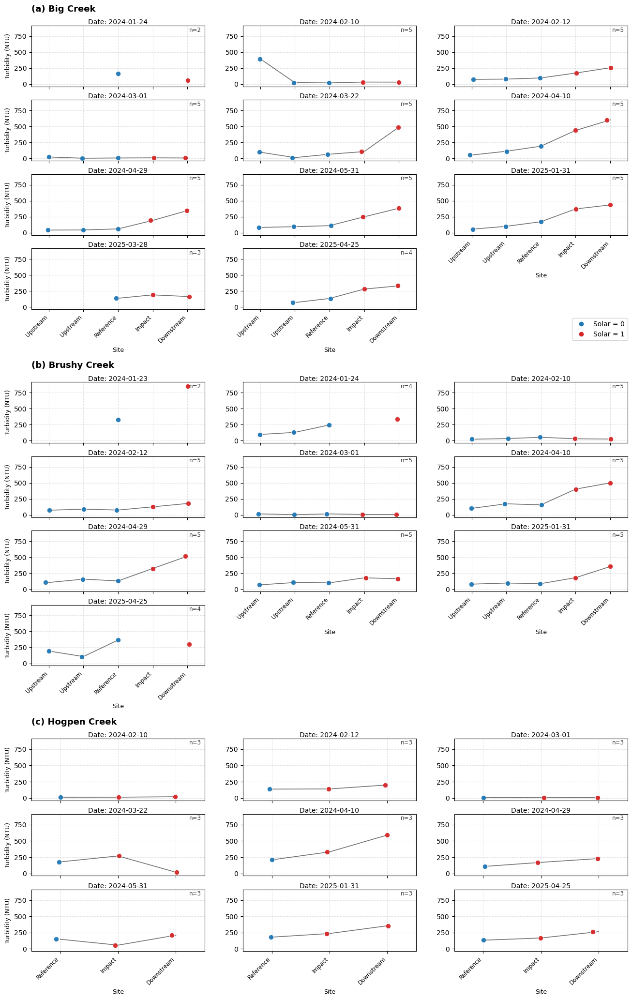

In [51]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# INPUT DATAFRAMES
# Use your existing dataframes:
#   big_filt, brushy_filt, hog_filt
# ============================================================

# ============================================================
# GLOBAL SETTINGS
# ============================================================

DATE_COL  = "Date"
SITE_COL  = "Site"
Y_COL     = "Turbidity"
SOLAR_COL = "Solar"

NCOLS = 3
CONNECT_SITES = True
COMMON_YLIM = True
SAVE_FIG = True

# Output folder
OUT_DIR = Path("mart/new_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Output files
OUT_PNG_600    = OUT_DIR / "mart_combined_turbidity_faceted_linear_600dpi.png"
OUT_PNG_1000   = OUT_DIR / "mart_combined_turbidity_faceted_linear_1000dpi.png"
OUT_TIFF_1000  = OUT_DIR / "mart_combined_turbidity_faceted_linear_1000dpi.tif"
OUT_PDF_1000   = OUT_DIR / "mart_combined_turbidity_faceted_linear_1000dpi.pdf"

# Export resolution
DPI_PNG_600 = 600
DPI_1000 = 1000

# Colors
COLOR_MAP = {
    0: "tab:blue",
    1: "tab:red"
}

# ============================================================
# WATERSHED-SPECIFIC SETTINGS
# ============================================================

big_settings = {
    "panel_label": "(a) Big Creek",
    "df": big_filt.copy(),
    "dates_to_drop": ["2/15/2024", "1/28/2025"],
    "site_order": [
        "Big @ Lake Felton",
        "Big @ Battle Lake",
        "Big @ 168",
        "Big @ 165",
        "Big @ 162",
    ],
    "label_map": {
        "Big @ Lake Felton": "Upstream",
        "Big @ Battle Lake": "Upstream",
        "Big @ 168": "Reference",
        "Big @ 165": "Impact",
        "Big @ 162": "Downstream",
    },
}

brushy_settings = {
    "panel_label": "(b) Brushy Creek",
    "df": brushy_filt.copy(),
    "dates_to_drop": ["2/15/2024", "4/9/2024"],
    "site_order": [
        "Little Brushy @ 118",
        "Little Brushy @ 150",
        "Brushy @ 118",
        "Brushy @ 1240",
        "Brushy @ 152",
    ],
    "label_map": {
        "Little Brushy @ 118": "Upstream",
        "Little Brushy @ 150": "Upstream",
        "Brushy @ 118": "Reference",
        "Brushy @ 1240": "Impact",
        "Brushy @ 152": "Downstream",
    },
}

hog_settings = {
    "panel_label": "(c) Hogpen Creek",
    "df": hog_filt.copy(),
    "dates_to_drop": ["2/15/2024"],
    "site_order": [
        "Hogpen @ LCR 608",
        "Hogpen @ 174",
        "Hogpen @ 162",
    ],
    "label_map": {
        "Hogpen @ LCR 608": "Reference",
        "Hogpen @ 174": "Impact",
        "Hogpen @ 162": "Downstream",
    },
}

watersheds = [big_settings, brushy_settings, hog_settings]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def prep_df(df, date_col, site_col, y_col, solar_col, site_order, dates_to_drop=None):
    d = df.copy()

    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d[solar_col] = pd.to_numeric(d[solar_col], errors="coerce")

    d = d.dropna(subset=[date_col, site_col, y_col])

    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d[date_col].dt.normalize().isin(drop_dates)].copy()

    d = d[d[site_col].isin(site_order)].copy()
    d[site_col] = pd.Categorical(d[site_col], categories=site_order, ordered=True)
    d = d.sort_values([date_col, site_col])

    return d


def get_linear_ylim(all_dfs, y_col):
    vals = []

    for d in all_dfs:
        y = pd.to_numeric(d[y_col], errors="coerce").dropna().values
        vals.extend(y.tolist())

    vals = np.array(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return -1, 10

    y_max = vals.max() * 1.08
    pad = 0.04 * y_max
    y_min = -pad

    return y_min, y_max


def draw_faceted_panel(fig, outer_spec, settings, y_limits, ncols=3, connect_sites=True):
    d = settings["df"]
    site_order = settings["site_order"]
    label_map = settings["label_map"]
    panel_label = settings["panel_label"]

    dates = sorted(d[DATE_COL].dt.normalize().unique())
    n_dates = len(dates)
    nrows = int(np.ceil(n_dates / ncols))

    inner = outer_spec.subgridspec(
        nrows,
        ncols,
        wspace=0.22,
        hspace=0.22
    )

    axes = []
    rng = np.random.default_rng(7)

    xtick_labels = [label_map.get(s, s) for s in site_order]

    # Find bottom-most occupied row in each column
    bottom_row_by_col = {}

    for i in range(n_dates):
        r, c = divmod(i, ncols)
        bottom_row_by_col[c] = max(bottom_row_by_col.get(c, -1), r)

    for i, day in enumerate(dates):
        r, c = divmod(i, ncols)
        ax = fig.add_subplot(inner[r, c])
        axes.append(ax)

        sub = d[d[DATE_COL].dt.normalize() == day].copy()

        # Scatter by solar class
        for solar_val in sorted(sub[SOLAR_COL].dropna().unique()):
            try:
                solar_key = int(float(solar_val))
            except Exception:
                solar_key = None

            ss = sub[sub[SOLAR_COL] == solar_val]

            xb = ss[SITE_COL].cat.codes.values.astype(float)
            xx = xb + rng.normal(0, 0.04, size=len(ss))

            ax.scatter(
                xx,
                ss[Y_COL],
                s=55,
                alpha=0.95,
                edgecolor="white",
                linewidth=0.6,
                color=COLOR_MAP.get(solar_key, "gray"),
                zorder=3,
            )

        # Median connection line
        if connect_sites:
            med = (
                sub.groupby(SITE_COL, observed=True)[Y_COL]
                .median()
                .reindex(site_order)
            )

            ax.plot(
                np.arange(len(site_order)),
                med.values,
                linewidth=1.2,
                alpha=0.55,
                color="black",
                zorder=2,
            )

        ax.set_title(
            f"Date: {pd.to_datetime(day).date()}",
            fontsize=10,
            pad=2
        )

        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(-0.5, len(site_order) - 0.5)
        ax.set_ylim(*y_limits)

        ax.set_xticks(np.arange(len(site_order)))

        # Show x labels only on bottom-most occupied axis in each column
        if r == bottom_row_by_col[c]:
            ax.set_xticklabels(
                xtick_labels,
                rotation=45,
                ha="right",
                fontsize=8.5
            )
            ax.set_xlabel("Site", fontsize=9)
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")

        # Y label only on left column
        if c == 0:
            ax.set_ylabel("Turbidity (NTU)", fontsize=9)
        else:
            ax.set_ylabel("")

        ax.text(
            0.98,
            0.98,
            f"n={len(sub)}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8.5,
            alpha=0.8
        )

    # Hide unused cells
    for j in range(n_dates, nrows * ncols):
        r, c = divmod(j, ncols)
        ax = fig.add_subplot(inner[r, c])
        ax.axis("off")
        axes.append(ax)

    # Add watershed panel label above block
    used_axes = [ax for ax in axes if ax.has_data()]

    if used_axes:
        bbox = used_axes[0].get_position()

        fig.text(
            bbox.x0,
            bbox.y1 + 0.012,
            panel_label,
            ha="left",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )

    return nrows


# ============================================================
# PREPARE DATA
# ============================================================

for ws in watersheds:
    ws["df"] = prep_df(
        ws["df"],
        date_col=DATE_COL,
        site_col=SITE_COL,
        y_col=Y_COL,
        solar_col=SOLAR_COL,
        site_order=ws["site_order"],
        dates_to_drop=ws["dates_to_drop"],
    )

# Common y-axis
if COMMON_YLIM:
    common_y_limits = get_linear_ylim([ws["df"] for ws in watersheds], Y_COL)
else:
    common_y_limits = None

# Dynamic figure height based on number of facet rows
row_counts = []

for ws in watersheds:
    n_dates = ws["df"][DATE_COL].dt.normalize().nunique()
    row_counts.append(int(np.ceil(n_dates / NCOLS)))

total_rows = sum(row_counts)

# Keep original broad format, but slightly cleaner for manuscript export
fig_height = max(16, total_rows * 1.9)

fig = plt.figure(figsize=(14, fig_height))

outer = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=row_counts,
    hspace=0.28,

    # No internal title, so top can be slightly higher
    top=0.965,
    bottom=0.05,
    left=0.06,
    right=0.94,
)

# ============================================================
# DRAW PANELS
# ============================================================

for i, ws in enumerate(watersheds):
    y_limits = common_y_limits if COMMON_YLIM else get_linear_ylim([ws["df"]], Y_COL)

    draw_faceted_panel(
        fig=fig,
        outer_spec=outer[i],
        settings=ws,
        y_limits=y_limits,
        ncols=NCOLS,
        connect_sites=CONNECT_SITES,
    )

# ============================================================
# SHARED LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Solar = 0",
        markerfacecolor=COLOR_MAP[0],
        markersize=8
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Solar = 1",
        markerfacecolor=COLOR_MAP[1],
        markersize=8
    ),
]

fig.legend(
    handles=legend_elements,
    loc="center right",
    bbox_to_anchor=(0.94, 0.665),   # move legend down into the empty space
    frameon=True,
    fontsize=10,
    borderaxespad=0.0
)

# ============================================================
# NO INTERNAL TITLE
# Figure caption will be used in manuscript instead.
# ============================================================

# Removed:
# fig.suptitle(
#     "Otto solar site: Turbidity observations by watershed, site, and sampling date",
#     y=0.985,
#     fontsize=15
# )

# ============================================================
# SAVE
# ============================================================

if SAVE_FIG:
    print("\nSaving manuscript-ready figure files...")

    # 600 dpi PNG
    fig.savefig(
        OUT_PNG_600,
        dpi=DPI_PNG_600,
        bbox_inches="tight"
    )
    print(f"Saved 600 dpi PNG: {OUT_PNG_600}")

    # 1000 dpi PNG
    fig.savefig(
        OUT_PNG_1000,
        dpi=DPI_1000,
        bbox_inches="tight"
    )
    print(f"Saved 1000 dpi PNG: {OUT_PNG_1000}")

    # 1000 dpi TIFF
    try:
        fig.savefig(
            OUT_TIFF_1000,
            dpi=DPI_1000,
            bbox_inches="tight",
            format="tiff",
            pil_kwargs={"compression": "tiff_lzw"}
        )
        print(f"Saved 1000 dpi TIFF: {OUT_TIFF_1000}")

    except TypeError:
        # Fallback for older matplotlib versions
        fig.savefig(
            OUT_TIFF_1000,
            dpi=DPI_1000,
            bbox_inches="tight",
            format="tiff"
        )
        print(f"Saved 1000 dpi TIFF without compression: {OUT_TIFF_1000}")

    # 1000 dpi PDF
    # PDF is vector-based; dpi mainly affects any rasterized elements.
    fig.savefig(
        OUT_PDF_1000,
        dpi=DPI_1000,
        bbox_inches="tight",
        format="pdf"
    )
    print(f"Saved 1000 dpi PDF: {OUT_PDF_1000}")

plt.show()

In [86]:
### Box plot of aggregation by Solar

Saved: mart/plot_outputs\big_turbidity_box_period_solar.html
Saved: mart/plot_outputs\big_turbidity_box_period_solar_600dpi.png


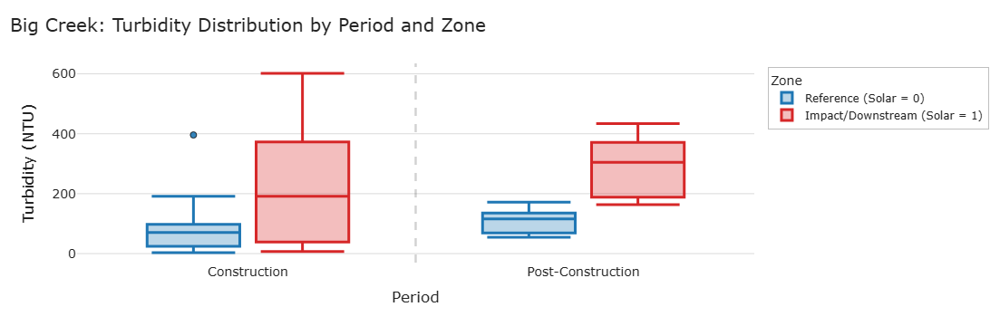

Saved: mart/plot_outputs\brushy_turbidity_box_period_solar.html
Saved: mart/plot_outputs\brushy_turbidity_box_period_solar_600dpi.png


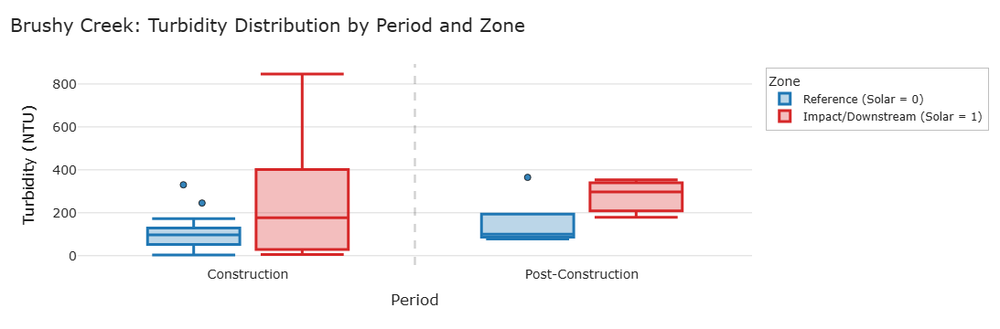

Saved: mart/plot_outputs\hogpen_turbidity_box_period_solar.html
Saved: mart/plot_outputs\hogpen_turbidity_box_period_solar_600dpi.png


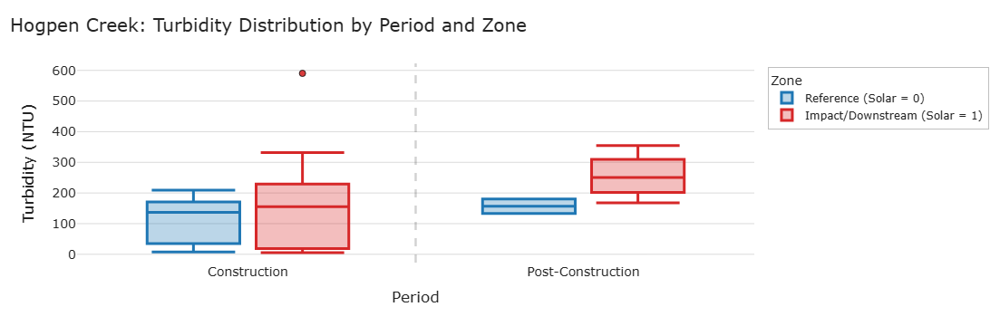

In [87]:
import os
import numpy as np
import pandas as pd
import plotly.express as px

# ============================================================
# ASSUMES THESE DATAFRAMES ALREADY EXIST IN MEMORY:
#   big_filt
#   brushy_filt
#   hog_filt
# ============================================================

# ============================================================
# USER SETTINGS
# ============================================================
OUT_DIR = r"mart/plot_outputs"
DPI = 600

# Set this to the exact Mart construction end date you want to use
CONSTRUCTION_END = "2024-07-10"   # early July 2024; change if needed

FIG_WIDTH_IN = 5.2
FIG_HEIGHT_IN = 4.5

# Optional y-cap for readability. Set to None to disable.
Y_CAP_PERCENTILE = None   # e.g., 98 or 99

PERIOD_ORDER = ["Construction", "Post-Construction"]
SOLAR_ORDER = ["Reference (Solar = 0)", "Impact/Downstream (Solar = 1)"]

SOLAR_COLORS = {
    "Reference (Solar = 0)": "#1f77b4",          # blue
    "Impact/Downstream (Solar = 1)": "#d62728",  # red
}

# Optional date drops based on your earlier watershed scripts
WATERSHEDS = {
    "Big Creek": {
        "df": big_filt.copy(),
        "out_stub": "big",
        "dates_to_drop": ["2/15/2024", "1/28/2025"],
    },
    "Brushy Creek": {
        "df": brushy_filt.copy(),
        "out_stub": "brushy",
        "dates_to_drop": ["2/15/2024", "4/9/2024"],
    },
    "Hogpen Creek": {
        "df": hog_filt.copy(),
        "out_stub": "hogpen",
        "dates_to_drop": ["2/15/2024"],
    },
}

# ============================================================
# HELPERS
# ============================================================
def ensure_outdir(path):
    os.makedirs(path, exist_ok=True)

def export_high_dpi(fig, out_png, dpi=600, width_in=5.2, height_in=4.5):
    width_px = int(width_in * dpi)
    height_px = int(height_in * dpi)
    fig.write_image(out_png, width=width_px, height=height_px, scale=1)

def hex_to_rgba(hex_color: str, alpha: float = 0.28) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

def prep_mart_df(df, dates_to_drop=None):
    d = df.copy()

    # Parse columns
    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Turbidity"] = pd.to_numeric(d["Turbidity"], errors="coerce")
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Turbidity", "Solar"]).copy()

    # Optional date drops
    if dates_to_drop:
        drop_dates = pd.to_datetime(dates_to_drop, errors="coerce").normalize()
        d = d[~d["Date"].dt.normalize().isin(drop_dates)].copy()

    # Period classification
    end = pd.to_datetime(CONSTRUCTION_END)
    d["Period"] = np.where(d["Date"] <= end, "Construction", "Post-Construction")

    # Solar grouping labels
    d["SolarGroup"] = d["Solar"].map({
        0.0: "Reference (Solar = 0)",
        1.0: "Impact/Downstream (Solar = 1)"
    })

    d = d.dropna(subset=["SolarGroup"]).copy()

    return d

def style_boxplot(fig, y_cap=None, title_text="Turbidity Distribution by Period and Zone"):
    # Style traces
    for tr in fig.data:
        grp = getattr(tr, "legendgroup", None) or tr.name
        base = SOLAR_COLORS.get(grp, "#444444")

        tr.update(
            line=dict(width=3.0, color=base),
            fillcolor=hex_to_rgba(base, 0.30),
            whiskerwidth=0.9,
            boxmean=False,
            boxpoints="outliers",
            marker=dict(
                size=7,
                opacity=0.9,
                color=base,
                symbol="circle",
                outliercolor=base,
                line=dict(
                    width=0.9,
                    color="black",
                    outlierwidth=0.9,
                    outliercolor="black"
                ),
            ),
            jitter=0.35,
            pointpos=0,
        )

    fig.update_layout(
        template="simple_white",
        title=dict(
            text=title_text,
            x=0.01, xanchor="left",
            font=dict(size=20)
        ),
        font=dict(size=14),
        margin=dict(l=85, r=210, t=70, b=70),
        boxmode="group",
        boxgap=0.35,
        boxgroupgap=0.15,
        legend=dict(
            title="Zone",
            x=1.02, y=0.98,
            xanchor="left", yanchor="top",
            bgcolor="rgba(255,255,255,0.90)",
            bordercolor="rgba(0,0,0,0.25)",
            borderwidth=1,
            font=dict(size=12),
        ),
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

    fig.update_yaxes(
        title="Turbidity (NTU)",
        showgrid=True,
        gridcolor="rgba(0,0,0,0.15)",
        zeroline=False,
        showline=False,
        ticks="",
        range=[0, y_cap] if y_cap else None,
    )

    fig.update_xaxes(
        title="Period",
        showgrid=False,
        showline=False,
        ticks="",
        zeroline=False,
        showticklabels=True,
    )

    # Divider between construction and post-construction
    fig.add_vline(
        x=0.5, xref="paper",
        line_width=2.4,
        line_dash="dash",
        line_color="rgba(0,0,0,0.60)"
    )

    return fig

def make_mart_boxplot(df, watershed_name, out_stub, dates_to_drop=None):
    d = prep_mart_df(df, dates_to_drop=dates_to_drop)

    if d.empty:
        raise ValueError(f"No rows available for {watershed_name} after filtering.")

    y_cap = None
    if Y_CAP_PERCENTILE is not None and len(d):
        y_cap = float(np.nanpercentile(d["Turbidity"], Y_CAP_PERCENTILE))

    fig = px.box(
        d,
        x="Period",
        y="Turbidity",
        color="SolarGroup",
        category_orders={
            "Period": PERIOD_ORDER,
            "SolarGroup": SOLAR_ORDER
        },
        color_discrete_map=SOLAR_COLORS,
        points="suspectedoutliers",
    )

    fig = style_boxplot(
        fig,
        y_cap=y_cap,
        title_text=f"{watershed_name}: Turbidity Distribution by Period and Zone"
    )

    out_html = os.path.join(OUT_DIR, f"{out_stub}_turbidity_box_period_solar.html")
    out_png  = os.path.join(OUT_DIR, f"{out_stub}_turbidity_box_period_solar_600dpi.png")

    fig.write_html(out_html)
    export_high_dpi(fig, out_png, dpi=DPI, width_in=FIG_WIDTH_IN, height_in=FIG_HEIGHT_IN)

    print(f"Saved: {out_html}")
    print(f"Saved: {out_png}")

    return fig, d

# ============================================================
# RUN ALL THREE WATERSHEDS
# ============================================================
ensure_outdir(OUT_DIR)

results = {}

for watershed_name, cfg in WATERSHEDS.items():
    fig, df_used = make_mart_boxplot(
        df=cfg["df"],
        watershed_name=watershed_name,
        out_stub=cfg["out_stub"],
        dates_to_drop=cfg["dates_to_drop"],
    )
    results[watershed_name] = {
        "fig": fig,
        "df": df_used
    }
    fig.show()

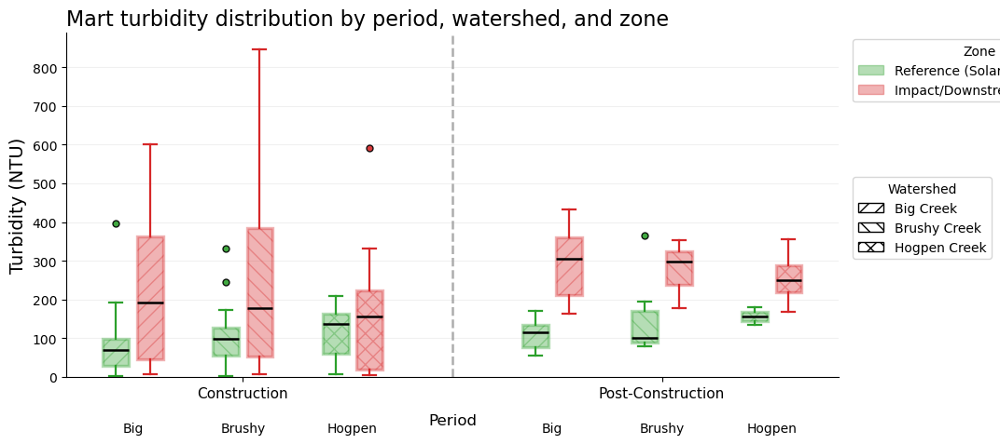

Saved: mart/plot_outputs\mart_all_watersheds_boxplot_singlepanel.png
Saved: mart/plot_outputs\mart_all_watersheds_boxplot_singlepanel.pdf


In [88]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# INPUT DATAFRAMES ALREADY IN MEMORY
#   big_filt
#   brushy_filt
#   hog_filt
# ============================================================

# ============================================================
# USER SETTINGS
# ============================================================
CONSTRUCTION_END = "2024-07-10"   # change if you want a different early-July cutoff
OUT_DIR = r"mart/plot_outputs"
OUT_PNG = os.path.join(OUT_DIR, "mart_all_watersheds_boxplot_singlepanel.png")
OUT_PDF = os.path.join(OUT_DIR, "mart_all_watersheds_boxplot_singlepanel.pdf")
DPI = 700

# optional date drops based on your earlier scripts
BIG_DROP_DATES = ["2024-02-15", "2025-01-28"]
BRUSHY_DROP_DATES = ["2024-02-15", "2024-04-09"]
HOG_DROP_DATES = ["2024-02-15"]

# ============================================================
# STYLES
# ============================================================
ZONE_COLORS = {
    "Reference": "#2ca02c",           # green
    "Impact/Downstream": "#d62728"    # red
}

WATERSHED_HATCH = {
    "Big Creek": "//",
    "Brushy Creek": "\\\\",
    "Hogpen Creek": "xx"
}

PERIOD_ORDER = ["Construction", "Post-Construction"]
WATERSHED_ORDER = ["Big Creek", "Brushy Creek", "Hogpen Creek"]
ZONE_ORDER = ["Reference", "Impact/Downstream"]

# ============================================================
# HELPERS
# ============================================================
def prep_df(df, watershed_name, drop_dates=None):
    d = df.copy()
    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Turbidity"] = pd.to_numeric(d["Turbidity"], errors="coerce")
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Turbidity", "Solar"]).copy()
    d = d[d["Solar"].isin([0, 1])].copy()

    if drop_dates:
        drop_dates = pd.to_datetime(drop_dates, errors="coerce").normalize()
        d = d[~d["Date"].dt.normalize().isin(drop_dates)].copy()

    d["Watershed"] = watershed_name
    return d


def zone_label_from_solar(val):
    return "Reference" if int(val) == 0 else "Impact/Downstream"


# ============================================================
# PREPARE DATA
# ============================================================
big_df = prep_df(big_filt, "Big Creek", BIG_DROP_DATES)
brushy_df = prep_df(brushy_filt, "Brushy Creek", BRUSHY_DROP_DATES)
hog_df = prep_df(hog_filt, "Hogpen Creek", HOG_DROP_DATES)

df = pd.concat([big_df, brushy_df, hog_df], ignore_index=True)

construction_end = pd.to_datetime(CONSTRUCTION_END)
df["Period"] = np.where(df["Date"] <= construction_end, "Construction", "Post-Construction")
df["Zone"] = df["Solar"].apply(zone_label_from_solar)

# ============================================================
# BUILD DATA FOR SINGLE-PANEL GROUPED BOXPLOT
# ============================================================
# Layout:
# Construction:
#   Big Ref, Big Impact, Brushy Ref, Brushy Impact, Hog Ref, Hog Impact
# Post-Construction:
#   Big Ref, Big Impact, Brushy Ref, Brushy Impact, Hog Ref, Hog Impact

box_data = []
positions = []
styles = []
period_positions = {p: [] for p in PERIOD_ORDER}
watershed_centers = []

# spacing controls
period_start = {
    "Construction": 1.0,
    "Post-Construction": 5.2
}
watershed_gap = 1.1
zone_gap = 0.34
box_width = 0.26

for period in PERIOD_ORDER:
    base = period_start[period]

    for w_idx, watershed in enumerate(WATERSHED_ORDER):
        w_positions = []

        for z_idx, zone in enumerate(ZONE_ORDER):
            pos = base + w_idx * watershed_gap + z_idx * zone_gap

            vals = df.loc[
                (df["Period"] == period) &
                (df["Watershed"] == watershed) &
                (df["Zone"] == zone),
                "Turbidity"
            ].dropna().values

            if len(vals) > 0:
                box_data.append(vals)
                positions.append(pos)
                styles.append((watershed, zone))
                period_positions[period].append(pos)
                w_positions.append(pos)

        if len(w_positions) > 0:
            watershed_centers.append((period, watershed, np.mean(w_positions)))

period_centers = {
    p: np.mean(period_positions[p]) for p in PERIOD_ORDER if len(period_positions[p]) > 0
}

divider_x = (max(period_positions["Construction"]) + min(period_positions["Post-Construction"])) / 2

# ============================================================
# PLOT
# ============================================================
os.makedirs(OUT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5.6))

bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=box_width,
    patch_artist=True,
    whis=1.5,
    showfliers=True,
    medianprops=dict(color="black", linewidth=1.8),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, markeredgecolor='black', alpha=0.85)
)

# style each box
for i, (box, (watershed, zone)) in enumerate(zip(bp["boxes"], styles)):
    color = ZONE_COLORS[zone]
    hatch = WATERSHED_HATCH[watershed]

    box.set(
        facecolor=color,
        edgecolor=color,
        alpha=0.35,
        linewidth=2.4,
        hatch=hatch
    )

    # whiskers and caps for each box
    bp["whiskers"][2*i].set(color=color, linewidth=1.6)
    bp["whiskers"][2*i + 1].set(color=color, linewidth=1.6)
    bp["caps"][2*i].set(color=color, linewidth=1.6)
    bp["caps"][2*i + 1].set(color=color, linewidth=1.6)

    # fliers
    if i < len(bp["fliers"]):
        bp["fliers"][i].set(
            markerfacecolor=color,
            markeredgecolor="black",
            alpha=0.9,
            markersize=5
        )

# divider between periods
ax.axvline(divider_x, color="0.6", linestyle="--", linewidth=1.8, alpha=0.8)

# x-axis: only show period labels
ax.set_xticks([period_centers[p] for p in PERIOD_ORDER])
ax.set_xticklabels(PERIOD_ORDER, fontsize=11)

# watershed labels below each pair
for period, watershed, center in watershed_centers:
    short_name = watershed.replace(" Creek", "")
    ax.text(
        center,
        -0.13,
        short_name,
        ha="center",
        va="top",
        fontsize=10,
        transform=ax.get_xaxis_transform()
    )

# styling
ax.set_title("Mart turbidity distribution by period, watershed, and zone", fontsize=16, loc="left")
ax.set_xlabel("Period", fontsize=12, labelpad=10)
ax.set_ylabel("Turbidity (NTU)", fontsize=14)
ax.grid(axis="y", linestyle="-", alpha=0.18)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)

# remove extra frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legends
zone_handles = [
    Patch(facecolor=ZONE_COLORS["Reference"], edgecolor=ZONE_COLORS["Reference"],
          alpha=0.35, label="Reference (Solar = 0)"),
    Patch(facecolor=ZONE_COLORS["Impact/Downstream"], edgecolor=ZONE_COLORS["Impact/Downstream"],
          alpha=0.35, label="Impact/Downstream (Solar = 1)")
]

watershed_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=WATERSHED_HATCH["Big Creek"], label="Big Creek"),
    Patch(facecolor="white", edgecolor="black", hatch=WATERSHED_HATCH["Brushy Creek"], label="Brushy Creek"),
    Patch(facecolor="white", edgecolor="black", hatch=WATERSHED_HATCH["Hogpen Creek"], label="Hogpen Creek")
]

leg1 = ax.legend(
    handles=zone_handles,
    title="Zone",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.00),
    frameon=True
)
leg2 = ax.legend(
    handles=watershed_handles,
    title="Watershed",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.60),
    frameon=True
)
ax.add_artist(leg1)

plt.subplots_adjust(left=0.09, right=0.78, bottom=0.22, top=0.88)

# save
fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print("Saved:", OUT_PNG)
print("Saved:", OUT_PDF)

Saved: mart/plot_outputs\mart_all_watersheds_boxplot_plotly.html
Saved: mart/plot_outputs\mart_all_watersheds_boxplot_plotly_600dpi.png


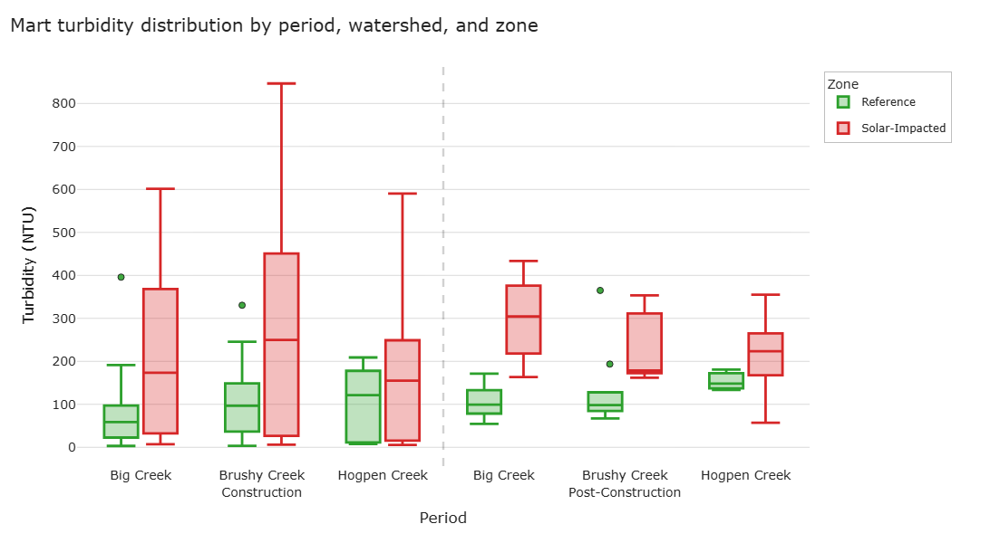

In [94]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ============================================================
# ASSUMES THESE DATAFRAMES ALREADY EXIST:
#   big_filt
#   brushy_filt
#   hog_filt
# ============================================================

# ============================================================
# USER SETTINGS
# ============================================================
CONSTRUCTION_END = "2024-05-01"   # adjust if needed
OUT_DIR = r"mart/plot_outputs"
OUT_HTML = os.path.join(OUT_DIR, "mart_all_watersheds_boxplot_plotly.html")
OUT_PNG  = os.path.join(OUT_DIR, "mart_all_watersheds_boxplot_plotly_600dpi.png")

DPI = 600
FIG_WIDTH_IN = 8.5
FIG_HEIGHT_IN = 7.2

Y_CAP_PERCENTILE = None   # e.g. 98 or 99, or keep None

# Optional date drops from your earlier scripts
# BIG_DROP_DATES = ["2024-02-15", "2025-01-28"]
# BRUSHY_DROP_DATES = ["2024-02-15", "2024-04-09"]
# HOG_DROP_DATES = ["2024-02-15"]

PERIOD_ORDER = ["Construction", "Post-Construction"]
WATERSHED_ORDER = ["Big Creek", "Brushy Creek", "Hogpen Creek"]
ZONE_ORDER = ["Reference", "Solar-Impacted"]

ZONE_COLORS = {
    "Reference": "#2ca02c",          # green
    "Solar-Impacted": "#d62728",  # red
}

# ============================================================
# HELPERS
# ============================================================
def ensure_outdir(path):
    os.makedirs(path, exist_ok=True)

def export_high_dpi(fig, out_png, dpi=600, width_in=8.5, height_in=5.2):
    width_px = int(width_in * dpi)
    height_px = int(height_in * dpi)
    fig.write_image(out_png, width=width_px, height=height_px, scale=1)

def hex_to_rgba(hex_color: str, alpha: float = 0.28) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

def prep_df(df, watershed_name, drop_dates=None):
    d = df.copy()

    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Turbidity"] = pd.to_numeric(d["Turbidity"], errors="coerce")
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Turbidity", "Solar"]).copy()
    d = d[d["Solar"].isin([0, 1])].copy()

    if drop_dates:
        drop_dates = pd.to_datetime(drop_dates, errors="coerce").normalize()
        d = d[~d["Date"].dt.normalize().isin(drop_dates)].copy()

    d["Watershed"] = watershed_name

    construction_end = pd.to_datetime(CONSTRUCTION_END)
    d["Period"] = np.where(d["Date"] <= construction_end, "Construction", "Post-Construction")

    d["Zone"] = d["Solar"].map({
        0.0: "Reference",
        1.0: "Solar-Impacted"
    })

    d = d.dropna(subset=["Zone"]).copy()

    d["Period"] = pd.Categorical(d["Period"], categories=PERIOD_ORDER, ordered=True)
    d["Watershed"] = pd.Categorical(d["Watershed"], categories=WATERSHED_ORDER, ordered=True)
    d["Zone"] = pd.Categorical(d["Zone"], categories=ZONE_ORDER, ordered=True)

    d = d.sort_values(["Period", "Watershed", "Zone", "Date"])
    return d

# ============================================================
# PREPARE DATA
# ============================================================
big_df = prep_df(big_filt, "Big Creek", BIG_DROP_DATES)
brushy_df = prep_df(brushy_filt, "Brushy Creek", BRUSHY_DROP_DATES)
hog_df = prep_df(hog_filt, "Hogpen Creek", HOG_DROP_DATES)

df = pd.concat([big_df, brushy_df, hog_df], ignore_index=True)

if df.empty:
    raise ValueError("No data available after filtering.")

# Optional y-cap
y_cap = None
if Y_CAP_PERCENTILE is not None and len(df):
    y_cap = float(np.nanpercentile(df["Turbidity"], Y_CAP_PERCENTILE))

# ============================================================
# BUILD SINGLE PLOTLY FIGURE
# ============================================================
fig = go.Figure()

for zone in ZONE_ORDER:
    sub = df[df["Zone"] == zone].copy()
    color = ZONE_COLORS[zone]

    fig.add_trace(
        go.Box(
            x=[sub["Period"].astype(str).tolist(), sub["Watershed"].astype(str).tolist()],
            y=sub["Turbidity"],
            name=zone,
            legendgroup=zone,
            offsetgroup=zone,
            boxpoints="outliers",   # use "suspectedoutliers" if you prefer
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.85,
            line=dict(color=color, width=2.8),
            fillcolor=hex_to_rgba(color, 0.30),
            marker=dict(
                color=color,
                size=7,
                opacity=0.9,
                outliercolor=color,
                line=dict(
                    color="black",
                    width=0.9,
                    outliercolor="black",
                    outlierwidth=0.9
                )
            ),
            hovertemplate=(
                "Period: %{x[0]}<br>"
                "Watershed: %{x[1]}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        )
    )

# ============================================================
# LAYOUT
# ============================================================
fig.update_layout(
    template="simple_white",
    title=dict(
        text="Mart turbidity distribution by period, watershed, and zone",
        x=0.01,
        xanchor="left",
        font=dict(size=20)
    ),
    font=dict(size=14),
    height=600,   #added to increase height
    boxmode="group",
    boxgap=0.35,
    boxgroupgap=0.14,
    margin=dict(l=85, r=210, t=70, b=85),
    legend=dict(
        title="Zone",
        x=1.02,
        y=0.98,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.90)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        font=dict(size=12),
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.update_yaxes(
    title="Turbidity (NTU)",
    showgrid=True,
    gridcolor="rgba(0,0,0,0.15)",
    zeroline=False,
    showline=False,
    ticks="",
    #range=[0, y_cap] if y_cap else None,
)

fig.update_xaxes(
    title="Period",
    showgrid=False,
    showline=False,
    ticks="",
    type="multicategory",
    showdividers=False
)

fig.add_vline(
    x=0.5,
    xref="paper",
    line_width=2.4,
    line_dash="dash",
    line_color="rgba(0,0,0,0.60)"
)

# ============================================================
# SAVE + SHOW
# ============================================================
ensure_outdir(OUT_DIR)

fig.write_html(OUT_HTML)

# Requires kaleido:
# pip install -U kaleido
export_high_dpi(fig, OUT_PNG, dpi=DPI, width_in=FIG_WIDTH_IN, height_in=FIG_HEIGHT_IN)

print("Saved:", OUT_HTML)
print("Saved:", OUT_PNG)

fig.show()

Saved: combined/plot_outputs\markom_mart_2row_subplot_STOTEN.html
Saved: combined/plot_outputs\markom_mart_2row_subplot_STOTEN_600dpi.png
Saved: combined/plot_outputs\markom_mart_2row_subplot_STOTEN.pdf


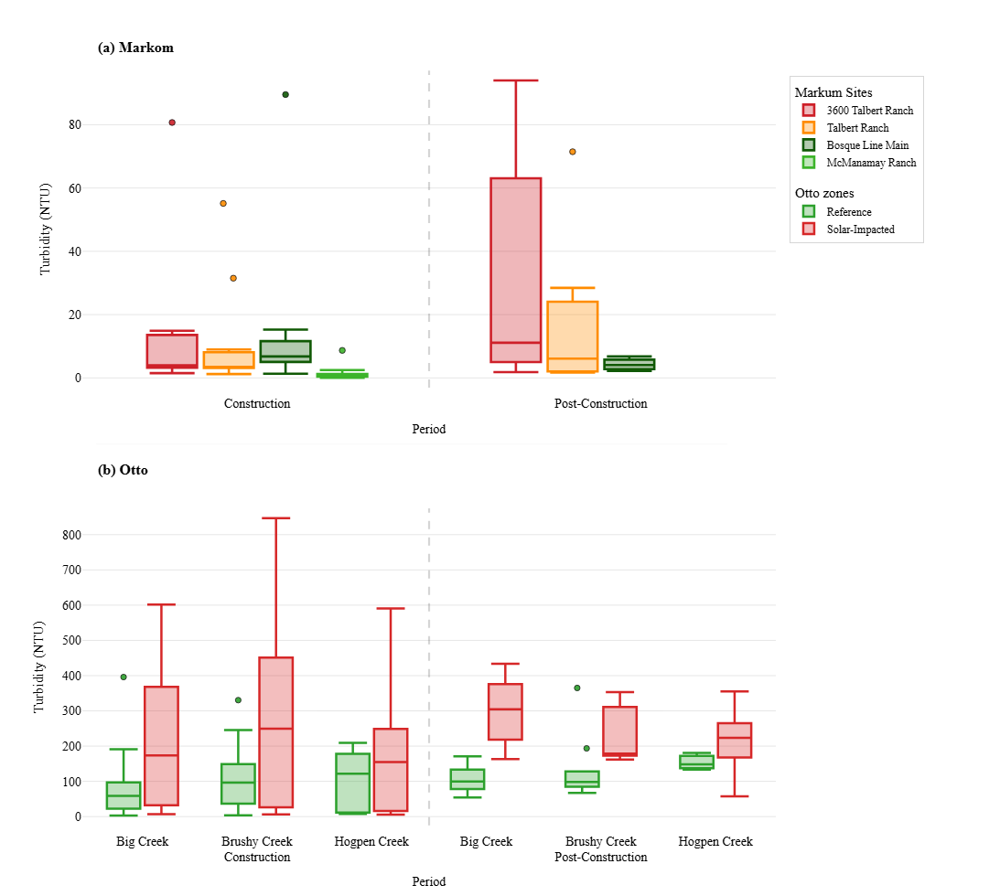

In [97]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# ASSUMES THESE EXIST:
#   big_filt
#   brushy_filt
#   hog_filt
#
# And this CSV exists:
#   markom/markom_clened_ntu.csv
# ============================================================

# ============================================================
# USER SETTINGS
# ============================================================
MARKOM_CSV = r"markom/markom_clened_ntu.csv"

OUT_DIR  = r"combined/plot_outputs"
OUT_HTML = os.path.join(OUT_DIR, "markom_mart_2row_subplot_STOTEN.html")
OUT_PNG  = os.path.join(OUT_DIR, "markom_mart_2row_subplot_STOTEN_600dpi.png")
OUT_PDF  = os.path.join(OUT_DIR, "markom_mart_2row_subplot_STOTEN.pdf")

DPI = 600
FIG_WIDTH_IN  = 9.2
FIG_HEIGHT_IN = 10.0

# Construction windows
MARKOM_CONSTRUCTION_START = "2024-02-01"
MARKOM_CONSTRUCTION_END   = "2024-07-15"
MART_CONSTRUCTION_END     = "2024-05-01"

PERIOD_ORDER = ["Construction", "Post-Construction"]

# Optional overall title inside the figure
SHOW_SUPERTITLE = False
SUPERTITLE_TEXT = "Turbidity distributions during construction and post-construction periods"

# Markom settings
MARKOM_SITE_ORDER = [
    "3600 Talbert Ranch",
    "Talbert Ranch",
    "Bosque Line Main",
    "McManamay Ranch"
]
MARKOM_SITE_COLORS = {
    "3600 Talbert Ranch": "#ce2029",
    "Talbert Ranch":      "#ff8c00",
    "Bosque Line Main":   "#105905",
    "McManamay Ranch":    "#3cb42a",
}

# Mart settings
WATERSHED_ORDER = ["Big Creek", "Brushy Creek", "Hogpen Creek"]
ZONE_ORDER = ["Reference", "Solar-Impacted"]
ZONE_COLORS = {
    "Reference": "#2ca02c",
    "Solar-Impacted": "#d62728",
}

# Optional Mart date drops
BIG_DROP_DATES = []
BRUSHY_DROP_DATES = []
HOG_DROP_DATES = []

MARKOM_Y_CAP_PERCENTILE = None
MART_Y_CAP_PERCENTILE = None

# ============================================================
# HELPERS
# ============================================================
def ensure_outdir(path):
    os.makedirs(path, exist_ok=True)

def export_high_dpi(fig, out_png, dpi=600, width_in=9.2, height_in=10.0):
    width_px = int(width_in * dpi)
    height_px = int(height_in * dpi)
    fig.write_image(out_png, width=width_px, height=height_px, scale=1)

def hex_to_rgba(hex_color: str, alpha: float = 0.28) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

def add_domain_divider(fig, xaxis_name, yaxis_name):
    fig.add_shape(
        type="line",
        xref=f"{xaxis_name} domain",
        yref=f"{yaxis_name} domain",
        x0=0.5, x1=0.5,
        y0=0.02, y1=0.98,
        line=dict(
            width=2.2,
            dash="dash",
            color="rgba(0,0,0,0.55)"
        )
    )

def add_panel_label(fig, text, x, y):
    fig.add_annotation(
        x=x, y=y,
        xref="paper", yref="paper",
        text=text,
        showarrow=False,
        xanchor="left",
        yanchor="bottom",
        font=dict(
            family="Times New Roman, Times, serif",
            size=16,
            color="black"
        )
    )

# ============================================================
# PREP: MARKOM
# ============================================================
def prep_markom_df(csv_path):
    df = pd.read_csv(csv_path)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Site"] = df["Site"].astype(str).str.strip()
    df["Turbidity"] = pd.to_numeric(df["Turbidity"], errors="coerce")
    df = df.dropna(subset=["Date", "Site", "Turbidity"]).copy()

    start = pd.to_datetime(MARKOM_CONSTRUCTION_START)
    end   = pd.to_datetime(MARKOM_CONSTRUCTION_END)

    df["Period"] = np.where(
        (df["Date"] >= start) & (df["Date"] <= end),
        "Construction",
        "Post-Construction"
    )

    df["Period"] = pd.Categorical(df["Period"], categories=PERIOD_ORDER, ordered=True)
    df["Site"]   = pd.Categorical(df["Site"], categories=MARKOM_SITE_ORDER, ordered=True)

    df = df[df["Site"].isin(MARKOM_SITE_ORDER)].copy()
    df = df.sort_values(["Period", "Site", "Date"])
    return df

# ============================================================
# PREP: MART
# ============================================================
def prep_mart_df(df, watershed_name, drop_dates=None):
    d = df.copy()

    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Turbidity"] = pd.to_numeric(d["Turbidity"], errors="coerce")
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Turbidity", "Solar"]).copy()
    d = d[d["Solar"].isin([0, 1])].copy()

    if drop_dates:
        drop_dates = pd.to_datetime(drop_dates, errors="coerce").normalize()
        d = d[~d["Date"].dt.normalize().isin(drop_dates)].copy()

    d["Watershed"] = watershed_name

    construction_end = pd.to_datetime(MART_CONSTRUCTION_END)
    d["Period"] = np.where(d["Date"] <= construction_end, "Construction", "Post-Construction")
    d["Zone"] = d["Solar"].map({
        0.0: "Reference",
        1.0: "Solar-Impacted"
    })

    d = d.dropna(subset=["Zone"]).copy()

    d["Period"] = pd.Categorical(d["Period"], categories=PERIOD_ORDER, ordered=True)
    d["Watershed"] = pd.Categorical(d["Watershed"], categories=WATERSHED_ORDER, ordered=True)
    d["Zone"] = pd.Categorical(d["Zone"], categories=ZONE_ORDER, ordered=True)

    d = d.sort_values(["Period", "Watershed", "Zone", "Date"])
    return d

# ============================================================
# LOAD DATA
# ============================================================
markom_df = prep_markom_df(MARKOM_CSV)

big_df = prep_mart_df(big_filt, "Big Creek", BIG_DROP_DATES)
brushy_df = prep_mart_df(brushy_filt, "Brushy Creek", BRUSHY_DROP_DATES)
hog_df = prep_mart_df(hog_filt, "Hogpen Creek", HOG_DROP_DATES)

mart_df = pd.concat([big_df, brushy_df, hog_df], ignore_index=True)

if markom_df.empty:
    raise ValueError("Markom dataframe is empty after filtering.")
if mart_df.empty:
    raise ValueError("Mart dataframe is empty after filtering.")

markom_y_cap = None
if MARKOM_Y_CAP_PERCENTILE is not None and len(markom_df):
    markom_y_cap = float(np.nanpercentile(markom_df["Turbidity"], MARKOM_Y_CAP_PERCENTILE))

mart_y_cap = None
if MART_Y_CAP_PERCENTILE is not None and len(mart_df):
    mart_y_cap = float(np.nanpercentile(mart_df["Turbidity"], MART_Y_CAP_PERCENTILE))

# ============================================================
# BUILD SUBPLOTS
# ============================================================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=False,
    vertical_spacing=0.14
)

# ----------------------------
# ROW 1: MARKOM
# ----------------------------
for site in MARKOM_SITE_ORDER:
    sub = markom_df[markom_df["Site"] == site].copy()
    if sub.empty:
        continue

    color = MARKOM_SITE_COLORS[site]

    fig.add_trace(
        go.Box(
            x=sub["Period"].astype(str),
            y=sub["Turbidity"],
            name=site,
            legendgroup="markom_site",
            legendgrouptitle_text="Markum Sites" if site == MARKOM_SITE_ORDER[0] else None,
            offsetgroup=site,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.9,
            line=dict(width=2.6, color=color),
            fillcolor=hex_to_rgba(color, 0.32),
            marker=dict(
                size=6.5,
                opacity=0.9,
                color=color,
                symbol="circle",
                outliercolor=color,
                line=dict(
                    width=0.8,
                    color="black",
                    outlierwidth=0.8,
                    outliercolor="black"
                ),
            ),
            showlegend=True,
            hovertemplate=(
                "Panel: Markom<br>"
                "Site: " + site + "<br>"
                "Period: %{x}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=1, col=1
    )

# ----------------------------
# ROW 2: MART
# ----------------------------
for zone in ZONE_ORDER:
    sub = mart_df[mart_df["Zone"] == zone].copy()
    if sub.empty:
        continue

    color = ZONE_COLORS[zone]

    fig.add_trace(
        go.Box(
            x=[sub["Period"].astype(str).tolist(),
               sub["Watershed"].astype(str).tolist()],
            y=sub["Turbidity"],
            name=zone,
            legendgroup="mart_zone",
            legendgrouptitle_text="Otto zones" if zone == ZONE_ORDER[0] else None,
            offsetgroup=zone,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.85,
            line=dict(color=color, width=2.5),
            fillcolor=hex_to_rgba(color, 0.30),
            marker=dict(
                color=color,
                size=6.2,
                opacity=0.9,
                outliercolor=color,
                line=dict(
                    color="black",
                    width=0.8,
                    outliercolor="black",
                    outlierwidth=0.8
                )
            ),
            showlegend=True,
            hovertemplate=(
                "Panel: Mart<br>"
                "Period: %{x[0]}<br>"
                "Watershed: %{x[1]}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=2, col=1
    )

# ============================================================
# LAYOUT
# ============================================================
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Times New Roman, Times, serif",
        size=14,
        color="black"
    ),
    height=980,
    boxmode="group",
    boxgap=0.34,
    boxgroupgap=0.12,
    margin=dict(l=90, r=245, t=70, b=70),
    legend=dict(
        x=1.02,
        y=0.985,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.92)",
        bordercolor="rgba(0,0,0,0.20)",
        borderwidth=0.8,
        font=dict(
            family="Times New Roman, Times, serif",
            size=12
        ),
        tracegroupgap=12
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

if SHOW_SUPERTITLE:
    fig.update_layout(
        title=dict(
            text=SUPERTITLE_TEXT,
            x=0.5,
            xanchor="center",
            font=dict(
                family="Times New Roman, Times, serif",
                size=18
            )
        )
    )

# Row 1 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, markom_y_cap] if markom_y_cap else None,
    row=1, col=1
)
fig.update_xaxes(
    title_text="Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    row=1, col=1
)

# Row 2 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, mart_y_cap] if mart_y_cap else None,
    row=2, col=1
)
fig.update_xaxes(
    title_text="Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    type="multicategory",
    showdividers=False,
    row=2, col=1
)

# Dashed divider in each row
add_domain_divider(fig, "x",  "y")
add_domain_divider(fig, "x2", "y2")

# Panel labels
add_panel_label(fig, "<b>(a) Markom</b>", 0.02, 1.01)
add_panel_label(fig, "<b>(b) Otto</b>",   0.02, 0.46)

# Optional light separator line between rows
fig.add_shape(
    type="line",
    xref="paper", yref="paper",
    x0=0.02, x1=0.93,
    y0=0.505, y1=0.505,
    line=dict(color="rgba(0,0,0,0.10)", width=1)
)

# ============================================================
# SAVE + SHOW
# ============================================================
ensure_outdir(OUT_DIR)
fig.write_html(OUT_HTML)
export_high_dpi(fig, OUT_PNG, dpi=DPI, width_in=FIG_WIDTH_IN, height_in=FIG_HEIGHT_IN)
fig.write_image(OUT_PDF)

print("Saved:", OUT_HTML)
print("Saved:", OUT_PNG)
print("Saved:", OUT_PDF)

fig.show()

In [ ]:
### Combined with Robinson

Saved: combined/plot_outputs\markom_mart_robinson_3row_subplot_STOTEN.html
Saved: combined/plot_outputs\markom_mart_robinson_3row_subplot_STOTEN_600dpi.png
Saved: combined/plot_outputs\markom_mart_robinson_3row_subplot_STOTEN.pdf


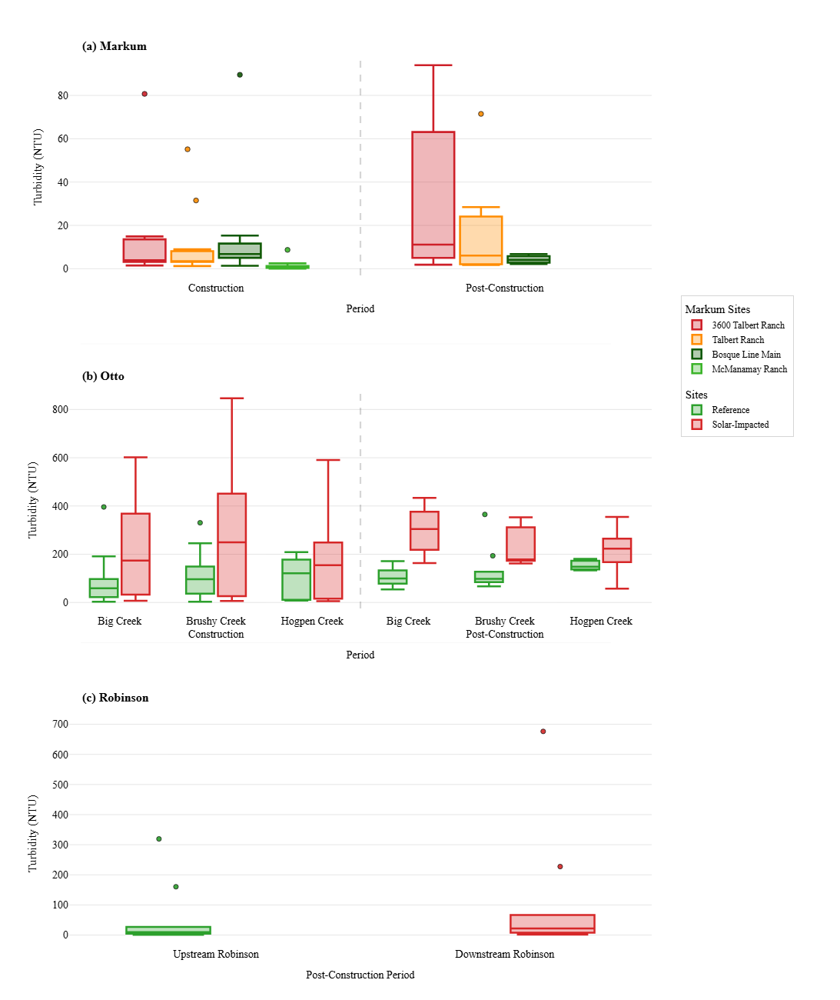

In [112]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# ASSUMES THESE EXIST:
#   big_filt
#   brushy_filt
#   hog_filt
#
# And these CSVs exist:
#   markom/markom_clened_ntu.csv
#   rob/rob.csv
# ============================================================

# ============================================================
# USER SETTINGS
# ============================================================
MARKOM_CSV   = r"markom/markom_clened_ntu.csv"
ROBINSON_CSV = r"rob/rob.csv"

OUT_DIR  = r"combined/plot_outputs"
OUT_HTML = os.path.join(OUT_DIR, "markom_mart_robinson_3row_subplot_STOTEN.html")
OUT_PNG  = os.path.join(OUT_DIR, "markom_mart_robinson_3row_subplot_STOTEN_600dpi.png")
OUT_PDF  = os.path.join(OUT_DIR, "markom_mart_robinson_3row_subplot_STOTEN.pdf")

DPI = 600
FIG_WIDTH_IN  = 9.2
FIG_HEIGHT_IN = 13.2

# Construction windows
MARKOM_CONSTRUCTION_START = "2024-02-01"
MARKOM_CONSTRUCTION_END   = "2024-07-15"
MART_CONSTRUCTION_END     = "2024-05-01"

PERIOD_ORDER = ["Construction", "Post-Construction"]

# Optional overall title inside the figure
SHOW_SUPERTITLE = False
SUPERTITLE_TEXT = "Turbidity distributions during construction and post-construction periods"

# Markom settings
MARKOM_SITE_ORDER = [
    "3600 Talbert Ranch",
    "Talbert Ranch",
    "Bosque Line Main",
    "McManamay Ranch"
]
MARKOM_SITE_COLORS = {
    "3600 Talbert Ranch": "#ce2029",
    "Talbert Ranch":      "#ff8c00",
    "Bosque Line Main":   "#105905",
    "McManamay Ranch":    "#3cb42a",
}

# Mart settings
WATERSHED_ORDER = ["Big Creek", "Brushy Creek", "Hogpen Creek"]
ZONE_ORDER = ["Reference", "Solar-Impacted"]
ZONE_COLORS = {
    "Reference": "#2ca02c",
    "Solar-Impacted": "#d62728",
}

# Robinson settings
ROBINSON_SITE_ORDER = ["Upstream Robinson", "Downstream Robinson"]

# Optional Mart date drops
BIG_DROP_DATES = []
BRUSHY_DROP_DATES = []
HOG_DROP_DATES = []

MARKOM_Y_CAP_PERCENTILE = None
MART_Y_CAP_PERCENTILE = None
ROBINSON_Y_CAP_PERCENTILE = None

# ============================================================
# HELPERS
# ============================================================
def ensure_outdir(path):
    os.makedirs(path, exist_ok=True)

def export_high_dpi(fig, out_png, dpi=600, width_in=9.2, height_in=10.0):
    width_px = int(width_in * dpi)
    height_px = int(height_in * dpi)
    fig.write_image(out_png, width=width_px, height=height_px, scale=1)

def hex_to_rgba(hex_color: str, alpha: float = 0.28) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

def add_domain_divider(fig, xaxis_name, yaxis_name):
    fig.add_shape(
        type="line",
        xref=f"{xaxis_name} domain",
        yref=f"{yaxis_name} domain",
        x0=0.5, x1=0.5,
        y0=0.02, y1=0.98,
        line=dict(
            width=2.2,
            dash="dash",
            color="rgba(0,0,0,0.55)"
        )
    )

def add_panel_label(fig, text, x, y):
    fig.add_annotation(
        x=x, y=y,
        xref="paper", yref="paper",
        text=text,
        showarrow=False,
        xanchor="left",
        yanchor="bottom",
        font=dict(
            family="Times New Roman, Times, serif",
            size=16,
            color="black"
        )
    )

# ============================================================
# PREP: MARKOM
# ============================================================
def prep_markom_df(csv_path):
    df = pd.read_csv(csv_path)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Site"] = df["Site"].astype(str).str.strip()
    df["Turbidity"] = pd.to_numeric(df["Turbidity"], errors="coerce")
    df = df.dropna(subset=["Date", "Site", "Turbidity"]).copy()

    start = pd.to_datetime(MARKOM_CONSTRUCTION_START)
    end   = pd.to_datetime(MARKOM_CONSTRUCTION_END)

    df["Period"] = np.where(
        (df["Date"] >= start) & (df["Date"] <= end),
        "Construction",
        "Post-Construction"
    )

    df["Period"] = pd.Categorical(df["Period"], categories=PERIOD_ORDER, ordered=True)
    df["Site"]   = pd.Categorical(df["Site"], categories=MARKOM_SITE_ORDER, ordered=True)

    df = df[df["Site"].isin(MARKOM_SITE_ORDER)].copy()
    df = df.sort_values(["Period", "Site", "Date"])
    return df

# ============================================================
# PREP: MART
# ============================================================
def prep_mart_df(df, watershed_name, drop_dates=None):
    d = df.copy()

    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Turbidity"] = pd.to_numeric(d["Turbidity"], errors="coerce")
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Turbidity", "Solar"]).copy()
    d = d[d["Solar"].isin([0, 1])].copy()

    if drop_dates:
        drop_dates = pd.to_datetime(drop_dates, errors="coerce").normalize()
        d = d[~d["Date"].dt.normalize().isin(drop_dates)].copy()

    d["Watershed"] = watershed_name

    construction_end = pd.to_datetime(MART_CONSTRUCTION_END)
    d["Period"] = np.where(d["Date"] <= construction_end, "Construction", "Post-Construction")
    d["Zone"] = d["Solar"].map({
        0.0: "Reference",
        1.0: "Solar-Impacted"
    })

    d = d.dropna(subset=["Zone"]).copy()

    d["Period"] = pd.Categorical(d["Period"], categories=PERIOD_ORDER, ordered=True)
    d["Watershed"] = pd.Categorical(d["Watershed"], categories=WATERSHED_ORDER, ordered=True)
    d["Zone"] = pd.Categorical(d["Zone"], categories=ZONE_ORDER, ordered=True)

    d = d.sort_values(["Period", "Watershed", "Zone", "Date"])
    return d

# ============================================================
# PREP: ROBINSON
# ============================================================
def prep_robinson_df(csv_path):
    d = pd.read_csv(csv_path)

    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")
    d["Turbidity"] = pd.to_numeric(d["Avg Turbidity NTU"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Solar", "Turbidity"]).copy()
    d = d[d["Solar"].isin([0, 1])].copy()

    # All Robinson data are post-construction
    d["Period"] = "Post-Construction"

    d["Zone"] = d["Solar"].map({
        0.0: "Reference",
        1.0: "Solar-Impacted"
    })

    d["Period"] = pd.Categorical(d["Period"], categories=PERIOD_ORDER, ordered=True)
    d["Site"] = pd.Categorical(d["Site"], categories=ROBINSON_SITE_ORDER, ordered=True)
    d["Zone"] = pd.Categorical(d["Zone"], categories=ZONE_ORDER, ordered=True)

    d = d[d["Site"].isin(ROBINSON_SITE_ORDER)].copy()
    d = d.sort_values(["Period", "Site", "Date"])
    return d

# ============================================================
# LOAD DATA
# ============================================================
markom_df = prep_markom_df(MARKOM_CSV)

big_df = prep_mart_df(big_filt, "Big Creek", BIG_DROP_DATES)
brushy_df = prep_mart_df(brushy_filt, "Brushy Creek", BRUSHY_DROP_DATES)
hog_df = prep_mart_df(hog_filt, "Hogpen Creek", HOG_DROP_DATES)

mart_df = pd.concat([big_df, brushy_df, hog_df], ignore_index=True)
robinson_df = prep_robinson_df(ROBINSON_CSV)

if markom_df.empty:
    raise ValueError("Markom dataframe is empty after filtering.")
if mart_df.empty:
    raise ValueError("Mart dataframe is empty after filtering.")
if robinson_df.empty:
    raise ValueError("Robinson dataframe is empty after filtering.")

markom_y_cap = None
if MARKOM_Y_CAP_PERCENTILE is not None and len(markom_df):
    markom_y_cap = float(np.nanpercentile(markom_df["Turbidity"], MARKOM_Y_CAP_PERCENTILE))

mart_y_cap = None
if MART_Y_CAP_PERCENTILE is not None and len(mart_df):
    mart_y_cap = float(np.nanpercentile(mart_df["Turbidity"], MART_Y_CAP_PERCENTILE))

robinson_y_cap = None
if ROBINSON_Y_CAP_PERCENTILE is not None and len(robinson_df):
    robinson_y_cap = float(np.nanpercentile(robinson_df["Turbidity"], ROBINSON_Y_CAP_PERCENTILE))

# ============================================================
# BUILD SUBPLOTS
# ============================================================
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=False,
    vertical_spacing=0.12
)

# ----------------------------
# ROW 1: MARKOM
# ----------------------------
for site in MARKOM_SITE_ORDER:
    sub = markom_df[markom_df["Site"] == site].copy()
    if sub.empty:
        continue

    color = MARKOM_SITE_COLORS[site]

    fig.add_trace(
        go.Box(
            x=sub["Period"].astype(str),
            y=sub["Turbidity"],
            name=site,
            legendgroup="markom_site",
            legendgrouptitle_text="Markum Sites" if site == MARKOM_SITE_ORDER[0] else None,
            offsetgroup=site,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.9,
            line=dict(width=2.6, color=color),
            fillcolor=hex_to_rgba(color, 0.32),
            marker=dict(
                size=6.5,
                opacity=0.9,
                color=color,
                symbol="circle",
                outliercolor=color,
                line=dict(
                    width=0.8,
                    color="black",
                    outlierwidth=0.8,
                    outliercolor="black"
                ),
            ),
            showlegend=True,
            hovertemplate=(
                "Panel: Markom<br>"
                "Site: " + site + "<br>"
                "Period: %{x}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=1, col=1
    )

# ----------------------------
# ROW 2: MART
# ----------------------------
for zone in ZONE_ORDER:
    sub = mart_df[mart_df["Zone"] == zone].copy()
    if sub.empty:
        continue

    color = ZONE_COLORS[zone]

    fig.add_trace(
        go.Box(
            x=[sub["Period"].astype(str).tolist(),
               sub["Watershed"].astype(str).tolist()],
            y=sub["Turbidity"],
            name=zone,
            legendgroup="mart_zone",
            legendgrouptitle_text="Sites" if zone == ZONE_ORDER[0] else None,
            offsetgroup=zone,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.85,
            line=dict(color=color, width=2.5),
            fillcolor=hex_to_rgba(color, 0.30),
            marker=dict(
                color=color,
                size=6.2,
                opacity=0.9,
                outliercolor=color,
                line=dict(
                    color="black",
                    width=0.8,
                    outliercolor="black",
                    outlierwidth=0.8
                )
            ),
            showlegend=True,
            hovertemplate=(
                "Panel: Mart<br>"
                "Period: %{x[0]}<br>"
                "Watershed: %{x[1]}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=2, col=1
    )

# ----------------------------
# ROW 3: ROBINSON
# ----------------------------
# ----------------------------
# ROW 3: ROBINSON
# ----------------------------
for zone in ZONE_ORDER:
    sub = robinson_df[robinson_df["Zone"] == zone].copy()
    if sub.empty:
        continue

    color = ZONE_COLORS[zone]

    fig.add_trace(
        go.Box(
            x=sub["Site"].astype(str),   # site only for Robinson
            y=sub["Turbidity"],
            name=zone,
            legendgroup="mart_zone",
            offsetgroup=zone,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.85,
            line=dict(color=color, width=2.5),
            fillcolor=hex_to_rgba(color, 0.30),
            marker=dict(
                color=color,
                size=6.2,
                opacity=0.9,
                outliercolor=color,
                line=dict(
                    color="black",
                    width=0.8,
                    outliercolor="black",
                    outlierwidth=0.8
                )
            ),
            showlegend=False,
            hovertemplate=(
                "Panel: Robinson<br>"
                "Site: %{x}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=3, col=1
    )

# ============================================================
# LAYOUT
# ============================================================
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Times New Roman, Times, serif",
        size=14,
        color="black"
    ),
    height=1300, # 1280,
    boxmode="group",
    boxgap=0.34,
    boxgroupgap=0.12,
    margin=dict(l=90, r=245, t=70, b=70),
    legend=dict(
        x=1.05, ## changed from 1.02,
        y=0.65, ## changed from 0.985,
        xanchor="left",
        yanchor= "middle",  ## changed from "top",
        bgcolor="rgba(255,255,255,0.92)",
        bordercolor="rgba(0,0,0,0.20)",
        borderwidth=0.8,
        font=dict(
            family="Times New Roman, Times, serif",
            size=12
        ),
        tracegroupgap=12
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

if SHOW_SUPERTITLE:
    fig.update_layout(
        title=dict(
            text=SUPERTITLE_TEXT,
            x=0.5,
            xanchor="center",
            font=dict(
                family="Times New Roman, Times, serif",
                size=18
            )
        )
    )

# Row 1 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, markom_y_cap] if markom_y_cap else None,
    row=1, col=1
)
fig.update_xaxes(
    title_text="Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    row=1, col=1
)

# Row 2 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, mart_y_cap] if mart_y_cap else None,
    row=2, col=1
)
fig.update_xaxes(
    title_text="Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    type="multicategory",
    showdividers=False,
    row=2, col=1
)

# Row 3 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, robinson_y_cap] if robinson_y_cap else None,
    row=3, col=1
)
fig.update_xaxes(
    title_text="Post-Construction Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    row=3, col=1
)

# Dashed divider in each row
add_domain_divider(fig, "x",  "y")
add_domain_divider(fig, "x2", "y2")
#add_domain_divider(fig, "x3", "y3")

# Panel labels
add_panel_label(fig, "<b>(a) Markum</b>",   0.02, 1.00)
add_panel_label(fig, "<b>(b) Otto</b>",     0.02, 0.63)
add_panel_label(fig, "<b>(c) Robinson</b>", 0.02, 0.27)

# Optional light separator lines between rows
for y_sep in [0.675, 0.34]:
    fig.add_shape(
        type="line",
        xref="paper", yref="paper",
        x0=0.02, x1=0.93,
        y0=y_sep, y1=y_sep,
        line=dict(color="rgba(0,0,0,0.10)", width=1)
    )

# ============================================================
# SAVE + SHOW
# ============================================================
ensure_outdir(OUT_DIR)
fig.write_html(OUT_HTML)
export_high_dpi(fig, OUT_PNG, dpi=DPI, width_in=FIG_WIDTH_IN, height_in=FIG_HEIGHT_IN)
fig.write_image(OUT_PDF)

print("Saved:", OUT_HTML)
print("Saved:", OUT_PNG)
print("Saved:", OUT_PDF)

fig.show()

In [52]:
#### Improve combined plot for publication


Exporting compact combined boxplot figures...
Saved 600 dpi PNG: combined/new_plot_outputs\markum_otto_robinson_3row_boxplot_600dpi_compact.png
Pixel size: 5520 x 6649
Saved 1000 dpi PNG: combined/new_plot_outputs\markum_otto_robinson_3row_boxplot_1000dpi_compact.png
Pixel size: 9200 x 11081
Saved PDF: combined/new_plot_outputs\markum_otto_robinson_3row_boxplot_1000dpi_compact.pdf
Saved 1000 dpi TIFF: combined/new_plot_outputs\markum_otto_robinson_3row_boxplot_1000dpi_compact.tif


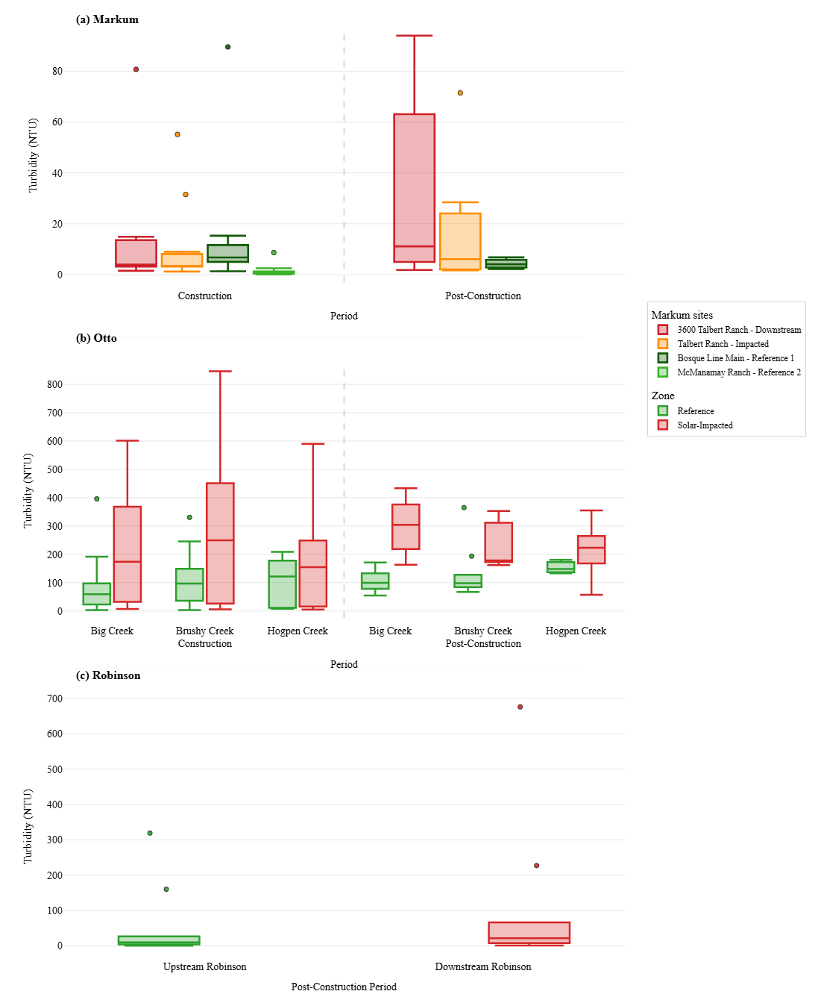

In [58]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image

# Optional: helps Kaleido locate Chrome
try:
    os.environ["BROWSER_PATH"] = str(pio.get_chrome())
except Exception:
    pass

# ============================================================
# ASSUMES THESE EXIST:
#   big_filt
#   brushy_filt
#   hog_filt
#
# And these CSVs exist:
#   markom/markom_clened_ntu.csv
#   rob/rob.csv
# ============================================================

# ============================================================
# USER SETTINGS
# ============================================================

MARKOM_CSV   = r"markom/markom_clened_ntu.csv"
ROBINSON_CSV = r"rob/rob.csv"

OUT_DIR = r"combined/new_plot_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG_600   = os.path.join(OUT_DIR, "markum_otto_robinson_3row_boxplot_600dpi_compact.png")
OUT_PNG_1000  = os.path.join(OUT_DIR, "markum_otto_robinson_3row_boxplot_1000dpi_compact.png")
OUT_TIFF_1000 = os.path.join(OUT_DIR, "markum_otto_robinson_3row_boxplot_1000dpi_compact.tif")
OUT_PDF_1000  = os.path.join(OUT_DIR, "markum_otto_robinson_3row_boxplot_1000dpi_compact.pdf")

# Normal display size that looks good in Jupyter/Plotly
# Reduced from 1575 to make the figure more compact.
DISPLAY_WIDTH_PX = 1100
DISPLAY_HEIGHT_PX = 1325

# Publication width
FIG_WIDTH_IN = 9.2

# Construction windows
MARKOM_CONSTRUCTION_START = "2024-02-01"
MARKOM_CONSTRUCTION_END   = "2024-07-15"
MART_CONSTRUCTION_END     = "2024-05-01"

PERIOD_ORDER = ["Construction", "Post-Construction"]

# No internal title because manuscript will use figure caption
SHOW_SUPERTITLE = False

# Markum settings
MARKOM_SITE_ORDER = [
    "3600 Talbert Ranch",
    "Talbert Ranch",
    "Bosque Line Main",
    "McManamay Ranch"
]

MARKOM_SITE_COLORS = {
    "3600 Talbert Ranch": "#ce2029",
    "Talbert Ranch":      "#ff8c00",
    "Bosque Line Main":   "#105905",
    "McManamay Ranch":    "#3cb42a",
}

MARKOM_SITE_LABELS = {
    "3600 Talbert Ranch": "3600 Talbert Ranch - Downstream",
    "Talbert Ranch": "Talbert Ranch - Impacted",
    "Bosque Line Main": "Bosque Line Main - Reference 1",
    "McManamay Ranch": "McManamay Ranch - Reference 2",
}

# Otto/Mart settings
WATERSHED_ORDER = ["Big Creek", "Brushy Creek", "Hogpen Creek"]

ZONE_ORDER = ["Reference", "Solar-Impacted"]

ZONE_COLORS = {
    "Reference": "#2ca02c",
    "Solar-Impacted": "#d62728",
}

# Robinson settings
ROBINSON_SITE_ORDER = ["Upstream Robinson", "Downstream Robinson"]

# Optional Otto/Mart date drops
BIG_DROP_DATES = []
BRUSHY_DROP_DATES = []
HOG_DROP_DATES = []

MARKOM_Y_CAP_PERCENTILE = None
MART_Y_CAP_PERCENTILE = None
ROBINSON_Y_CAP_PERCENTILE = None


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def ensure_outdir(path):
    os.makedirs(path, exist_ok=True)


def hex_to_rgba(hex_color: str, alpha: float = 0.28) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def add_domain_divider(fig, xaxis_name, yaxis_name):
    fig.add_shape(
        type="line",
        xref=f"{xaxis_name} domain",
        yref=f"{yaxis_name} domain",
        x0=0.5,
        x1=0.5,
        y0=0.02,
        y1=0.98,
        line=dict(
            width=2.0,
            dash="dash",
            color="rgba(0,0,0,0.50)"
        )
    )


def add_panel_label(fig, text, x, y):
    fig.add_annotation(
        x=x,
        y=y,
        xref="paper",
        yref="paper",
        text=text,
        showarrow=False,
        xanchor="left",
        yanchor="bottom",
        font=dict(
            family="Times New Roman, Times, serif",
            size=16,
            color="black"
        )
    )


def export_scaled_png(fig, out_path, dpi, display_width_px, display_height_px, fig_width_in):
    """
    Export Plotly figure so saved PNG keeps same visual proportions
    as the Jupyter display/download version.
    """
    target_width_px = int(fig_width_in * dpi)
    scale_factor = target_width_px / display_width_px

    fig.write_image(
        out_path,
        format="png",
        width=display_width_px,
        height=display_height_px,
        scale=scale_factor
    )

    with Image.open(out_path) as img:
        img.save(out_path, dpi=(dpi, dpi))

    print(f"Saved {dpi} dpi PNG: {out_path}")
    print(f"Pixel size: {int(display_width_px * scale_factor)} x {int(display_height_px * scale_factor)}")


# ============================================================
# PREP: MARKUM
# ============================================================

def prep_markom_df(csv_path):
    df = pd.read_csv(csv_path)

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Site"] = df["Site"].astype(str).str.strip()
    df["Turbidity"] = pd.to_numeric(df["Turbidity"], errors="coerce")

    df = df.dropna(subset=["Date", "Site", "Turbidity"]).copy()

    start = pd.to_datetime(MARKOM_CONSTRUCTION_START)
    end = pd.to_datetime(MARKOM_CONSTRUCTION_END)

    df["Period"] = np.where(
        (df["Date"] >= start) & (df["Date"] <= end),
        "Construction",
        "Post-Construction"
    )

    df["Period"] = pd.Categorical(df["Period"], categories=PERIOD_ORDER, ordered=True)
    df["Site"] = pd.Categorical(df["Site"], categories=MARKOM_SITE_ORDER, ordered=True)

    df = df[df["Site"].isin(MARKOM_SITE_ORDER)].copy()
    df = df.sort_values(["Period", "Site", "Date"])

    return df


# ============================================================
# PREP: OTTO/MART
# ============================================================

def prep_mart_df(df, watershed_name, drop_dates=None):
    d = df.copy()

    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Turbidity"] = pd.to_numeric(d["Turbidity"], errors="coerce")
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Turbidity", "Solar"]).copy()
    d = d[d["Solar"].isin([0, 1])].copy()

    if drop_dates:
        drop_dates = pd.to_datetime(drop_dates, errors="coerce").normalize()
        d = d[~d["Date"].dt.normalize().isin(drop_dates)].copy()

    d["Watershed"] = watershed_name

    construction_end = pd.to_datetime(MART_CONSTRUCTION_END)

    d["Period"] = np.where(
        d["Date"] <= construction_end,
        "Construction",
        "Post-Construction"
    )

    d["Zone"] = d["Solar"].map({
        0.0: "Reference",
        1.0: "Solar-Impacted"
    })

    d = d.dropna(subset=["Zone"]).copy()

    d["Period"] = pd.Categorical(d["Period"], categories=PERIOD_ORDER, ordered=True)
    d["Watershed"] = pd.Categorical(d["Watershed"], categories=WATERSHED_ORDER, ordered=True)
    d["Zone"] = pd.Categorical(d["Zone"], categories=ZONE_ORDER, ordered=True)

    d = d.sort_values(["Period", "Watershed", "Zone", "Date"])

    return d


# ============================================================
# PREP: ROBINSON
# ============================================================

def prep_robinson_df(csv_path):
    d = pd.read_csv(csv_path)

    d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
    d["Site"] = d["Site"].astype(str).str.strip()
    d["Solar"] = pd.to_numeric(d["Solar"], errors="coerce")
    d["Turbidity"] = pd.to_numeric(d["Avg Turbidity NTU"], errors="coerce")

    d = d.dropna(subset=["Date", "Site", "Solar", "Turbidity"]).copy()
    d = d[d["Solar"].isin([0, 1])].copy()

    # All Robinson data are post-construction
    d["Period"] = "Post-Construction"

    d["Zone"] = d["Solar"].map({
        0.0: "Reference",
        1.0: "Solar-Impacted"
    })

    d["Period"] = pd.Categorical(d["Period"], categories=PERIOD_ORDER, ordered=True)
    d["Site"] = pd.Categorical(d["Site"], categories=ROBINSON_SITE_ORDER, ordered=True)
    d["Zone"] = pd.Categorical(d["Zone"], categories=ZONE_ORDER, ordered=True)

    d = d[d["Site"].isin(ROBINSON_SITE_ORDER)].copy()
    d = d.sort_values(["Period", "Site", "Date"])

    return d


# ============================================================
# LOAD DATA
# ============================================================

markom_df = prep_markom_df(MARKOM_CSV)

big_df = prep_mart_df(big_filt, "Big Creek", BIG_DROP_DATES)
brushy_df = prep_mart_df(brushy_filt, "Brushy Creek", BRUSHY_DROP_DATES)
hog_df = prep_mart_df(hog_filt, "Hogpen Creek", HOG_DROP_DATES)

mart_df = pd.concat([big_df, brushy_df, hog_df], ignore_index=True)
robinson_df = prep_robinson_df(ROBINSON_CSV)

if markom_df.empty:
    raise ValueError("Markum dataframe is empty after filtering.")

if mart_df.empty:
    raise ValueError("Otto/Mart dataframe is empty after filtering.")

if robinson_df.empty:
    raise ValueError("Robinson dataframe is empty after filtering.")


# ============================================================
# OPTIONAL Y-AXIS CAPS
# ============================================================

markom_y_cap = None
if MARKOM_Y_CAP_PERCENTILE is not None and len(markom_df):
    markom_y_cap = float(np.nanpercentile(markom_df["Turbidity"], MARKOM_Y_CAP_PERCENTILE))

mart_y_cap = None
if MART_Y_CAP_PERCENTILE is not None and len(mart_df):
    mart_y_cap = float(np.nanpercentile(mart_df["Turbidity"], MART_Y_CAP_PERCENTILE))

robinson_y_cap = None
if ROBINSON_Y_CAP_PERCENTILE is not None and len(robinson_df):
    robinson_y_cap = float(np.nanpercentile(robinson_df["Turbidity"], ROBINSON_Y_CAP_PERCENTILE))


# ============================================================
# BUILD SUBPLOTS
# ============================================================

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=False,

    # Reduced from 0.12 to make the panels more compact
    vertical_spacing=0.075
)


# ============================================================
# ROW 1: MARKUM
# ============================================================

for site in MARKOM_SITE_ORDER:
    sub = markom_df[markom_df["Site"] == site].copy()

    if sub.empty:
        continue

    color = MARKOM_SITE_COLORS[site]
    site_label = MARKOM_SITE_LABELS.get(site, site)

    fig.add_trace(
        go.Box(
            x=sub["Period"].astype(str),
            y=sub["Turbidity"],
            name=site_label,
            legendgroup="markom_site",
            legendgrouptitle_text="Markum sites" if site == MARKOM_SITE_ORDER[0] else None,
            offsetgroup=site,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.9,
            line=dict(width=2.6, color=color),
            fillcolor=hex_to_rgba(color, 0.32),
            marker=dict(
                size=6.5,
                opacity=0.9,
                color=color,
                symbol="circle",
                outliercolor=color,
                line=dict(
                    width=0.8,
                    color="black",
                    outlierwidth=0.8,
                    outliercolor="black"
                ),
            ),
            showlegend=True,
            hovertemplate=(
                "Panel: Markum<br>"
                "Site: " + site_label + "<br>"
                "Period: %{x}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=1,
        col=1
    )


# ============================================================
# ROW 2: OTTO / MART
# ============================================================

for zone in ZONE_ORDER:
    sub = mart_df[mart_df["Zone"] == zone].copy()

    if sub.empty:
        continue

    color = ZONE_COLORS[zone]

    fig.add_trace(
        go.Box(
            x=[
                sub["Period"].astype(str).tolist(),
                sub["Watershed"].astype(str).tolist()
            ],
            y=sub["Turbidity"],
            name=zone,
            legendgroup="mart_zone",
            legendgrouptitle_text="Zone" if zone == ZONE_ORDER[0] else None,
            offsetgroup=zone,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.85,
            line=dict(color=color, width=2.5),
            fillcolor=hex_to_rgba(color, 0.30),
            marker=dict(
                color=color,
                size=6.2,
                opacity=0.9,
                outliercolor=color,
                line=dict(
                    color="black",
                    width=0.8,
                    outliercolor="black",
                    outlierwidth=0.8
                )
            ),
            showlegend=True,
            hovertemplate=(
                "Panel: Otto<br>"
                "Period: %{x[0]}<br>"
                "Watershed: %{x[1]}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=2,
        col=1
    )


# ============================================================
# ROW 3: ROBINSON
# ============================================================

for zone in ZONE_ORDER:
    sub = robinson_df[robinson_df["Zone"] == zone].copy()

    if sub.empty:
        continue

    color = ZONE_COLORS[zone]

    fig.add_trace(
        go.Box(
            x=sub["Site"].astype(str),
            y=sub["Turbidity"],
            name=zone,
            legendgroup="mart_zone",
            offsetgroup=zone,
            boxpoints="outliers",
            jitter=0.35,
            pointpos=0,
            whiskerwidth=0.85,
            line=dict(color=color, width=2.5),
            fillcolor=hex_to_rgba(color, 0.30),
            marker=dict(
                color=color,
                size=6.2,
                opacity=0.9,
                outliercolor=color,
                line=dict(
                    color="black",
                    width=0.8,
                    outliercolor="black",
                    outlierwidth=0.8
                )
            ),
            showlegend=False,
            hovertemplate=(
                "Panel: Robinson<br>"
                "Site: %{x}<br>"
                "Turbidity: %{y:.2f} NTU"
                "<extra></extra>"
            )
        ),
        row=3,
        col=1
    )


# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(
    template="simple_white",
    width=DISPLAY_WIDTH_PX,
    height=DISPLAY_HEIGHT_PX,
    font=dict(
        family="Times New Roman, Times, serif",
        size=14,
        color="black"
    ),
    boxmode="group",
    boxgap=0.34,
    boxgroupgap=0.12,

    # Reduced top and bottom margins
    margin=dict(l=85, r=235, t=30, b=55),

    # No internal title because manuscript caption will be used
    title=None,

    legend=dict(
        x=1.04,
        y=0.63,
        xanchor="left",
        yanchor="middle",
        bgcolor="rgba(255,255,255,0.92)",
        bordercolor="rgba(0,0,0,0.20)",
        borderwidth=0.8,
        font=dict(
            family="Times New Roman, Times, serif",
            size=12
        ),
        tracegroupgap=10
    ),

    plot_bgcolor="white",
    paper_bgcolor="white",
)


# ============================================================
# AXES
# ============================================================

# Row 1 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, markom_y_cap] if markom_y_cap else None,
    row=1,
    col=1
)

fig.update_xaxes(
    title_text="Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    row=1,
    col=1
)

# Row 2 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, mart_y_cap] if mart_y_cap else None,
    row=2,
    col=1
)

fig.update_xaxes(
    title_text="Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    type="multicategory",
    showdividers=False,
    row=2,
    col=1
)

# Row 3 axes
fig.update_yaxes(
    title_text="Turbidity (NTU)",
    title_font=dict(family="Times New Roman, Times, serif", size=15),
    showgrid=True,
    gridcolor="rgba(0,0,0,0.10)",
    zeroline=False,
    showline=False,
    ticks="",
    range=[0, robinson_y_cap] if robinson_y_cap else None,
    row=3,
    col=1
)

fig.update_xaxes(
    title_text="Post-Construction Period",
    title_font=dict(family="Times New Roman, Times, serif", size=14),
    showgrid=False,
    showline=False,
    ticks="",
    row=3,
    col=1
)


# ============================================================
# DIVIDERS AND PANEL LABELS
# ============================================================

# Dashed divider in Markum and Otto rows
add_domain_divider(fig, "x",  "y")
add_domain_divider(fig, "x2", "y2")
# No divider for Robinson row

# Panel labels adjusted for compact layout
add_panel_label(fig, "<b>(a) Markum</b>",   0.02, 0.995)
add_panel_label(fig, "<b>(b) Otto</b>",     0.02, 0.655)
add_panel_label(fig, "<b>(c) Robinson</b>", 0.02, 0.295)

# Light separator lines adjusted for compact layout
for y_sep in [0.665, 0.310]:
    fig.add_shape(
        type="line",
        xref="paper",
        yref="paper",
        x0=0.02,
        x1=0.93,
        y0=y_sep,
        y1=y_sep,
        line=dict(color="rgba(0,0,0,0.10)", width=1)
    )


# ============================================================
# EXPORT + SHOW
# ============================================================

print("\nExporting compact combined boxplot figures...")

# 600 dpi PNG
try:
    export_scaled_png(
        fig,
        OUT_PNG_600,
        dpi=600,
        display_width_px=DISPLAY_WIDTH_PX,
        display_height_px=DISPLAY_HEIGHT_PX,
        fig_width_in=FIG_WIDTH_IN
    )
except Exception as e:
    print(f"600 dpi PNG export failed: {e}")

# 1000 dpi PNG
try:
    export_scaled_png(
        fig,
        OUT_PNG_1000,
        dpi=1000,
        display_width_px=DISPLAY_WIDTH_PX,
        display_height_px=DISPLAY_HEIGHT_PX,
        fig_width_in=FIG_WIDTH_IN
    )
except Exception as e:
    print(f"1000 dpi PNG export failed: {e}")

# PDF export
# PDF is vector-based; dpi does not apply the same way as PNG/TIFF.
try:
    fig.write_image(
        OUT_PDF_1000,
        format="pdf",
        width=DISPLAY_WIDTH_PX,
        height=DISPLAY_HEIGHT_PX,
        scale=1
    )
    print(f"Saved PDF: {OUT_PDF_1000}")
except Exception as e:
    print(f"PDF export failed: {e}")

# 1000 dpi TIFF
try:
    if os.path.exists(OUT_PNG_1000):
        with Image.open(OUT_PNG_1000) as img:
            img.save(
                OUT_TIFF_1000,
                dpi=(1000, 1000),
                compression="tiff_lzw"
            )
        print(f"Saved 1000 dpi TIFF: {OUT_TIFF_1000}")
    else:
        print("1000 dpi TIFF skipped because 1000 dpi PNG was not created.")
except Exception as e:
    print(f"1000 dpi TIFF export failed: {e}")

fig.show()